In [1]:
# ── 0.1  Mount Google Drive and clone/pull the repository ─────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os, sys
os.chdir('/content')
!git clone https://github.com/VAL-Jerono/KHS_housing_dissertation.git 2>/dev/null || \
    (cd KHS_housing_dissertation && git pull)
os.chdir('KHS_housing_dissertation')
sys.path.insert(0, 'src')
print("✓ Drive mounted. Repository ready.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 15 (delta 8), reused 3 (delta 1), pack-reused 0 (from 0)
Unpacking objects: 100% (15/15), 2.34 MiB | 2.94 MiB/s, done.
From https://github.com/VAL-Jerono/KHS_housing_dissertation
   adb3de9..2a1a4dd  main       -> origin/main
Updating adb3de9..2a1a4dd
Fast-forward
 EDA_WithAnAngle.ipynb | 1509 ++++++++++
 exploration.ipynb     | 7730 ++++++++++++++++++++++++++++++++++++++++++++++---
 2 files changed, 8795 insertions(+), 444 deletions(-)
 create mode 100644 EDA_WithAnAngle.ipynb
✓ Drive mounted. Repository ready.


In [2]:
# ── 0.2  Install all required dependencies (first run only — ~90 seconds) ──────
!pip install -q polars pyarrow scikit-learn matplotlib seaborn pyreadstat scipy \
    xgboost lightgbm shap pytorch-tabnet geopandas statsmodels \
    mapclassify contextily imbalanced-learn joblib upsetplot
print("✓ All packages installed.")


✓ All packages installed.


In [3]:
# ── 0.3  Core imports ─────────────────────────────────────────────────────────
import json, warnings, pickle
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import seaborn as sns
from pathlib import Path
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ── Sklearn ────────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (StratifiedKFold, StratifiedGroupKFold,
                                      KFold, cross_val_predict,
                                      RandomizedSearchCV, train_test_split)
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                              classification_report, confusion_matrix,
                              mean_squared_error, r2_score, mean_absolute_error,
                              precision_recall_curve, roc_curve)
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import mutual_info_classif
from sklearn.calibration import calibration_curve
from sklearn.impute import SimpleImputer

# ── Boosting + Deep Learning ───────────────────────────────────────────────────
import xgboost as xgb
import lightgbm as lgb
import shap
import torch
import torch.nn as nn
from pytorch_tabnet.tab_model import TabNetRegressor, TabNetClassifier

import joblib
warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)
print(f"✓ All imports loaded.")
print(f"  XGBoost {xgb.__version__} | LightGBM {lgb.__version__} | SHAP {shap.__version__}")
print(f"  PyTorch {torch.__version__}")


✓ All imports loaded.
  XGBoost 3.2.0 | LightGBM 4.6.0 | SHAP 0.51.0
  PyTorch 2.11.0+cpu


In [4]:
# ── 0.4  Paths, constants, colour palette, plot style, county map ─────────────

DRIVE  = Path('/content/drive/MyDrive/KHS_Dissertation')
PQ     = DRIVE / 'data' / 'parquet'
RAW    = DRIVE / 'data' / 'raw'
OUT    = DRIVE / 'outputs'
FIGS   = OUT / 'figures'
TABS   = OUT / 'tables'
MODS   = OUT / 'models'
SHPS   = DRIVE / 'data' / 'shapefiles'
for p in [FIGS, TABS, MODS, SHPS]: p.mkdir(parents=True, exist_ok=True)

# ── Global constants ───────────────────────────────────────────────────────────
N_FOLDS        = 5       # Cross-validation folds
SEED           = 42      # Random seed — propagated everywhere
HFVS_THRESHOLD = 0.60    # Score above which a household is classified "high vulnerability"

# ── Colour palette (defined once, used in every chart) ─────────────────────────
TEAL   = '#00695C'
RED    = '#B71C1C'
AMBER  = '#E65100'
BLUE   = '#1565C0'
PURPLE = '#6A1B9A'
GRAY   = '#546E7A'
DARK   = '#2C2C2A'

# ── Publication plot style ─────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'        : 140,
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : '#F8F8F6',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : '600',
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
    'font.family'       : 'sans-serif',
    'legend.framealpha' : 0.9,
    'legend.fontsize'   : 9,
})

# ── All 47 Kenya counties (survey integer code → county name string) ─────────
COUNTY_MAP = {
     1:'Mombasa',        2:'Kwale',          3:'Kilifi',         4:'Tana River',
     5:'Lamu',           6:'Taita-Taveta',   7:'Garissa',        8:'Wajir',
     9:'Mandera',       10:'Marsabit',      11:'Isiolo',        12:'Meru',
    13:'Tharaka-Nithi', 14:'Embu',          15:'Kitui',         16:'Machakos',
    17:'Makueni',       18:'Nyandarua',     19:'Nyeri',         20:'Kirinyaga',
    21:"Murang'a",      22:'Kiambu',        23:'Turkana',       24:'West Pokot',
    25:'Samburu',       26:'Trans Nzoia',   27:'Uasin Gishu',   28:'Elgeyo-Marakwet',
    29:'Nandi',         30:'Baringo',       31:'Laikipia',      32:'Nakuru',
    33:'Narok',         34:'Kajiado',       35:'Kericho',       36:'Bomet',
    37:'Kakamega',      38:'Vihiga',        39:'Bungoma',       40:'Busia',
    41:'Siaya',         42:'Kisumu',        43:'Homa Bay',      44:'Migori',
    45:'Kisii',         46:'Nyamira',       47:'Nairobi',
}

print(f"✓ Environment configured.")
print(f"  FIGS: {FIGS}")
print(f"  TABS: {TABS}")
print(f"  Counties defined: {len(COUNTY_MAP)}")

✓ Environment configured.
  FIGS: /content/drive/MyDrive/KHS_Dissertation/outputs/figures
  TABS: /content/drive/MyDrive/KHS_Dissertation/outputs/tables
  Counties defined: 47


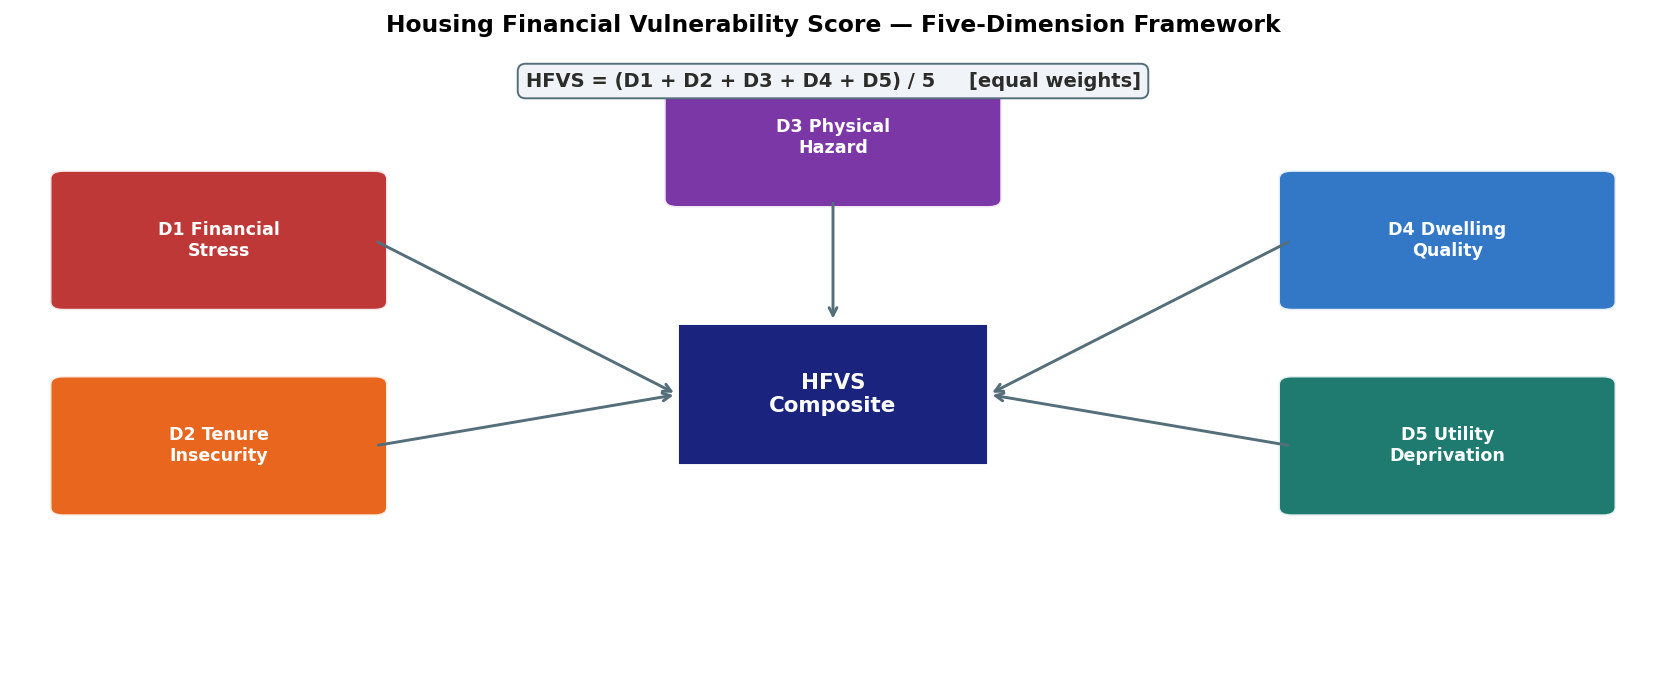

In [5]:
# ── 1.4  Visualise the HFVS Framework ─────────────────────────────────────────
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_xlim(0, 10); ax.set_ylim(0, 6); ax.axis('off')

BOX_W, BOX_H = 1.9, 1.2

# Central HFVS box
ax.add_patch(mpatches.Rectangle((4.05, 2.0), BOX_W, 1.4,
             fc='#1a237e', ec='white', lw=2, zorder=3))
ax.text(5.0, 2.7, 'HFVS\nComposite', ha='center', va='center',
        color='white', fontsize=11, fontweight='bold', zorder=4)

# Five dimension boxes
dims = [
    (0.3,  4.8, 'D1 Financial\nStress',    RED   ),   # top-left
    (0.3,  2.8, 'D2 Tenure\nInsecurity',   AMBER ),   # bottom-left
    (4.05, 5.8, 'D3 Physical\nHazard',     PURPLE),   # top-centre
    (7.8,  4.8, 'D4 Dwelling\nQuality',    BLUE  ),   # top-right
    (7.8,  2.8, 'D5 Utility\nDeprivation', TEAL  ),   # bottom-right
]

for bx, by, label, color in dims:
    ax.add_patch(mpatches.FancyBboxPatch((bx, by - BOX_H), BOX_W, BOX_H,
                 boxstyle='round,pad=0.08', fc=color, ec='white', lw=1.5, alpha=0.88))
    ax.text(bx + BOX_W/2, by - BOX_H/2, label,
            ha='center', va='center', color='white', fontsize=9, fontweight='bold')

    # Arrow routing —
    if bx < 4:        # left → right edge to left face of HFVS
        x_start, y_start = bx + BOX_W,   by - BOX_H/2
        x_end,   y_end   = 4.05,          2.7
    elif bx > 6:      # right → left edge to right face of HFVS
        x_start, y_start = bx,            by - BOX_H/2
        x_end,   y_end   = 4.05 + BOX_W,  2.7
    else:             # D3 top-centre → bottom edge down to top face of HFVS
        x_start, y_start = bx + BOX_W/2,  by - BOX_H
        x_end,   y_end   = 5.0,            2.0 + 1.4

    ax.annotate('', xy=(x_end, y_end), xytext=(x_start, y_start),
                arrowprops=dict(arrowstyle='->', color=GRAY, lw=1.5,
                                connectionstyle='arc3,rad=0.0'))

# Title & formula
ax.text(5.0, 5.75, 'HFVS = (D1 + D2 + D3 + D4 + D5) / 5     [equal weights]',
        ha='center', va='center', fontsize=10, fontweight='600', color=DARK,
        bbox=dict(boxstyle='round', fc='#F0F4F8', ec=GRAY, pad=0.4))
ax.set_title('Housing Financial Vulnerability Score — Five-Dimension Framework',
             fontsize=12, fontweight='700', pad=12)

plt.tight_layout()
plt.savefig(FIGS / 'phase1_hfvs_framework.png', dpi=150, bbox_inches='tight')
plt.show()


In [6]:
# ── 2.1  Load codebook labels ─────────────────────────────────────────────────
# The KHS uses Stata-style integer codes for categorical variables.
# The JSON label files map code → label string for audit and interpretation.

with open(PQ / 'household_variable_labels.json')  as f: HH_VAR  = json.load(f)
with open(PQ / 'household_value_labels.json')     as f: HH_VAL  = json.load(f)
with open(PQ / 'dwelling_variable_labels.json')   as f: DW_VAR  = json.load(f)
with open(PQ / 'dwelling_value_labels.json')      as f: DW_VAL  = json.load(f)
with open(PQ / 'individual_variable_labels.json') as f: IND_VAR = json.load(f)

def decode(col, series, val_dict=HH_VAL):
    mapping = val_dict.get(col.upper(), val_dict.get(col, {}))
    return series.map(lambda x: mapping.get(str(int(x)), str(x)) if pd.notna(x) else np.nan)

print("✓ Codebook labels loaded.")
print(f"  Household variable labels : {len(HH_VAR):,}")
print(f"  Household value labels    : {len(HH_VAL):,}")
print(f"  Dwelling variable labels  : {len(DW_VAR):,}")

✓ Codebook labels loaded.
  Household variable labels : 392
  Household value labels    : 121
  Dwelling variable labels  : 25


In [7]:
# ── 2.2  File inventory — establish the full data universe ────────────────────
FILES = {
    'household' : 'Household_Information_Data.parquet',
    'individual': 'Individual_Data.parquet',
    'dwelling'  : 'Dwelling_Units_Data.parquet',
    'county'    : 'County_Physical_Planning_Data.parquet',
    'mortgage'  : 'Housing_Mortgage_Data.parquet',
    'loan'      : 'Housing_Loans_Data.parquet',
}

DESCRIPTIONS = {
    'household' : 'SPINE — 392 cols: finances, tenure, utilities, infrastructure',
    'individual': 'One row per person — demographics, education, migration, employment',
    'dwelling'  : 'Physical structure details — materials, rooms, floor area',
    'county'    : '47 rows — county-level planning data, infrastructure indicators',
    'mortgage'  : 'Mortgage records for borrowing households',
    'loan'      : 'Housing loan records',
}

print(f"  {'File':<13} {'Rows':>8} {'Cols':>6}  Description")
print("  " + "─" * 72)
dfs = {}
for key, fname in FILES.items():
    path = PQ / fname
    if not path.exists():
        print(f"  {'⚠ '+key:<13} {'—':>8} {'—':>6}  Not found")
        continue
    df = pl.read_parquet(path).to_pandas()
    dfs[key] = df
    print(f"  {key:<13} {df.shape[0]:>8,} {df.shape[1]:>6}  {DESCRIPTIONS.get(key,'')}")

hh       = dfs.get('household')
ind      = dfs.get('individual')
dw       = dfs.get('dwelling')
cnt      = dfs.get('county')
mortgage = dfs.get('mortgage', pd.DataFrame())   # ← was missing
loan     = dfs.get('loan',     pd.DataFrame())   # ← was missing

print(f"\n✓ Survey universe: {hh.shape[0]:,} households across {hh['a01'].nunique()} counties.")
print(f"  Individual records: {ind.shape[0]:,} people ({ind.shape[0]/hh.shape[0]:.1f} per household avg)")
print(f"  Dwelling records  : {dw.shape[0]:,} dwelling units")
print(f"  Mortgage records  : {len(mortgage):,}")
print(f"  Loan records      : {len(loan):,}")

  File              Rows   Cols  Description
  ────────────────────────────────────────────────────────────────────────
  household       21,347    392  SPINE — 392 cols: finances, tenure, utilities, infrastructure
  individual      80,889     97  One row per person — demographics, education, migration, employment
  dwelling        25,116     25  Physical structure details — materials, rooms, floor area
  county              47    116  47 rows — county-level planning data, infrastructure indicators
  mortgage         1,644     13  Mortgage records for borrowing households
  loan               946     10  Housing loan records

✓ Survey universe: 21,347 households across 47 counties.
  Individual records: 80,889 people (3.8 per household avg)
  Dwelling records  : 25,116 dwelling units
  Mortgage records  : 1,644
  Loan records      : 946


# ***EXPLORATION***

In [8]:
# ── STEP 1: Full raw directory inventory ──────────────────────────────────────
# Before loading anything, we want to know EXACTLY what files exist,
# their sizes, and whether they have parquet equivalents already converted.

import os
from pathlib import Path

print("=" * 70)
print("RAW DATA DIRECTORY — FULL INVENTORY")
print("=" * 70)

raw_files = sorted(RAW.glob("*.dta"))
pq_files  = {p.stem: p for p in PQ.glob("*.parquet")}

print(f"\n{'File':<45} {'Size (MB)':>10}  {'Parquet?':>10}")
print("─" * 70)

for f in raw_files:
    size_mb  = f.stat().st_size / 1_048_576
    has_pq   = "✓ yes" if f.stem in pq_files else "✗ no"
    print(f"  {f.name:<43} {size_mb:>9.2f}  {has_pq:>10}")

print(f"\n  Total .dta files : {len(raw_files)}")
print(f"  Already as .pq   : {len(pq_files)}")
print(f"  Need conversion  : {len(raw_files) - len(pq_files)}")

RAW DATA DIRECTORY — FULL INVENTORY

File                                           Size (MB)    Parquet?
──────────────────────────────────────────────────────────────────────
  County_Physical_Planning_Data.dta                0.11       ✓ yes
  Dwelling_Units_Data.dta                          6.44       ✓ yes
  Household_Information_Data.dta                  70.98       ✓ yes
  Housing_Financiers_Data.dta                      0.29       ✓ yes
  Housing_Loans_Data.dta                           0.10       ✓ yes
  Housing_Mortgage_Data.dta                        0.17       ✓ yes
  Individual_Data.dta                             60.26       ✓ yes
  KHS_Institutional_Data.dta                       0.61       ✓ yes
  Land_Parcels_Data.dta                            0.82       ✓ yes
  NEMA_Data_Set.dta                                0.05       ✓ yes
  Project Information.dta                          0.18       ✓ yes
  Real_Estate_Dataset.dta                          7.18       ✓ yes
  Type 

In [9]:
# ── STEP 2: Convert all remaining .dta files → parquet ────────────────────────
# pyreadstat preserves Stata value labels; we save both the data and
# a labels JSON so every downstream cell can decode integer codes.

import pyreadstat
import json

print("Converting .dta files not yet in parquet...\n")

conversion_log = {}

for f in sorted(RAW.glob("*.dta")):
    stem   = f.stem
    pq_out = PQ / f"{stem}.parquet"
    lb_out = PQ / f"{stem}_value_labels.json"

    if pq_out.exists():
        print(f"  ✓ {stem:<45} (already converted)")
        continue

    try:
        df, meta = pyreadstat.read_dta(str(f))

        # Save data as parquet
        df.to_parquet(pq_out, index=False)

        # Save variable labels  (col_name → description string)
        var_labels = meta.column_labels
        var_label_dict = dict(zip(meta.column_names, meta.column_labels))

        # Save value labels  (col_name → {code: label})
        val_labels = {}
        for col, mapping in meta.variable_value_labels.items():
            val_labels[col] = {str(int(k)): v for k, v in mapping.items()}

        combined = {"variable_labels": var_label_dict, "value_labels": val_labels}
        with open(lb_out, 'w') as jf:
            json.dump(combined, jf, indent=2)

        conversion_log[stem] = {
            'rows': df.shape[0], 'cols': df.shape[1],
            'var_labels': len(var_label_dict),
            'val_label_cols': len(val_labels)
        }
        print(f"  → {stem:<45} {df.shape[0]:>7,} rows × {df.shape[1]:>4} cols")

    except Exception as e:
        print(f"  ✗ {stem:<45} ERROR: {e}")

print(f"\n✓ Conversion complete. {len(conversion_log)} new files written to {PQ}")

Converting .dta files not yet in parquet...

  ✓ County_Physical_Planning_Data                 (already converted)
  ✓ Dwelling_Units_Data                           (already converted)
  ✓ Household_Information_Data                    (already converted)
  ✓ Housing_Financiers_Data                       (already converted)
  ✓ Housing_Loans_Data                            (already converted)
  ✓ Housing_Mortgage_Data                         (already converted)
  ✓ Individual_Data                               (already converted)
  ✓ KHS_Institutional_Data                        (already converted)
  ✓ Land_Parcels_Data                             (already converted)
  ✓ NEMA_Data_Set                                 (already converted)
  ✓ Project Information                           (already converted)
  ✓ Real_Estate_Dataset                           (already converted)
  ✓ Type of Housing Units                         (already converted)
  ✓ Water_Services_Providers_Data            

In [10]:
# ── STEP 3: Load ALL files + their label metadata ─────────────────────────────
# For each file we load: the dataframe, its variable labels (col descriptions),
# and its value labels (integer code → string meaning).
# This gives us the full picture of what each file actually contains.

ALL_FILES = {
    # Already loaded
    'household'    : 'Household_Information_Data',
    'individual'   : 'Individual_Data',
    'dwelling'     : 'Dwelling_Units_Data',
    'county'       : 'County_Physical_Planning_Data',
    'mortgage'     : 'Housing_Mortgage_Data',
    'loan'         : 'Housing_Loans_Data',
    # New — previously unused
    'land_parcels' : 'Land_Parcels_Data',
    'nema'         : 'NEMA_Data_Set',
    'water_svc'    : 'Water_Services_Providers_Data',
    'real_estate'  : 'Real_Estate_Dataset',
    'financiers'   : 'Housing_Financiers_Data',
    'institutional': 'KHS_Institutional_Data',
    'project_info' : 'Project Information',
    'housing_types': 'Type of Housing Units',
}

all_dfs    = {}
all_labels = {}   # key → {'variable_labels': {}, 'value_labels': {}}

print(f"{'Key':<16} {'Rows':>8} {'Cols':>6}  {'VarLabels':>10}  {'ValLabelCols':>13}  Description")
print("─" * 90)

for key, stem in ALL_FILES.items():
    pq_path = PQ / f"{stem}.parquet"
    lb_path = PQ / f"{stem}_value_labels.json"

    if not pq_path.exists():
        # Try converting on the fly if .dta exists
        dta_path = RAW / f"{stem}.dta"
        if dta_path.exists():
            df, meta = pyreadstat.read_dta(str(dta_path))
            df.to_parquet(pq_path, index=False)
            var_lbl = dict(zip(meta.column_names, meta.column_labels))
            val_lbl = {col: {str(int(k)): v for k, v in mapping.items()}
                       for col, mapping in meta.variable_value_labels.items()}
            labels  = {"variable_labels": var_lbl, "value_labels": val_lbl}
            with open(lb_path, 'w') as jf:
                json.dump(labels, jf, indent=2)
        else:
            print(f"  ✗ {key:<16} — file not found in raw or parquet")
            continue
    else:
        df = pd.read_parquet(pq_path)
        labels = {}
        if lb_path.exists():
            with open(lb_path) as jf:
                labels = json.load(jf)

    all_dfs[key]    = df
    all_labels[key] = labels

    vl_count  = len(labels.get('variable_labels', {}))
    val_count = len(labels.get('value_labels',    {}))
    # First variable label as a short description of the file
    first_desc = list(labels.get('variable_labels', {}).values())[:1]
    first_desc = first_desc[0][:40] if first_desc else "—"

    print(f"  {key:<16} {df.shape[0]:>8,} {df.shape[1]:>6}  {vl_count:>10}  {val_count:>13}  ...")

print(f"\n✓ {len(all_dfs)} files loaded.")

Key                  Rows   Cols   VarLabels   ValLabelCols  Description
──────────────────────────────────────────────────────────────────────────────────────────
  household          21,347    392           0              0  ...
  individual         80,889     97           0              0  ...
  dwelling           25,116     25           0              0  ...
  county                 47    116           0              0  ...
  mortgage            1,644     13           0              0  ...
  loan                  946     10           0              0  ...
  land_parcels       11,136     34           0              0  ...
  nema                   48     45           0              0  ...
  water_svc             153     96           0              0  ...
  real_estate         7,236    300           0              0  ...
  financiers            351     63           0              0  ...
  institutional         348    194           0              0  ...
  project_info           71    2

In [11]:
# ── STEP 4: Deep profile — one block per file ─────────────────────────────────
# For every file we print:
#   • All column names alongside their Stata variable label
#   • dtype
#   • % missing
#   • Top 3 most-frequent values (decoded where value labels exist)
#   • Whether the column looks like a join key to the household spine

SPINE_KEY = 'interview__key'   # primary household identifier

def top_values(series, val_label_dict, n=3):
    """Return top-n value counts as decoded strings."""
    vc = series.value_counts(dropna=False).head(n)
    out = []
    for val, cnt in vc.items():
        pct   = cnt / len(series) * 100
        label = val_label_dict.get(str(int(val)), str(val)) if (
                    pd.notna(val) and str(val).replace('.','',1).lstrip('-').isdigit()
                ) else str(val)
        out.append(f"{label} ({pct:.0f}%)")
    return " | ".join(out)

for key, df in all_dfs.items():
    vlabels = all_labels[key].get('variable_labels', {})
    vvalues = all_labels[key].get('value_labels',    {})

    print("\n" + "═" * 90)
    print(f"  FILE: {key.upper()}   [{df.shape[0]:,} rows × {df.shape[1]} cols]")
    print("═" * 90)

    # Is the household spine key present?
    has_spine_key = SPINE_KEY in df.columns
    potential_keys = [c for c in df.columns if 'key' in c.lower() or
                      c in ('a01', 'county', 'hh_id', 'hhid', 'id')]
    print(f"  Spine key ({SPINE_KEY}) present: {'✓ YES' if has_spine_key else '✗ NO'}")
    if not has_spine_key and potential_keys:
        print(f"  Potential join keys found     : {potential_keys}")
    print()

    print(f"  {'Column':<28} {'Label':<38} {'Type':<10} {'Miss%':>6}  Top values")
    print("  " + "─" * 110)

    for col in df.columns:
        label   = vlabels.get(col, '')[:37]
        dtype   = str(df[col].dtype)[:9]
        miss_pct = df[col].isna().mean() * 100
        val_lbl  = vvalues.get(col, {})

        try:
            top = top_values(df[col], val_lbl, n=3)[:70]
        except Exception:
            top = "—"

        miss_flag = f"{miss_pct:5.1f}%" if miss_pct > 0 else "     —"
        print(f"  {col:<28} {label:<38} {dtype:<10} {miss_flag}  {top}")


══════════════════════════════════════════════════════════════════════════════════════════
  FILE: HOUSEHOLD   [21,347 rows × 392 cols]
══════════════════════════════════════════════════════════════════════════════════════════
  Spine key (interview__key) present: ✓ YES

  Column                       Label                                  Type        Miss%  Top values
  ──────────────────────────────────────────────────────────────────────────────────────────────────────────────
  interview__key                                                      object          —  99-99-55-22 (0%) | 00-00-55-14 (0%) | 00-01-22-52 (0%)
  interview__id                                                       object          —  10aaef5340474566a671d44dc2a1482e (0%) | 8a585d4dd71641b8a1348be6cc11e1
  a01                                                                 int8            —  47 (5%) | 32 (3%) | 8 (3%)
  countycode                                                          object          —  47 (5

In [12]:
# ── STEP 5: Join feasibility — what can link back to the household spine ───────
# For each non-household file, test every candidate join key:
#   • How many unique values in the file's key
#   • How many match to the household spine
#   • Match rate (%)
# This tells us definitively whether we can enrich at household or county level.

print("JOIN FEASIBILITY MATRIX")
print("=" * 70)
print("Testing which files can join to the 21,347 household spine rows.\n")

hh_df         = all_dfs['household']
hh_keys       = set(hh_df[SPINE_KEY].dropna())
hh_counties   = set(hh_df['a01'].dropna().astype(int))

for key, df in all_dfs.items():
    if key == 'household':
        continue

    print(f"── {key.upper()} ({df.shape[0]:,} rows) ──")

    tested = False

    # 1. Try exact spine key match
    if SPINE_KEY in df.columns:
        file_keys   = set(df[SPINE_KEY].dropna())
        overlap     = len(file_keys & hh_keys)
        match_rate  = overlap / len(hh_keys) * 100
        print(f"   interview__key : {len(file_keys):,} unique → {overlap:,} match spine "
              f"({match_rate:.1f}% of households covered)")
        tested = True

    # 2. Try county code
    county_cols = [c for c in df.columns if c in ('a01', 'county_code', 'county',
                                                    'County', 'COUNTY', 'county_id')]
    for cc in county_cols:
        try:
            file_counties = set(df[cc].dropna().astype(int))
            overlap       = len(file_counties & hh_counties)
            print(f"   {cc:<20}: {len(file_counties)} unique county codes → "
                  f"{overlap}/47 counties matched")
            tested = True
        except Exception:
            pass

    # 3. Show all columns with 'key', 'id', 'code' in name as candidates
    candidates = [c for c in df.columns if any(x in c.lower()
                  for x in ['key', 'id', 'code', 'county', 'ea', 'cluster'])]
    if candidates and not tested:
        print(f"   Candidate join cols (unverified): {candidates}")

    if not tested:
        print(f"   ⚠ No obvious join key found — manual inspection needed")

    print()

print("─" * 70)
print("Summary: files with household-level join can enrich features directly.")
print("         Files with county-level join only → aggregate features (47 rows).")

JOIN FEASIBILITY MATRIX
Testing which files can join to the 21,347 household spine rows.

── INDIVIDUAL (80,889 rows) ──
   interview__key : 21,347 unique → 21,346 match spine (100.0% of households covered)
   a01                 : 47 unique county codes → 47/47 counties matched

── DWELLING (25,116 rows) ──
   interview__key : 21,354 unique → 21,346 match spine (100.0% of households covered)
   a01                 : 47 unique county codes → 47/47 counties matched

── COUNTY (47 rows) ──
   interview__key : 47 unique → 0 match spine (0.0% of households covered)

── MORTGAGE (1,644 rows) ──
   interview__key : 404 unique → 0 match spine (0.0% of households covered)

── LOAN (946 rows) ──
   interview__key : 289 unique → 0 match spine (0.0% of households covered)

── LAND_PARCELS (11,136 rows) ──
   interview__key : 9,710 unique → 9,707 match spine (45.5% of households covered)

── NEMA (48 rows) ──
   interview__key : 48 unique → 0 match spine (0.0% of households covered)

── WATER_SVC 

In [13]:
# ── STEP 6: Resolve all non-household join keys ───────────────────────────────
# Files that don't join on interview__key need county-level bridging.
# We establish the exact join column for each file, confirm county coverage,
# and define the aggregation strategy for each.

print("=" * 70)
print("STEP 6: DEFINITIVE JOIN MAP — ALL 14 FILES")
print("=" * 70)

# Files that need county-level join — find their county column
COUNTY_FILES = ['county', 'nema', 'water_svc', 'mortgage', 'loan',
                'financiers', 'institutional', 'project_info', 'housing_types']

print("\n── County-level files: finding the county code column ──")
for key in COUNTY_FILES:
    df = all_dfs.get(key)
    if df is None:
        continue

    # Candidate county columns
    cand = [c for c in df.columns if c.lower() in
            ('a01', 'nm00', 'cg00', 'county', 'county_name',
             'county_code', 'countycode')]

    print(f"\n  {key.upper()} ({df.shape[0]} rows)")
    for col in cand:
        vals = df[col].dropna()
        n_unique = vals.nunique()
        sample   = vals.value_counts().head(3).to_dict()
        print(f"    {col:<20} → {n_unique} unique values  |  sample: {sample}")

print("\n── Special case: LAND_PARCELS — understand the 45.5% coverage ──")
lp = all_dfs['land_parcels']
hh = all_dfs['household']

lp_keys = set(lp['interview__key'].dropna())
hh_keys = set(hh['interview__key'].dropna())
matched     = lp_keys & hh_keys
unmatched   = hh_keys - lp_keys

print(f"\n  Land parcel records    : {len(lp):,}")
print(f"  Unique HH keys in LP   : {len(lp_keys):,}")
print(f"  HH spine keys          : {len(hh_keys):,}")
print(f"  HHs WITH parcel record : {len(matched):,} ({len(matched)/len(hh_keys)*100:.1f}%)")
print(f"  HHs WITHOUT parcel     : {len(unmatched):,} ({len(unmatched)/len(hh_keys)*100:.1f}%)")

# Check: does land parcel coverage correlate with ownership status?
# i00 in household file: land ownership indicator
hh_sub = hh[['interview__key', 'i00']].copy()
hh_sub['has_parcel_record'] = hh_sub['interview__key'].isin(lp_keys).astype(int)

print(f"\n  i00 (land ownership) × parcel record presence:")
print(f"  {'i00 value':<12} {'Has parcel':>12} {'No parcel':>12} {'% with parcel':>15}")
print("  " + "─" * 55)
for val in sorted(hh_sub['i00'].dropna().unique()):
    sub   = hh_sub[hh_sub['i00'] == val]
    has   = sub['has_parcel_record'].sum()
    no    = len(sub) - has
    pct   = has / len(sub) * 100 if len(sub) > 0 else 0
    print(f"  {val:<12.0f} {has:>12,} {no:>12,} {pct:>14.1f}%")

# Also check NaN i00
sub_nan = hh_sub[hh_sub['i00'].isna()]
has = sub_nan['has_parcel_record'].sum()
no  = len(sub_nan) - has
pct = has / len(sub_nan) * 100 if len(sub_nan) > 0 else 0
print(f"  {'NaN':<12} {has:>12,} {no:>12,} {pct:>14.1f}%")

# Multiple parcels per household?
parcels_per_hh = lp.groupby('interview__key').size()
print(f"\n  Parcels per household:")
print(f"  {parcels_per_hh.value_counts().sort_index().to_dict()}")

STEP 6: DEFINITIVE JOIN MAP — ALL 14 FILES

── County-level files: finding the county code column ──

  COUNTY (47 rows)
    cg00                 → 47 unique values  |  sample: {'13': 1, '18': 1, '33': 1}

  NEMA (48 rows)
    nm00                 → 47 unique values  |  sample: {47: 2, 22: 1, 30: 1}

  WATER_SVC (153 rows)
    county_name          → 45 unique values  |  sample: {21: 16, 18: 14, 22: 12}

  MORTGAGE (1644 rows)
    county_name          → 43 unique values  |  sample: {'Nairobi City': 730, 'NAIROBI CITY': 226, 'Kiambu': 104}

  LOAN (946 rows)
    county_name          → 42 unique values  |  sample: {'Nairobi City': 300, 'NAIROBI CITY': 185, 'Kiambu': 53}

  FINANCIERS (351 rows)
    county_name          → 41 unique values  |  sample: {'Nairobi City': 150, 'NAIROBI CITY': 48, 'Kiambu': 20}

  INSTITUTIONAL (348 rows)
    county_name          → 17 unique values  |  sample: {'Nairobi City': 291, 'Mombasa': 15, 'Nyeri': 7}

  PROJECT_INFO (71 rows)

  HOUSING_TYPES (131 rows)


In [14]:
# ── STEP 7: Load Stata labels directly and decode all HFVS variables ──────────
# The parquet conversion stripped value labels. We reload from .dta using
# pyreadstat to get the exact code→label mapping for every variable
# used in D1–D5. This resolves the i00 and k02 coding questions definitively.

import pyreadstat

print("Loading Stata metadata directly from source .dta files...\n")

# Reload household .dta metadata only (not data — too large for repeated load)
_, hh_meta = pyreadstat.read_dta(str(RAW / 'Household_Information_Data.dta'),
                                  metadataonly=True)
_, lp_meta = pyreadstat.read_dta(str(RAW / 'Land_Parcels_Data.dta'),
                                  metadataonly=True)

def show_variable(col, meta, label_override=None):
    """Print the full value label dictionary for a column."""
    var_label = meta.column_labels[meta.column_names.index(col)] \
                if col in meta.column_names else 'NOT FOUND'
    val_labels = meta.variable_value_labels.get(col, {})
    print(f"\n  Variable : {col}")
    print(f"  Label    : {var_label or label_override or '(no label)'}")
    if val_labels:
        print(f"  Values   :")
        for code, lbl in sorted(val_labels.items(), key=lambda x: float(x[0])):
            print(f"    {float(code):>6.0f}  →  {lbl}")
    else:
        print(f"  Values   : (no value labels — continuous or unlabelled)")

# ── D1 variables ──────────────────────────────────────────────────────────────
print("═" * 60)
print("D1 FINANCIAL STRESS — variable audit")
print("═" * 60)

for col in ['k05', 'k25', 'l13', 'l14', 'l15', 'l21']:
    if col in hh_meta.column_names:
        show_variable(col, hh_meta)
    else:
        print(f"\n  {col} — NOT in household file")

# k25 special: show the actual data distribution
print(f"\n  ── k25 distribution (non-null values) ──")
k25_vals = hh['k25'].dropna()
print(f"  Count       : {len(k25_vals):,}")
print(f"  Min         : {k25_vals.min():,.0f}")
for p in [5, 10, 25, 50, 75, 90, 95, 99]:
    print(f"  p{p:<2}         : {k25_vals.quantile(p/100):,.0f}")
print(f"  Max         : {k25_vals.max():,.0f}")
print(f"  Mean        : {k25_vals.mean():,.0f}")

# Is 78% missingness on k25 explained by tenure type?
print(f"\n  ── k25 missingness by ownership (i00) ──")
for val in sorted(hh['i00'].dropna().unique()):
    sub     = hh[hh['i00'] == val]
    k25_pct = sub['k25'].isna().mean() * 100
    print(f"  i00={val:.0f}  →  k25 missing: {k25_pct:.1f}%  (n={len(sub):,})")

# ── D2 variables ──────────────────────────────────────────────────────────────
print("\n" + "═" * 60)
print("D2 TENURE INSECURITY — variable audit")
print("═" * 60)

for col in ['i00', 'k01', 'k02', 'k09', 'k11', 'k12', 'k13', 'k20']:
    if col in hh_meta.column_names:
        show_variable(col, hh_meta)

# Land parcel file: i01_3, i04, i05, i06
print("\n  ── Land Parcels file: ownership and tenure variables ──")
for col in ['i01_3', 'i04', 'i05', 'i06', 'i08', 'i10', 'i12']:
    if col in lp_meta.column_names:
        show_variable(col, lp_meta)

# ── D3 variables ──────────────────────────────────────────────────────────────
print("\n" + "═" * 60)
print("D3 PHYSICAL HAZARD — variable audit")
print("═" * 60)

for col in ['j09', 'j10', 'j11', 'e05', 'e06', 'e07', 'e08']:
    if col in hh_meta.column_names:
        show_variable(col, hh_meta)

# ── D4 variables ──────────────────────────────────────────────────────────────
print("\n" + "═" * 60)
print("D4 DWELLING QUALITY — variable audit (dwelling file)")
print("═" * 60)

_, dw_meta = pyreadstat.read_dta(str(RAW / 'Dwelling_Units_Data.dta'),
                                  metadataonly=True)
for col in ['d03', 'd08', 'd09', 'd10', 'd11', 'd12', 'd14', 'd15', 'd16']:
    if col in dw_meta.column_names:
        show_variable(col, dw_meta)

# ── D5 variables ──────────────────────────────────────────────────────────────
print("\n" + "═" * 60)
print("D5 UTILITY DEPRIVATION — variable audit")
print("═" * 60)

for col in ['c01_1', 'c04', 'c07', 'c10', 'c11', 'c12', 'c12_1']:
    if col in hh_meta.column_names:
        show_variable(col, hh_meta)

Loading Stata metadata directly from source .dta files...

════════════════════════════════════════════════════════════
D1 FINANCIAL STRESS — variable audit
════════════════════════════════════════════════════════════

  Variable : k05
  Label    : K05: rent per month does your household pay
  Values   : (no value labels — continuous or unlabelled)

  Variable : k25
  Label    : K25:how much would you be willing and able to spend
  Values   : (no value labels — continuous or unlabelled)

  Variable : l13
  Label    : How much money did you use to purchase/construct or buy your dwelling unit?
  Values   : (no value labels — continuous or unlabelled)

  Variable : l14
  Label    : If you were to sell this dwelling today, how much would it fetch?
  Values   : (no value labels — continuous or unlabelled)

  Variable : l15
  Label    : How much would you charge the dwelling for rent in a month?
  Values   : (no value labels — continuous or unlabelled)

  Variable : l21
  Label    : improvem

In [15]:
# ── STEP 8: Establish county join keys for all 9 aggregate files ──────────────
# These files don't join at household level. We find their county column,
# standardise it to integer 1–47, and confirm coverage.

print("COUNTY-LEVEL JOIN STANDARDISATION")
print("=" * 70)

# Known county column name per file
COUNTY_COL_MAP = {
    'county'     : 'cg00',
    'nema'       : 'nm00',
    'water_svc'  : 'county_name',   # coded as integers despite name
    'mortgage'   : 'county_name',   # string — needs COUNTY_MAP reverse lookup
    'loan'       : 'county_name',
    'financiers' : 'county_name',
    'institutional': 'county_name',
    'project_info': None,           # no county col — check manually
    'housing_types': None,
}

# Reverse lookup: county name string → code
NAME_TO_CODE = {v.lower(): k for k, v in COUNTY_MAP.items()}

for key, col in COUNTY_COL_MAP.items():
    df = all_dfs.get(key)
    if df is None or col is None:
        print(f"\n  {key.upper()}: no county column mapped — manual check needed")
        print(f"  Columns: {list(df.columns[:10])}...")
        continue

    print(f"\n  {key.upper()} — county col: '{col}'")
    vals = df[col].dropna()

    if vals.dtype in ['int8', 'int16', 'int32', 'float64']:
        unique_codes = sorted(vals.astype(int).unique())
        matched = [c for c in unique_codes if c in COUNTY_MAP]
        print(f"  Integer codes: {len(unique_codes)} unique → {len(matched)}/47 match COUNTY_MAP")
        print(f"  Unmatched codes: {[c for c in unique_codes if c not in COUNTY_MAP]}")
    else:
        # String — try to match to county name
        unique_names = vals.str.strip().str.title().unique()
        matched = [n for n in unique_names if n.lower() in NAME_TO_CODE]
        unmatched = [n for n in unique_names if n.lower() not in NAME_TO_CODE]
        print(f"  String values: {len(unique_names)} unique")
        print(f"  Matched to county map: {len(matched)}")
        print(f"  Unmatched (check): {unmatched[:10]}")

COUNTY-LEVEL JOIN STANDARDISATION

  COUNTY — county col: 'cg00'
  String values: 47 unique
  Matched to county map: 0
  Unmatched (check): ['13', '18', '33', '11', '28', '32', '24', '4', '44', '1']

  NEMA — county col: 'nm00'
  Integer codes: 47 unique → 47/47 match COUNTY_MAP
  Unmatched codes: []

  WATER_SVC — county col: 'county_name'
  Integer codes: 45 unique → 45/47 match COUNTY_MAP
  Unmatched codes: []

  MORTGAGE — county col: 'county_name'
  String values: 41 unique
  Matched to county map: 36
  Unmatched (check): ['Nairobi City', 'Murang�A', 'Elgeyo Marakwet', 'Taita Taveta', 'Laikipa']

  LOAN — county col: 'county_name'
  String values: 40 unique
  Matched to county map: 36
  Unmatched (check): ['Nairobi City', 'Elgeyo Marakwet', 'Taita Taveta', 'Murang�A']

  FINANCIERS — county col: 'county_name'
  String values: 39 unique
  Matched to county map: 35
  Unmatched (check): ['Nairobi City', 'Murang�A', 'Taita Taveta', 'Elgeyo Marakwet']

  INSTITUTIONAL — county col: 'co

In [16]:
# ── STEP 9: Confirmed fixes + master variable reference ───────────────────────
# Based on the Stata label audit, we document every confirmed finding and
# apply all fixes in one place. Nothing downstream should reference raw
# variable codes without going through this cell first.

print("=" * 70)
print("CONFIRMED DATA QUALITY FINDINGS — AUDIT TRAIL")
print("=" * 70)

findings = {
    'k02_polarity': {
        'finding': 'k02==0 does not exist. Insecurity = k02==2 (No written agreement)',
        'impact' : 'D2 was using a non-existent code — all renters were unclassified',
        'fix'    : 'Use k02==2 as the tenure insecurity flag'
    },
    'k25_meaning': {
        'finding': 'k25 = willingness-to-pay ceiling, NOT rent paid, NOT property value',
        'impact' : 'If used as rent in affordability ratio, produces garbage output',
        'fix'    : 'Use k05 for rent paid (renters). Use l15 for imputed rent (owners). k25 = max affordable spend — use as D1 affordability ceiling feature'
    },
    'i00_correct': {
        'finding': 'i00: 0=No land ownership, 1=Yes land ownership. Binary, clean.',
        'impact' : 'No bug. i00==1 perfectly predicts parcel record presence (100%)',
        'fix'    : 'No change needed. i00==0 IS the insecurity flag for D2'
    },
    'j09_j10_j11_wrong': {
        'finding': 'j09/j10/j11 are opinion questions on regulation, NOT hazard variables',
        'impact' : 'If used in D3, they measure policy opinion not physical risk',
        'fix'    : 'Remove from D3. Use e06 (flood) and e07 (mudslide) only'
    },
    'parcel_structural': {
        'finding': 'land_parcels covers exactly the 45.5% of HHs that own land (i00==1)',
        'impact' : 'Not a data gap — structurally correct. Non-owners have no parcel',
        'fix'    : 'For i00==0: parcel-derived tenure variables = worst-case (insecure)'
    },
    'dwelling_multiple': {
        'finding': '25,116 dwelling records for 21,347 HHs: some HHs have 2-4 units',
        'impact' : 'D4 quality must be aggregated before joining to HH spine',
        'fix'    : 'Take WORST (most vulnerable) dwelling per household for D4'
    },
}

for key, f in findings.items():
    print(f"\n  [{key}]")
    print(f"  Finding : {f['finding']}")
    print(f"  Impact  : {f['impact']}")
    print(f"  Fix     : {f['fix']}")

print("\n" + "=" * 70)
print("MASTER VARIABLE REFERENCE TABLE — D1 through D5")
print("=" * 70)

# This is the single source of truth for every variable used in HFVS
HFVS_VARS = {

    # ── D1: Financial Stress ──────────────────────────────────────────────────
    'D1_rent_paid': {
        'col': 'k05', 'file': 'household',
        'label': 'Monthly rent paid',
        'type': 'continuous', 'unit': 'KES/month',
        'miss_type': 'structural — renters only (~32.5% of HHs)',
        'impute': '0 for owners (i00==1 or d12==1)',
        'notes': 'Use as numerator in rent-burden ratio. Denominator = income proxy'
    },
    'D1_rent_imputed': {
        'col': 'l15', 'file': 'household',
        'label': 'Imputed monthly rent value (owner-occupiers)',
        'type': 'continuous', 'unit': 'KES/month',
        'miss_type': 'structural — owner-occupiers only (~38% of HHs)',
        'impute': '0 for renters',
        'notes': 'Owner equivalent rent. Use alongside k05 for unified affordability'
    },
    'D1_afford_ceiling': {
        'col': 'k25', 'file': 'household',
        'label': 'Max willingness-to-pay for housing',
        'type': 'continuous', 'unit': 'KES (one-time or per period — ambiguous)',
        'miss_type': 'structural + partial — 78% missing',
        'impute': 'Do not impute — use as supplementary feature only',
        'notes': 'NOT rent, NOT property value. Use as affordability capacity signal'
    },
    'D1_property_value': {
        'col': 'l14', 'file': 'household',
        'label': 'Estimated sale value of dwelling today',
        'type': 'continuous', 'unit': 'KES',
        'miss_type': 'structural — owner-occupiers only (~38% missing)',
        'impute': 'NA for renters',
        'notes': 'Asset value indicator. Log-transform before use'
    },
    'D1_savings_absence': {
        'col': 'l21', 'file': 'household',
        'label': 'Has made improvements on dwelling (proxy for financial buffer)',
        'type': 'binary', 'unit': '0=No, 1=Yes',
        'miss_type': 'low (~38% missing — structural for renters)',
        'impute': '0 for renters',
        'notes': 'Indirect financial capacity signal. Check g02/g03 for better savings proxy'
    },

    # ── D2: Tenure Insecurity ──────────────────────────────────────────────────
    'D2_no_land_ownership': {
        'col': 'i00', 'file': 'household',
        'label': 'Land ownership (0=No, 1=Yes)',
        'type': 'binary', 'unit': '0=insecure, 1=secure',
        'miss_type': 'near-zero (<0.1%)',
        'impute': 'None needed',
        'notes': 'Primary D2 anchor. i00==0 = no land ownership = insecurity flag'
    },
    'D2_no_written_agreement': {
        'col': 'k02', 'file': 'household',
        'label': 'Written tenancy agreement (1=Yes, 2=No)',
        'type': 'binary', 'unit': '2=insecure',
        'miss_type': 'structural — renters only (67.5% missing = non-renters)',
        'impute': 'NA for owners (not applicable)',
        'notes': 'BUG FIX: insecurity = k02==2, NOT k02==0. Only for renters'
    },
    'D2_tenure_system': {
        'col': 'i05', 'file': 'land_parcels',
        'label': 'Tenure system (1=Freehold, 2=Leasehold, 3=Customary, 4=Squatting)',
        'type': 'categorical',
        'miss_type': 'structural — only i00==1 households (54.5% have no parcel)',
        'impute': 'For i00==0: assign worst tier (Squatting=4)',
        'notes': 'Freehold=most secure, Squatting=most insecure. Ordinal scale'
    },
    'D2_doc_type': {
        'col': 'i06', 'file': 'land_parcels',
        'label': 'Land document type (title deed→none→don\'t know)',
        'type': 'categorical',
        'miss_type': 'structural — only i00==1 households',
        'impute': 'For i00==0: assign None (code 14)',
        'notes': 'Title deed=most secure, None/DK=insecure. Collapse to 3-tier'
    },
    'D2_eviction_risk': {
        'col': 'i12', 'file': 'land_parcels',
        'label': 'Likelihood of involuntary loss of ownership/use rights (1–5 scale)',
        'type': 'ordinal', 'unit': '1=not likely, 5=extremely likely',
        'miss_type': 'structural — only i00==1 AND non-null (~92% missing overall)',
        'impute': 'For i00==0: assign most likely (5)',
        'notes': 'Direct eviction risk measure. Treat as continuous 1–5'
    },
    'D2_acquire_method': {
        'col': 'i01_3', 'file': 'land_parcels',
        'label': 'How parcel was acquired (purchased/inherited/squatting etc.)',
        'type': 'categorical',
        'miss_type': 'structural — only i00==1 households',
        'impute': 'For i00==0: assign Moved In Without Permission (code 10)',
        'notes': 'Codes 7/8/9/10 = informal/insecure. Use as D2 supplementary feature'
    },

    # ── D3: Physical Hazard ──────────────────────────────────────────────────
    'D3_flood': {
        'col': 'e06', 'file': 'household',
        'label': 'Locality prone to flooding (0=No, 1=Severe, 2=Mild)',
        'type': 'ordinal',
        'miss_type': 'near-zero',
        'impute': 'None needed',
        'notes': 'Recode: 0=none(0), 2=mild(0.5), 1=severe(1.0) for D3 normalisation'
    },
    'D3_mudslide': {
        'col': 'e07', 'file': 'household',
        'label': 'Locality prone to mudslides (0=No, 1=Severe, 2=Mild)',
        'type': 'ordinal',
        'miss_type': 'near-zero',
        'impute': 'None needed',
        'notes': 'Same recode as e06. Combine with e06 as compound hazard score'
    },
    'D3_terrain': {
        'col': 'e08', 'file': 'household',
        'label': 'Land terrain (1=Flat, 2=Slightly slopy, 3=Slopy, 4=Steep)',
        'type': 'ordinal',
        'miss_type': 'near-zero',
        'impute': 'None needed',
        'notes': 'Terrain amplifies both flood and mudslide risk. Include as D3 modifier'
    },

    # ── D4: Dwelling Quality ──────────────────────────────────────────────────
    'D4_wall_material': {
        'col': 'd15', 'file': 'dwelling',
        'label': 'Wall material (mud→concrete, 17 codes)',
        'type': 'categorical',
        'miss_type': 'near-zero',
        'impute': 'None needed',
        'notes': 'Collapse to 3 tiers: non-permanent(1-9), semi-perm(10,13,16), permanent(11,12,14,17)'
    },
    'D4_roof_material': {
        'col': 'd16', 'file': 'dwelling',
        'label': 'Roof material (grass→concrete, 8 codes)',
        'type': 'categorical',
        'miss_type': 'near-zero',
        'impute': 'None needed',
        'notes': 'Collapse: non-perm(1,2,4,8), semi-perm(3,5), permanent(6,7)'
    },
    'D4_floor_material': {
        'col': 'd14', 'file': 'dwelling',
        'label': 'Floor material (earth→ceramic, 9 codes)',
        'type': 'categorical',
        'miss_type': 'near-zero',
        'impute': 'None needed',
        'notes': 'Collapse: unfinished(1,2,3,4), basic(5,6), finished(7,8,9)'
    },
    'D4_rooms': {
        'col': 'd09', 'file': 'dwelling',
        'label': 'Number of habitable rooms',
        'type': 'continuous',
        'miss_type': 'near-zero',
        'impute': 'Median impute if needed',
        'notes': 'Use with household size (from individual file) to compute persons-per-room'
    },
    'D4_dwelling_type': {
        'col': 'd03', 'file': 'dwelling',
        'label': 'Dwelling type (bungalow→shanty, 8 codes)',
        'type': 'categorical',
        'miss_type': 'near-zero',
        'impute': 'None needed',
        'notes': 'Shanty(6)/Manyatta(7) = highest vulnerability. Use as D4 supplementary'
    },

    # ── D5: Utility Deprivation ──────────────────────────────────────────────
    'D5_water': {
        'col': 'c01_1', 'file': 'household',
        'label': 'Main drinking water source (11 codes)',
        'type': 'categorical',
        'miss_type': 'near-zero',
        'impute': 'None needed',
        'notes': 'Collapse: piped(1,2)=0, improved(3,4,5,7,9,11)=0.5, unimproved(6,8,10,96)=1.0'
    },
    'D5_toilet': {
        'col': 'c04', 'file': 'household',
        'label': 'Toilet facility type (13 codes)',
        'type': 'categorical',
        'miss_type': 'near-zero',
        'impute': 'None needed',
        'notes': 'Flush piped(1)=0, improved pit(6,7)=0.5, open pit/none(8,13)=1.0'
    },
    'D5_electricity': {
        'col': 'c10', 'file': 'household',
        'label': 'Main lighting energy source (12 codes)',
        'type': 'categorical',
        'miss_type': 'near-zero',
        'impute': 'None needed',
        'notes': 'Grid/solar(1-6)=0, kerosene/candle(8,11)=0.5, none(12)=1.0'
    },
    'D5_cooking': {
        'col': 'c11', 'file': 'household',
        'label': 'Main cooking energy (14 codes)',
        'type': 'categorical',
        'miss_type': 'near-zero',
        'impute': 'None needed',
        'notes': 'Electric/LPG/biogas(1-7)=0, charcoal(11)=0.5, firewood/dung(9,12,13)=1.0'
    },
}

print(f"\n  {'Dim':<6} {'Variable':<28} {'Column':<12} {'File':<14} {'Miss type'}")
print("  " + "─" * 85)
for vname, vinfo in HFVS_VARS.items():
    dim = vname[:2]
    print(f"  {dim:<6} {vname:<28} {vinfo['col']:<12} {vinfo['file']:<14} {vinfo['miss_type'][:35]}")

CONFIRMED DATA QUALITY FINDINGS — AUDIT TRAIL

  [k02_polarity]
  Finding : k02==0 does not exist. Insecurity = k02==2 (No written agreement)
  Impact  : D2 was using a non-existent code — all renters were unclassified
  Fix     : Use k02==2 as the tenure insecurity flag

  [k25_meaning]
  Finding : k25 = willingness-to-pay ceiling, NOT rent paid, NOT property value
  Impact  : If used as rent in affordability ratio, produces garbage output
  Fix     : Use k05 for rent paid (renters). Use l15 for imputed rent (owners). k25 = max affordable spend — use as D1 affordability ceiling feature

  [i00_correct]
  Finding : i00: 0=No land ownership, 1=Yes land ownership. Binary, clean.
  Impact  : No bug. i00==1 perfectly predicts parcel record presence (100%)
  Fix     : No change needed. i00==0 IS the insecurity flag for D2

  [j09_j10_j11_wrong]
  Finding : j09/j10/j11 are opinion questions on regulation, NOT hazard variables
  Impact  : If used in D3, they measure policy opinion not physica

In [17]:
# ── STEP 10: Standardise county names across all files ────────────────────────
# Three issues: (1) cg00 is string integers, (2) mixed case + encoding artifacts
# in string counties, (3) project_info and housing_types need a different join

def standardise_county_name(series):
    """Map messy county name strings to integer county codes 1–47."""
    MANUAL_MAP = {
        'nairobi city'       : 47,
        'nairobi'            : 47,
        'murang\xa0a'        : 21,   # encoding artifact
        'murang\u00e2\u0080\u0099a': 21,
        "murang'a"           : 21,
        'muranga'            : 21,
        'elgeyo marakwet'    : 28,
        'elgeyo-marakwet'    : 28,
        'taita taveta'       :  6,
        'taita-taveta'       :  6,
        'tharaka nithi'      : 13,
        'tharaka-nithi'      : 13,
        'laikipa'            : 31,
        'laikipia'           : 31,
        'homa bay'           : 43,
        'homabay'            : 43,
        'uasin gishu'        : 27,
        'trans nzoia'        : 26,
        'west pokot'         : 24,
        'tana river'         :  4,
        'narok'              : 33,
    }
    # Also build from COUNTY_MAP (lower-cased)
    from_map = {v.lower(): k for k, v in COUNTY_MAP.items()}
    MANUAL_MAP.update(from_map)

    def _convert(val):
        if pd.isna(val):
            return np.nan
        s = str(val).strip().lower()
        # Try direct integer
        try:
            code = int(float(s))
            if code in COUNTY_MAP:
                return code
        except ValueError:
            pass
        return MANUAL_MAP.get(s, np.nan)

    return series.map(_convert)

# Apply to all string-county files
for key in ['mortgage', 'loan', 'financiers', 'institutional']:
    df = all_dfs[key]
    df['county_code'] = standardise_county_name(df['county_name'])
    n_mapped   = df['county_code'].notna().sum()
    n_unmapped = df['county_code'].isna().sum()
    print(f"  {key:<15} county_code: {n_mapped:,} mapped, {n_unmapped:,} unmapped")

# cg00 in county file is string integer — convert
all_dfs['county']['county_code'] = all_dfs['county']['cg00'].astype(int)
print(f"  {'county':<15} county_code: {all_dfs['county']['county_code'].nunique()} unique codes")

# nema and water_svc already have integer county codes
all_dfs['nema']['county_code']     = all_dfs['nema']['nm00'].astype(int)
all_dfs['water_svc']['county_code'] = all_dfs['water_svc']['county_name'].astype(int)
print(f"  {'nema':<15} county_code: {all_dfs['nema']['county_code'].nunique()} unique codes")
print(f"  {'water_svc':<15} county_code: {all_dfs['water_svc']['county_code'].nunique()} unique codes")

# project_info and housing_types: join via c3_2a (county code column)
for key in ['project_info', 'housing_types']:
    df = all_dfs[key]
    if 'c3_2a' in df.columns:
        df['county_code'] = pd.to_numeric(df['c3_2a'], errors='coerce')
        n = df['county_code'].notna().sum()
        print(f"  {key:<15} county_code via c3_2a: {n:,} rows mapped")
    else:
        print(f"  {key:<15} no c3_2a — check manually")

print("\n✓ County codes standardised across all aggregate files.")
print(f"  All county-level joins will use 'county_code' integer 1–47.")

  mortgage        county_code: 1,636 mapped, 8 unmapped
  loan            county_code: 942 mapped, 4 unmapped
  financiers      county_code: 349 mapped, 2 unmapped
  institutional   county_code: 348 mapped, 0 unmapped
  county          county_code: 47 unique codes
  nema            county_code: 47 unique codes
  water_svc       county_code: 45 unique codes
  project_info    county_code via c3_2a: 71 rows mapped
  housing_types   no c3_2a — check manually

✓ County codes standardised across all aggregate files.
  All county-level joins will use 'county_code' integer 1–47.


In [18]:
# ── STEP 11: Resolve dwelling multi-unit → worst-case aggregation ──────────────
# 25,116 rows → 21,347 households. Strategy: worst-case dwelling per household.
# "Worst" = most non-permanent materials, smallest, most overcrowded.

dw = all_dfs['dwelling'].copy()

# ── Material vulnerability scoring (before aggregation) ───────────────────────
# Wall: 1=worst (no wall/cane/grass/mud) → 3=best (concrete/stone/brick)
wall_tier = {
    1:1, 2:1, 3:1, 4:1, 5:1, 6:1, 7:1, 8:1, 9:1,  # non-permanent
    10:2, 13:2, 16:2,                                 # semi-permanent (iron, timber)
    11:3, 12:3, 14:3, 15:3, 17:3                      # permanent (concrete/brick/block)
}
# Roof: 1=worst → 3=best
roof_tier = {
    1:1, 2:1, 4:1, 8:1,    # non-permanent (grass/dung/tin/canvas)
    3:2, 5:2,               # semi-permanent (iron sheets, asbestos)
    6:3, 7:3                # permanent (concrete, tiles)
}
# Floor: 1=worst → 3=best
floor_tier = {
    1:1, 2:1,               # earth/dung
    3:1, 4:1,               # wood/palm
    5:2, 6:2,               # polished wood / vinyl
    7:3, 8:3, 9:3           # ceramic / cement / carpet
}

dw['wall_score']  = dw['d15'].map(wall_tier).fillna(1)   # unknown → worst
dw['roof_score']  = dw['d16'].map(roof_tier).fillna(1)
dw['floor_score'] = dw['d14'].map(floor_tier).fillna(1)
dw['material_score'] = (dw['wall_score'] + dw['roof_score'] + dw['floor_score']) / 3  # 1-3 scale

# Dwelling type vulnerability (shanty/manyatta = worst)
dw_type_vuln = {1:3, 2:3, 3:3, 5:3, 8:3,  # bungalow/flat/maisonette/compound/townhouse = best
                4:2,                         # Swahili compound = moderate
                6:1, 7:1}                    # shanty/manyatta = worst (most vulnerable)
dw['dw_type_score'] = dw['d03'].map(dw_type_vuln).fillna(2)  # unknown = moderate

# ── Aggregate to household: take the WORST dwelling per HH ────────────────────
# "Worst" = lowest material score = most vulnerable
dw_agg = (
    dw.sort_values('material_score', ascending=True)   # worst first
      .groupby('interview__key')
      .agg(
          n_units        = ('d03',          'count'),
          d03_worst      = ('d03',          'first'),    # worst dwelling type
          d14_worst      = ('d14',          'first'),    # worst floor
          d15_worst      = ('d15',          'first'),    # worst wall
          d16_worst      = ('d16',          'first'),    # worst roof
          d08_rooms      = ('d08',          'max'),      # total rooms (max across units)
          d09_hab_rooms  = ('d09',          'max'),      # habitable rooms
          d10_sleep_rooms= ('d10',          'max'),      # sleeping rooms
          d11_1_floor_m2 = ('d11_1',        'max'),      # floor area (sq m)
          wall_score_min = ('wall_score',   'min'),      # worst wall
          roof_score_min = ('roof_score',   'min'),      # worst roof
          floor_score_min= ('floor_score',  'min'),      # worst floor
          material_min   = ('material_score','min'),     # worst overall material
          dw_type_vuln_min=('dw_type_score','min'),      # worst dwelling type
          d12_tenure     = ('d12',          'first'),    # ownership status of dwelling
          d04_shared     = ('d04',          'first'),    # shared vs sole use
          d05_fenced     = ('d05',          'first'),    # fenced compound
      )
      .reset_index()
)

print("Dwelling aggregation results:")
print(f"  Input rows  : {len(dw):,}")
print(f"  Output rows : {len(dw_agg):,} (should be ≤ 21,347)")
print(f"  HHs with 1 unit    : {(dw_agg['n_units']==1).sum():,}")
print(f"  HHs with 2+ units  : {(dw_agg['n_units']>1).sum():,}")
print(f"  HHs with 3+ units  : {(dw_agg['n_units']>2).sum():,}")

print(f"\n  Worst dwelling type distribution (post-aggregation):")
dw_type_labels = {1:'Bungalow',2:'Flat',3:'Maisonette',4:'Swahili',5:'Compound',
                  6:'Shanty',7:'Manyatta',8:'Townhouse',96:'Other'}
vc = dw_agg['d03_worst'].value_counts().sort_index()
for code, cnt in vc.items():
    lbl = dw_type_labels.get(int(code), str(code))
    pct = cnt / len(dw_agg) * 100
    bar = '█' * int(pct / 2)
    print(f"  {code:>3.0f} {lbl:<18} {cnt:>5,} ({pct:4.1f}%) {bar}")

print(f"\n  Material score distribution (1=worst, 3=best):")
print(f"  Wall min score  : {dw_agg['wall_score_min'].value_counts().sort_index().to_dict()}")
print(f"  Roof min score  : {dw_agg['roof_score_min'].value_counts().sort_index().to_dict()}")
print(f"  Floor min score : {dw_agg['floor_score_min'].value_counts().sort_index().to_dict()}")

# Save for later use
all_dfs['dwelling_agg'] = dw_agg
print(f"\n✓ dwelling_agg saved. Ready to join to household spine on interview__key.")

Dwelling aggregation results:
  Input rows  : 25,116
  Output rows : 21,354 (should be ≤ 21,347)
  HHs with 1 unit    : 18,248
  HHs with 2+ units  : 3,105
  HHs with 3+ units  : 557

  Worst dwelling type distribution (post-aggregation):
    1 Bungalow           10,567 (49.5%) ████████████████████████
    2 Flat               1,348 ( 6.3%) ███
    3 Maisonette           170 ( 0.8%) 
    4 Swahili            5,260 (24.6%) ████████████
    5 Compound           1,109 ( 5.2%) ██
    6 Shanty               112 ( 0.5%) 
    7 Manyatta           2,616 (12.3%) ██████
    8 Townhouse            171 ( 0.8%) 

  Material score distribution (1=worst, 3=best):
  Wall min score  : {1.0: 7420, 2.0: 4155, 3.0: 9779}
  Roof min score  : {1.0: 3167, 2.0: 18131, 3.0: 56}
  Floor min score : {1.0: 8489, 2.0: 97, 3.0: 12768}

✓ dwelling_agg saved. Ready to join to household spine on interview__key.


In [19]:
# ── STEP 12: Clean orphan dwelling records + resolve housing_types ─────────────

hh    = all_dfs['household']
hh_keys = set(hh['interview__key'].dropna())

# ── 12.1 Identify the 7 orphan dwelling rows ──────────────────────────────────
dw_agg = all_dfs['dwelling_agg']
orphans = dw_agg[~dw_agg['interview__key'].isin(hh_keys)]

print(f"Orphan dwelling keys (not in household spine): {len(orphans)}")
print(orphans[['interview__key', 'n_units', 'd03_worst', 'material_min']].to_string())

# Drop orphans — these 7 records have no household to join to
dw_agg_clean = dw_agg[dw_agg['interview__key'].isin(hh_keys)].copy()
print(f"\n✓ dwelling_agg after orphan removal: {len(dw_agg_clean):,} rows")
print(f"  HH spine coverage: {len(dw_agg_clean)/len(hh_keys)*100:.2f}%")
all_dfs['dwelling_agg'] = dw_agg_clean

# ── 12.2 Resolve housing_types county key ─────────────────────────────────────
ht = all_dfs['housing_types']
print(f"\nhousing_types columns: {list(ht.columns)}")
print(f"First 5 rows (key columns):")
print(ht[['interview__key', 'interview__id', 'c3_2__id', 'c3_32r__id']].head(5).to_string())

# housing_types is a sub-table of project_info (same interview__key values)
# Check overlap with project_info
pi_keys = set(all_dfs['project_info']['interview__key'].dropna())
ht_keys = set(ht['interview__key'].dropna())
print(f"\n  project_info unique keys : {len(pi_keys)}")
print(f"  housing_types unique keys: {len(ht_keys)}")
print(f"  Overlap                  : {len(pi_keys & ht_keys)}")
print(f"  housing_types is a sub-table of project_info: "
      f"{'YES' if ht_keys.issubset(pi_keys) else 'PARTIAL'}")

# Bring county_code from project_info into housing_types via interview__key
pi_county = all_dfs['project_info'][['interview__key','county_code']].drop_duplicates()
ht = ht.merge(pi_county, on='interview__key', how='left')
n_mapped = ht['county_code'].notna().sum()
print(f"  housing_types county_code mapped: {n_mapped}/{len(ht)} rows")
all_dfs['housing_types'] = ht

# ── 12.3 Confirm the 2 unmapped water_svc counties ────────────────────────────
wsvc = all_dfs['water_svc']
unmapped_wsvc = wsvc[~wsvc['county_name'].isin(COUNTY_MAP.keys())]
if len(unmapped_wsvc) > 0:
    print(f"\nwater_svc unmapped county codes:")
    print(unmapped_wsvc['county_name'].value_counts().to_string())

Orphan dwelling keys (not in household spine): 8
      interview__key  n_units  d03_worst  material_min
372      01-88-70-06        1        5.0      2.666667
3569     16-87-16-52        1        5.0      2.333333
6375     29-88-64-75        1        4.0      2.333333
11191    52-06-45-53        1        1.0      2.666667
11411    53-08-25-27        1        1.0      1.666667
15728    73-46-15-84        1        4.0      2.666667
17737    82-57-53-76        1        1.0      1.333333
20357    95-03-95-10        1        5.0      2.666667

✓ dwelling_agg after orphan removal: 21,346 rows
  HH spine coverage: 100.00%

housing_types columns: ['interview__key', 'interview__id', 'c3_2__id', 'c3_32r__id', 'c3_33', 'c3_34', 'c3_35', 'Total_Units_Check', 'c3_36a', 'c3_36a_1', 'c3_36b', 'c3_36b_1', 'c3_37', 'c3_37_1', 'c3_38', 'c3_39', 'c3_40']
First 5 rows (key columns):
  interview__key                     interview__id  c3_2__id  c3_32r__id
0    04-00-76-26  302b18584c5642fa9673a3851fa53f0f 

In [20]:
# ── STEP 13 (FIXED): BUILD MASTER SPINE ───────────────────────────────────────
# Fix 1: NEMA has 48 rows (Nairobi duplicated) → deduplicate before joining
# Fix 2: Rebuild master cleanly from scratch

print("=" * 70)
print("BUILDING MASTER SPINE (v2 — fixed)")
print("=" * 70)

hh = all_dfs['household'].copy()

# 13.1 Individual aggregates
ind = all_dfs['individual'].copy()
ind['age_n'] = pd.to_numeric(ind['age_cur'], errors='coerce').clip(0, 100)

ind_agg = (
    ind.groupby('interview__key')
    .agg(
        hh_size        = ('age_n', 'count'),
        n_children     = ('age_n', lambda x: (x < 15).sum()),
        n_elderly      = ('age_n', lambda x: (x >= 65).sum()),
        n_working_age  = ('age_n', lambda x: ((x >= 15) & (x < 65)).sum()),
        mean_age       = ('age_n', 'mean'),
        hhh_sex        = ('hhh_sex', 'first'),
        any_disability = ('any_disability', 'max'),
        edu_isced_max  = ('ken_edu_isced11', 'max'),
        edu_isced_head = ('ken_edu_isced11', 'first'),
    )
    .reset_index()
)
ind_agg['dependency_ratio'] = (
    (ind_agg['n_children'] + ind_agg['n_elderly']) /
    ind_agg['hh_size'].replace(0, np.nan)
)
print(f"  individual → HH aggregates: {len(ind_agg):,} rows")

# 13.2 Dwelling aggregated
dw_agg = all_dfs['dwelling_agg'].copy()
dw_agg = dw_agg.merge(
    ind_agg[['interview__key', 'hh_size']], on='interview__key', how='left'
)
dw_agg['persons_per_room'] = (
    dw_agg['hh_size'] / dw_agg['d09_hab_rooms'].replace(0, np.nan)
)
print(f"  dwelling_agg: {len(dw_agg):,} rows (with persons_per_room)")

# 13.3 Land parcels: worst-case per household
lp = all_dfs['land_parcels'].copy()
lp_agg = (
    lp.groupby('interview__key')
    .agg(
        n_parcels      = ('land_parcels__id', 'count'),
        i01_3_worst    = ('i01_3', 'max'),
        i04_worst      = ('i04',   'max'),
        i05_worst      = ('i05',   'max'),
        i06_worst      = ('i06',   'max'),
        i08_sell       = ('i08',   'min'),
        i10_bequeath   = ('i10',   'min'),
        i12_evict_risk = ('i12',   'max'),
    )
    .reset_index()
)
print(f"  land_parcels → HH aggregates: {len(lp_agg):,} rows")

# 13.4 County-level aggregates
# FIX: NEMA has 48 rows (county 47 appears twice) — deduplicate by averaging
nema_cols = ['county_code'] + [
    c for c in all_dfs['nema'].columns
    if c.startswith('nema') and c not in
       ('nema4_others','nema5_others','nema8_others','nema9_others',
        'nema7_2__0','nema4__96')
]
nema_raw = all_dfs['nema'][nema_cols].copy()
nema_deduped = nema_raw.groupby('county_code').mean().reset_index()
print(f"  NEMA: {len(nema_raw)} rows → {len(nema_deduped)} after dedup (1 per county)")

wsvc_county = (
    all_dfs['water_svc']
    .groupby('county_code')
    .agg(
        wsvc_water_hours  = ('wssp9_new',  'mean'),
        wsvc_unserved_pct = ('wssp10_new', 'mean'),
        wsvc_n_providers  = ('est_code',   'count'),
    )
    .reset_index()
)

mort_county = (
    all_dfs['mortgage']
    .groupby('county_code')
    .agg(
        mort_n_products = ('proportion_mortgage_products__id', 'count'),
        mort_demand_avg = ('demand_for_mortgage__id', 'mean'),
    )
    .reset_index()
)

# 13.5 Join everything to spine
print("\nJoining all files to household spine...")
master = hh.copy()

master = master.merge(ind_agg, on='interview__key', how='left', suffixes=('','_ind'))
print(f"  + individual:    {len(master):,} rows")

dw_join = dw_agg.drop(columns=['hh_size'], errors='ignore')
master = master.merge(dw_join, on='interview__key', how='left', suffixes=('','_dw'))
print(f"  + dwelling:      {len(master):,} rows")

master = master.merge(lp_agg, on='interview__key', how='left', suffixes=('','_lp'))
print(f"  + land_parcels:  {len(master):,} rows")

# Use deduplicated NEMA (one row per county → no row inflation)
master = master.merge(nema_deduped, left_on='a01', right_on='county_code',
                      how='left', suffixes=('','_nema'))
master = master.merge(wsvc_county,  left_on='a01', right_on='county_code',
                      how='left', suffixes=('','_wsvc'))
master = master.merge(mort_county,  left_on='a01', right_on='county_code',
                      how='left', suffixes=('','_mort'))
print(f"  + county files:  {len(master):,} rows")

print(f"\n  Master spine shape: {master.shape}")
print(f"  Row check: {'✓ PASS' if len(master) == 21347 else f'✗ FAIL — got {len(master)}'}")

# 13.6 Worst-case imputation for non-owners
owner_mask     = master['i00'] == 1
non_owner_mask = master['i00'] == 0

master.loc[non_owner_mask, 'n_parcels']      = 0
master.loc[non_owner_mask, 'i05_worst']      = 4
master.loc[non_owner_mask, 'i06_worst']      = 14
master.loc[non_owner_mask, 'i12_evict_risk'] = 5
master.loc[non_owner_mask, 'i08_sell']       = 0
master.loc[non_owner_mask, 'i10_bequeath']   = 0

print(f"\n  Worst-case imputation: {non_owner_mask.sum():,} non-owners, "
      f"{owner_mask.sum():,} owners")

FORMULA_ANCESTORS = {
    'k05','k25','l15','l14','l21','l13',
    'i00','k02','i05','i06','i12',
    'e06','e07','e08',
    'd14','d15','d16','d09','d03',
    'c01_1','c04','c10','c11',
    'd1_score','d2_score','d3_score','d4_score','d5_score','hfvs',
}
print(f"  ✓ FORMULA_ANCESTORS defined — {len(FORMULA_ANCESTORS)} protected columns")


BUILDING MASTER SPINE (v2 — fixed)
  individual → HH aggregates: 21,347 rows
  dwelling_agg: 21,346 rows (with persons_per_room)
  land_parcels → HH aggregates: 9,710 rows
  NEMA: 48 rows → 47 after dedup (1 per county)

Joining all files to household spine...
  + individual:    21,347 rows
  + dwelling:      21,347 rows
  + land_parcels:  21,347 rows
  + county files:  21,347 rows

  Master spine shape: (21347, 472)
  Row check: ✓ PASS

  Worst-case imputation: 11,639 non-owners, 9,707 owners
  ✓ FORMULA_ANCESTORS defined — 29 protected columns


In [21]:
# ── STEP 14 (FIXED): HFVS DIMENSION SCORES ────────────────────────────────────
# Fix: 'residence' column does not exist — urban/rural is 'a02' in household file
# a02: 1=Urban, 2=Rural, 3=Peri-urban

df = master.copy()

# ────────────────────────────── D1: FINANCIAL STRESS ──────────────────────────
exp_cols = [c for c in [f'g01{x}' for x in 'abcdefghijk'] if c in df.columns]
df['total_exp_proxy'] = df[exp_cols].sum(axis=1, min_count=1)

df['effective_rent'] = np.where(
    df['i00'] == 0,
    pd.to_numeric(df['k05'], errors='coerce'),
    pd.to_numeric(df['l15'], errors='coerce')
)
df['rent_burden'] = (
    df['effective_rent'] / df['total_exp_proxy'].replace(0, np.nan)
).clip(0, 1)

df['no_savings'] = (pd.to_numeric(df['l21'], errors='coerce') == 0).astype(float)

loan_cols = [c for c in df.columns if c.startswith('l02__') and c != 'l02__96']
df['no_loan_access'] = (df[loan_cols].max(axis=1) == 0).astype(float)

df['d1_score'] = pd.DataFrame({
    'rent_burden'   : df['rent_burden'].fillna(0.5),
    'no_savings'    : df['no_savings'].fillna(0.5),
    'no_loan_access': df['no_loan_access'].fillna(0.5),
}).mean(axis=1)

print("D1 Financial Stress:")
print(f"  rent_burden    — mean: {df['rent_burden'].mean():.3f}  null: {df['rent_burden'].isna().mean()*100:.1f}%")
print(f"  no_savings     — mean: {df['no_savings'].mean():.3f}")
print(f"  no_loan_access — mean: {df['no_loan_access'].mean():.3f}")
print(f"  D1 score       — mean: {df['d1_score'].mean():.3f}  std: {df['d1_score'].std():.3f}")

# ────────────────────────────── D2: TENURE INSECURITY ─────────────────────────
df['d2_no_land']      = (df['i00'] == 0).astype(float)
df['d2_no_agreement'] = np.where(
    df['i00'] == 1, 0.0,
    (pd.to_numeric(df['k02'], errors='coerce') == 2).astype(float)
)

tenure_norm = {1: 0.0, 2: 0.33, 3: 0.67, 4: 1.0, 98: 0.5}
df['d2_tenure_sys'] = pd.to_numeric(df['i05_worst'], errors='coerce').map(tenure_norm).fillna(0.5)

doc_norm = {1:0.0, 2:0.0, 3:0.25, 4:0.25, 5:0.5, 6:0.5, 7:0.5,
            8:0.5, 9:0.5, 10:0.5, 11:0.75, 12:0.75, 14:1.0, 15:1.0, 96:0.5}
df['d2_doc_insecurity'] = pd.to_numeric(df['i06_worst'], errors='coerce').map(doc_norm).fillna(1.0)

df['d2_eviction'] = (
    (pd.to_numeric(df['i12_evict_risk'], errors='coerce') - 1) / 4
).clip(0, 1).fillna(1.0)

df['d2_score'] = pd.DataFrame({
    'd2_no_land'       : df['d2_no_land'],
    'd2_no_agreement'  : df['d2_no_agreement'],
    'd2_tenure_sys'    : df['d2_tenure_sys'],
    'd2_doc_insecurity': df['d2_doc_insecurity'],
    'd2_eviction'      : df['d2_eviction'],
}).mean(axis=1)

print("\nD2 Tenure Insecurity:")
for col in ['d2_no_land','d2_no_agreement','d2_tenure_sys','d2_doc_insecurity','d2_eviction']:
    print(f"  {col:<22} mean: {df[col].mean():.3f}")
print(f"  D2 score — mean: {df['d2_score'].mean():.3f}  std: {df['d2_score'].std():.3f}")

# ────────────────────────────── D3: PHYSICAL HAZARD ───────────────────────────
flood_norm    = {0: 0.0, 1: 1.0, 2: 0.5}
mudslide_norm = {0: 0.0, 1: 1.0, 2: 0.5}
terrain_norm  = {1: 0.0, 2: 0.33, 3: 0.67, 4: 1.0}

df['d3_flood']    = pd.to_numeric(df['e06'], errors='coerce').map(flood_norm).fillna(0.0)
df['d3_mudslide'] = pd.to_numeric(df['e07'], errors='coerce').map(mudslide_norm).fillna(0.0)
df['d3_terrain']  = pd.to_numeric(df['e08'], errors='coerce').map(terrain_norm).fillna(0.0)

df['d3_score'] = pd.DataFrame({
    'd3_flood'   : df['d3_flood'],
    'd3_mudslide': df['d3_mudslide'],
    'd3_terrain' : df['d3_terrain'],
}).mean(axis=1)

print("\nD3 Physical Hazard:")
print(f"  Flood exposure    — {(df['d3_flood']>0).mean()*100:.1f}% (severe: {(df['d3_flood']==1.0).mean()*100:.1f}%)")
print(f"  Mudslide exposure — {(df['d3_mudslide']>0).mean()*100:.1f}% (severe: {(df['d3_mudslide']==1.0).mean()*100:.1f}%)")
print(f"  Steep terrain     — {(df['d3_terrain']>=0.67).mean()*100:.1f}% on slopy/steep land")
print(f"  D3 score          — mean: {df['d3_score'].mean():.3f}  std: {df['d3_score'].std():.3f}")

# ────────────────────────────── D4: DWELLING QUALITY ──────────────────────────
df['d4_wall']     = ((3 - df['wall_score_min']) / 2).clip(0, 1)
df['d4_roof']     = ((3 - df['roof_score_min']) / 2).clip(0, 1)
df['d4_floor']    = ((3 - df['floor_score_min']) / 2).clip(0, 1)
df['d4_overcrowd']= (pd.to_numeric(df['persons_per_room'], errors='coerce').clip(0, 5) / 5).fillna(0.5)

df['d4_score'] = pd.DataFrame({
    'd4_wall'     : df['d4_wall'].fillna(0.5),
    'd4_roof'     : df['d4_roof'].fillna(0.5),
    'd4_floor'    : df['d4_floor'].fillna(0.5),
    'd4_overcrowd': df['d4_overcrowd'],
}).mean(axis=1)

print("\nD4 Dwelling Quality:")
print(f"  Non-permanent walls  — {(df['d4_wall']==1.0).mean()*100:.1f}% of HHs")
print(f"  Non-permanent roofs  — {(df['d4_roof']==1.0).mean()*100:.1f}% of HHs")
print(f"  Earth/unfinished floor — {(df['d4_floor']==1.0).mean()*100:.1f}% of HHs")
print(f"  Mean persons/room    — {df['persons_per_room'].mean():.2f}")
print(f"  D4 score             — mean: {df['d4_score'].mean():.3f}  std: {df['d4_score'].std():.3f}")

# ────────────────────────────── D5: UTILITY DEPRIVATION ───────────────────────
water_norm = {1:0.0, 2:0.0, 3:0.25, 4:0.25, 5:0.25, 6:1.0,
              7:0.25, 8:1.0, 9:0.5, 10:1.0, 11:0.0, 96:0.75, 98:0.5}
toilet_norm= {1:0.0, 2:0.0, 3:0.25, 4:0.25, 5:0.5, 6:0.25,
              7:0.5, 8:1.0, 9:0.25, 10:0.25, 11:1.0, 12:1.0, 13:1.0, 96:0.5}
elec_norm  = {1:0.0, 2:0.0, 3:0.25, 4:0.0, 5:0.25, 6:0.0,
              7:0.25, 8:0.75, 9:1.0, 10:1.0, 11:0.75, 12:1.0, 96:0.5}
cook_norm  = {1:0.0, 2:0.0, 3:0.25, 4:0.0, 5:0.0, 6:0.0,
              7:0.0, 8:0.25, 9:1.0, 10:0.75, 11:0.5, 12:1.0, 13:1.0, 14:0.0, 96:0.5}

df['d5_water']    = pd.to_numeric(df['c01_1'], errors='coerce').map(water_norm).fillna(0.5)
df['d5_toilet']   = pd.to_numeric(df['c04'],   errors='coerce').map(toilet_norm).fillna(0.5)
df['d5_electric'] = pd.to_numeric(df['c10'],   errors='coerce').map(elec_norm).fillna(0.5)
df['d5_cooking']  = pd.to_numeric(df['c11'],   errors='coerce').map(cook_norm).fillna(0.5)

df['d5_score'] = pd.DataFrame({
    'd5_water'   : df['d5_water'],
    'd5_toilet'  : df['d5_toilet'],
    'd5_electric': df['d5_electric'],
    'd5_cooking' : df['d5_cooking'],
}).mean(axis=1)

print("\nD5 Utility Deprivation:")
print(f"  Unimproved water  — {(df['d5_water']>=0.75).mean()*100:.1f}% of HHs")
print(f"  Open/no toilet    — {(df['d5_toilet']>=0.75).mean()*100:.1f}% of HHs")
print(f"  No grid electric  — {(df['d5_electric']>=0.5).mean()*100:.1f}% of HHs")
print(f"  Solid fuel cook   — {(df['d5_cooking']>=0.75).mean()*100:.1f}% of HHs")
print(f"  D5 score          — mean: {df['d5_score'].mean():.3f}  std: {df['d5_score'].std():.3f}")

# ────────────────────────────── HFVS COMPOSITE ────────────────────────────────
df['hfvs'] = (
    df['d1_score'] + df['d2_score'] + df['d3_score'] +
    df['d4_score'] + df['d5_score']
) / 5

print(f"\n{'='*50}")
print("HFVS COMPOSITE SCORE — NATIONAL SUMMARY")
print(f"{'='*50}")
print(f"  Mean   HFVS : {df['hfvs'].mean():.3f}")
print(f"  Median HFVS : {df['hfvs'].median():.3f}")
print(f"  Std    HFVS : {df['hfvs'].std():.3f}")
print(f"  Min    HFVS : {df['hfvs'].min():.3f}")
print(f"  Max    HFVS : {df['hfvs'].max():.3f}")
for thresh in [0.40, 0.50, 0.60, 0.70]:
    pct = (df['hfvs'] >= thresh).mean() * 100
    print(f"  HFVS ≥ {thresh:.2f} : {pct:.1f}% of households")

# FIX: use a02 (area of residence), not 'residence'
# a02: 1=Urban, 2=Rural, 3=Peri-urban (check your codebook if different)
res_col = 'a02' if 'a02' in df.columns else None
if res_col:
    res_labels = {1: 'Urban', 2: 'Rural', 3: 'Peri-urban'}
    df['_res_label'] = df[res_col].map(res_labels).fillna('Unknown')
    print("\n  Score by area of residence (a02):")
    for res, grp in df.groupby('_res_label'):
        print(f"    {res:<12}: mean {grp['hfvs'].mean():.3f}  "
              f"(≥0.60: {(grp['hfvs']>=0.60).mean()*100:.1f}%)")
else:
    # Fallback: check what columns are available
    area_candidates = [c for c in df.columns if 'resid' in c.lower() or c in ('a02','b01','urbrur')]
    print(f"\n  ⚠ 'a02' not found. Candidates: {area_candidates}")

# ─────────────────────────────── SAVE ─────────────────────────────────────────
master_hfvs = df.copy()
master_hfvs.to_parquet(MODS / 'master_hfvs_v4.parquet', index=False)
print(f"\n✓ master_hfvs_v4.parquet saved — {master_hfvs.shape}")

with open(MODS / 'formula_ancestors_v4.json', 'w') as fj:
    json.dump(sorted(FORMULA_ANCESTORS), fj, indent=2)
print(f"✓ formula_ancestors_v4.json saved — {len(FORMULA_ANCESTORS)} protected columns")

print(f"\n  D-score means: D1={df['d1_score'].mean():.3f}  D2={df['d2_score'].mean():.3f}  "
      f"D3={df['d3_score'].mean():.3f}  D4={df['d4_score'].mean():.3f}  D5={df['d5_score'].mean():.3f}")


D1 Financial Stress:
  rent_burden    — mean: 0.344  null: 38.4%
  no_savings     — mean: 0.510
  no_loan_access — mean: 0.000
  D1 score       — mean: 0.305  std: 0.179

D2 Tenure Insecurity:
  d2_no_land             mean: 0.545
  d2_no_agreement        mean: 0.196
  d2_tenure_sys          mean: 0.590
  d2_doc_insecurity      mean: 0.707
  d2_eviction            mean: 0.578
  D2 score — mean: 0.523  std: 0.399

D3 Physical Hazard:
  Flood exposure    — 19.1% (severe: 6.5%)
  Mudslide exposure — 12.6% (severe: 4.1%)
  Steep terrain     — 12.4% on slopy/steep land
  D3 score          — mean: 0.139  std: 0.175

D4 Dwelling Quality:
  Non-permanent walls  — 34.7% of HHs
  Non-permanent roofs  — 14.8% of HHs
  Earth/unfinished floor — 39.8% of HHs
  Mean persons/room    — 2.07
  D4 score             — mean: 0.454  std: 0.260

D5 Utility Deprivation:
  Unimproved water  — 23.4% of HHs
  Open/no toilet    — 28.8% of HHs
  No grid electric  — 4.4% of HHs
  Solid fuel cook   — 54.0% of HHs
  D

In [22]:
# ── Find the urban/rural residence column ─────────────────────────────────────

# Show all 'a0x' series columns
a_cols = [c for c in master_hfvs.columns if c.startswith('a0')]
print("'a0x' columns in master:", a_cols)

# Also search by value pattern — urban/rural is usually coded 1/2
# Check which columns have only ~2-3 unique values and are in the 'a' range
print("\nColumns with ≤3 unique values (top candidates for urban/rural):")
for c in a_cols:
    u = master_hfvs[c].dropna().nunique()
    if u <= 4:
        vc = master_hfvs[c].value_counts().to_dict()
        print(f"  {c}: {u} unique → {vc}")


'a0x' columns in master: ['a01', 'a07_1']

Columns with ≤3 unique values (top candidates for urban/rural):
  a07_1: 2 unique → {1: 11900, 2: 9447}


In [23]:
# ── Residence breakdown by a07_1 (urban/rural) ────────────────────────────────
# Verify label from Stata metadata
_, hh_meta = pyreadstat.read_dta(str(RAW / 'Household_Information_Data.dta'), metadataonly=True)
if 'a07_1' in hh_meta.column_names:
    print("a07_1 label:", hh_meta.column_labels[hh_meta.column_names.index('a07_1')])
    print("Value labels:", hh_meta.variable_value_labels.get('a07_1', {}))

# Likely 1=Urban, 2=Rural — adjust if metadata says otherwise
res_labels = {1: 'Urban', 2: 'Rural'}
master_hfvs['_res_label'] = master_hfvs['a07_1'].map(res_labels).fillna('Unknown')

print("\n  HFVS Score by Area of Residence (a07_1):")
print(f"  {'Area':<12} {'N':>6}  {'Mean HFVS':>10}  {'≥0.50':>7}  {'≥0.60':>7}")
print("  " + "─" * 50)
for res, grp in master_hfvs.groupby('_res_label'):
    print(f"  {res:<12} {len(grp):>6,}  {grp['hfvs'].mean():>10.3f}  "
          f"{(grp['hfvs']>=0.50).mean()*100:>6.1f}%  "
          f"{(grp['hfvs']>=0.60).mean()*100:>6.1f}%")

print(f"\n  D-score means by area:")
for col in ['d1_score','d2_score','d3_score','d4_score','d5_score']:
    u = master_hfvs.groupby('_res_label')[col].mean()
    print(f"  {col}: " + "  ".join(f"{k}={v:.3f}" for k,v in u.items()))

# Save updated parquet with residence label
master_hfvs.drop(columns=['_res_label'], inplace=True)  # keep parquet clean
print("\n✓ Residence breakdown complete.")


a07_1 label: Residence
Value labels: {1: 'Rural', 2: 'Urban'}

  HFVS Score by Area of Residence (a07_1):
  Area              N   Mean HFVS    ≥0.50    ≥0.60
  ──────────────────────────────────────────────────
  Rural         9,447       0.308     4.3%     0.6%
  Urban        11,900       0.411    27.1%     7.9%

  D-score means by area:
  d1_score: Rural=0.239  Urban=0.357
  d2_score: Rural=0.637  Urban=0.433
  d3_score: Rural=0.118  Urban=0.156
  d4_score: Rural=0.321  Urban=0.558
  d5_score: Rural=0.225  Urban=0.552

✓ Residence breakdown complete.


In [24]:
# ── STEP 15: COUNTY-LEVEL HFVS RANKING ────────────────────────────────────────

county_hfvs = (
    master_hfvs
    .groupby('a01')
    .agg(
        n_households   = ('hfvs',     'count'),
        hfvs_mean      = ('hfvs',     'mean'),
        hfvs_median    = ('hfvs',     'median'),
        hfvs_std       = ('hfvs',     'std'),
        pct_high_vuln  = ('hfvs',     lambda x: (x >= 0.50).mean() * 100),
        d1_mean        = ('d1_score', 'mean'),
        d2_mean        = ('d2_score', 'mean'),
        d3_mean        = ('d3_score', 'mean'),
        d4_mean        = ('d4_score', 'mean'),
        d5_mean        = ('d5_score', 'mean'),
        pct_urban      = ('a07_1',    lambda x: (x == 2).mean() * 100),
    )
    .reset_index()
    .rename(columns={'a01': 'county_code'})
)

# Add county names from COUNTY_MAP
county_hfvs['county_name'] = county_hfvs['county_code'].map(COUNTY_MAP)

# Rank by HFVS (1 = most vulnerable)
county_hfvs['vuln_rank'] = county_hfvs['hfvs_mean'].rank(ascending=False).astype(int)
county_hfvs = county_hfvs.sort_values('vuln_rank')

print("=" * 90)
print("COUNTY HFVS VULNERABILITY RANKING  (1 = most vulnerable)")
print("=" * 90)
print(f"{'Rank':<5} {'County':<22} {'N HHs':>6}  {'HFVS':>6}  "
      f"{'D1':>5}  {'D2':>5}  {'D3':>5}  {'D4':>5}  {'D5':>5}  {'≥0.50':>6}  {'%Urban':>7}")
print("─" * 90)
for _, row in county_hfvs.iterrows():
    print(f"  {int(row['vuln_rank']):<4} {str(row['county_name']):<22} {int(row['n_households']):>6,}  "
          f"{row['hfvs_mean']:>6.3f}  "
          f"{row['d1_mean']:>5.3f}  {row['d2_mean']:>5.3f}  {row['d3_mean']:>5.3f}  "
          f"{row['d4_mean']:>5.3f}  {row['d5_mean']:>5.3f}  "
          f"{row['pct_high_vuln']:>5.1f}%  {row['pct_urban']:>6.1f}%")

print(f"\n  Top 5 most vulnerable counties:")
for _, row in county_hfvs.head(5).iterrows():
    drivers = sorted(
        [('D1',row['d1_mean']),('D2',row['d2_mean']),('D3',row['d3_mean']),
         ('D4',row['d4_mean']),('D5',row['d5_mean'])],
        key=lambda x: x[1], reverse=True
    )
    top_drivers = ", ".join(f"{d}={v:.2f}" for d,v in drivers[:2])
    print(f"    #{int(row['vuln_rank'])} {row['county_name']:<20} HFVS={row['hfvs_mean']:.3f}  "
          f"drivers: {top_drivers}")

# Save county summary
county_hfvs.to_parquet(MODS / 'county_hfvs_ranking.parquet', index=False)
county_hfvs.to_csv(MODS / 'county_hfvs_ranking.csv', index=False)
print(f"\n✓ county_hfvs_ranking saved — {county_hfvs.shape[0]} counties")


COUNTY HFVS VULNERABILITY RANKING  (1 = most vulnerable)
Rank  County                  N HHs    HFVS     D1     D2     D3     D4     D5   ≥0.50   %Urban
──────────────────────────────────────────────────────────────────────────────────────────
  1    Tana River                450   0.461  0.286  0.670  0.269  0.580  0.500   38.9%    46.7%
  2    Wajir                     637   0.460  0.389  0.656  0.075  0.655  0.524   38.1%    40.8%
  3    Mandera                   503   0.457  0.328  0.634  0.093  0.640  0.592   40.4%    53.5%
  4    Bomet                     422   0.448  0.346  0.685  0.157  0.527  0.523   46.0%    30.1%
  5    Marsabit                  462   0.444  0.426  0.541  0.075  0.582  0.596   34.6%    43.5%
  6    Turkana                   368   0.443  0.319  0.475  0.113  0.725  0.582   36.7%    44.0%
  7    Kisii                     510   0.436  0.374  0.775  0.099  0.478  0.454   37.5%    36.3%
  8    West Pokot                517   0.434  0.333  0.523  0.179  0.615  0.5

---

# ***DISSECTING THE MASTER***

# 🏠  EDA
### Kenya Housing Survey · master_hfvs_v4 · Informed Exploratory Data Analysis

**Purpose:** Let the data speak — gradual, step-by-step exploration covering:
1. Dataset topology & data quality audit  
2. Target distribution & binary classification framing  
3. Dimension score analysis (D1–D5)  
4. Demographic & structural correlates  
5. Geographic vulnerability profiling  
6. Multivariate relationships & interaction detection  
7. Feature-level informatics (missingness, skewness, mutual information)  
8. Modelling readiness — what to drop, engineer, and predict  

> Every visual is paired with exact numeric outputs for accuracy of findings.


In [25]:

import json, warnings, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from pathlib import Path
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Colour palette ─────────────────────────────────────────────────────────────
TEAL   = '#00695C'; RED    = '#B71C1C'; AMBER  = '#E65100'
BLUE   = '#1565C0'; PURPLE = '#6A1B9A'; GRAY   = '#546E7A'; DARK   = '#2C2C2A'
GREEN  = '#2E7D32'; ORANGE = '#F57C00'

plt.rcParams.update({
    'figure.dpi': 130, 'figure.facecolor': 'white',
    'axes.facecolor': '#F8F8F6', 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.titlesize': 13,
    'axes.titleweight': '600', 'axes.labelsize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'font.family': 'sans-serif', 'legend.framealpha': 0.9, 'legend.fontsize': 9,
})


DRIVE = Path('/content/drive/MyDrive/KHS_Dissertation')
MODS  = DRIVE / 'outputs' / 'models'
FIGS  = DRIVE / 'outputs' / 'figures'
FIGS.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(MODS / 'master_hfvs_v4.parquet')

COUNTY_MAP = {
     1:'Mombasa',2:'Kwale',3:'Kilifi',4:'Tana River',5:'Lamu',6:'Taita-Taveta',
     7:'Garissa',8:'Wajir',9:'Mandera',10:'Marsabit',11:'Isiolo',12:'Meru',
    13:'Tharaka-Nithi',14:'Embu',15:'Kitui',16:'Machakos',17:'Makueni',
    18:'Nyandarua',19:'Nyeri',20:'Kirinyaga',21:"Murang'a",22:'Kiambu',
    23:'Turkana',24:'West Pokot',25:'Samburu',26:'Trans Nzoia',27:'Uasin Gishu',
    28:'Elgeyo-Marakwet',29:'Nandi',30:'Baringo',31:'Laikipia',32:'Nakuru',
    33:'Narok',34:'Kajiado',35:'Kericho',36:'Bomet',37:'Kakamega',38:'Vihiga',
    39:'Bungoma',40:'Busia',41:'Siaya',42:'Kisumu',43:'Homa Bay',44:'Migori',
    45:'Kisii',46:'Nyamira',47:'Nairobi',
}
df['county_name'] = df['a01'].map(COUNTY_MAP)

HFVS_THRESHOLD = 0.60
df['hfvs_binary'] = (df['hfvs'] >= HFVS_THRESHOLD).astype(int)

print(f"✓ Master dataset loaded")
print(f"  Shape   : {df.shape[0]:,} rows × {df.shape[1]:,} columns")
print(f"  Memory  : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"  Counties: {df['a01'].nunique()}")
print(f"  HFVS target col: 'hfvs_binary'  (threshold = {HFVS_THRESHOLD})")


✓ Master dataset loaded
  Shape   : 21,347 rows × 501 columns
  Memory  : 117.5 MB
  Counties: 47
  HFVS target col: 'hfvs_binary'  (threshold = 0.6)


In [26]:

# 1A: Column type taxonomy
num_cols  = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols  = df.select_dtypes(include=['object','category']).columns.tolist()
bool_cols = df.select_dtypes(include=['bool']).columns.tolist()

# Separate HFVS formula columns from raw survey columns
formula_cols = ['d1_score','d2_score','d3_score','d4_score','d5_score','hfvs','hfvs_binary',
                'rent_burden','no_savings','no_loan_access',
                'd2_no_land','d2_no_agreement','d2_tenure_sys','d2_doc_insecurity','d2_eviction',
                'd3_flood','d3_mudslide','d3_terrain',
                'd4_wall','d4_roof','d4_floor','d4_overcrowd',
                'd5_water','d5_toilet','d5_electric','d5_cooking',
                'effective_rent','total_exp_proxy']
engineered_cols = [c for c in formula_cols if c in df.columns]
raw_cols = [c for c in df.columns if c not in engineered_cols]

print("=" * 60)
print("DATASET TOPOLOGY")
print("=" * 60)
print(f"  Total columns         : {df.shape[1]:,}")
print(f"  Numeric columns       : {len(num_cols):,}")
print(f"  Categorical columns   : {len(cat_cols):,}")
print(f"  Boolean columns       : {len(bool_cols):,}")
print(f"  ── of which engineered: {len(engineered_cols):,}")
print(f"  ── raw survey cols    : {len(raw_cols):,}")
print(f"\nRow count             : {df.shape[0]:,} households")
print(f"Geographic coverage    : {df['a01'].nunique()} / 47 counties")

# 1B: Survey module breakdown (by column prefix)
from collections import Counter
prefixes = Counter(c[0] if c[0].isalpha() else 'other' for c in raw_cols if len(c) >= 1)
print("\nColumn distribution by survey module prefix:")
for k, v in sorted(prefixes.items(), key=lambda x: -x[1]):
    print(f"  Module '{k}' : {v:>4} columns")


DATASET TOPOLOGY
  Total columns         : 501
  Numeric columns       : 460
  Categorical columns   : 41
  Boolean columns       : 0
  ── of which engineered: 28
  ── raw survey cols    : 473

Row count             : 21,347 households
Geographic coverage    : 47 / 47 counties

Column distribution by survey module prefix:
  Module 'l' :   81 columns
  Module 'c' :   77 columns
  Module 'k' :   63 columns
  Module 'j' :   53 columns
  Module 'n' :   41 columns
  Module 'd' :   35 columns
  Module 'e' :   35 columns
  Module 'g' :   35 columns
  Module 'h' :   14 columns
  Module 'i' :   11 columns
  Module 'm' :    7 columns
  Module 'a' :    4 columns
  Module 'w' :    4 columns
  Module 's' :    3 columns
  Module 'p' :    3 columns
  Module 'r' :    2 columns
  Module 'u' :    1 columns
  Module 't' :    1 columns
  Module 'y' :    1 columns
  Module 'b' :    1 columns
  Module 'f' :    1 columns


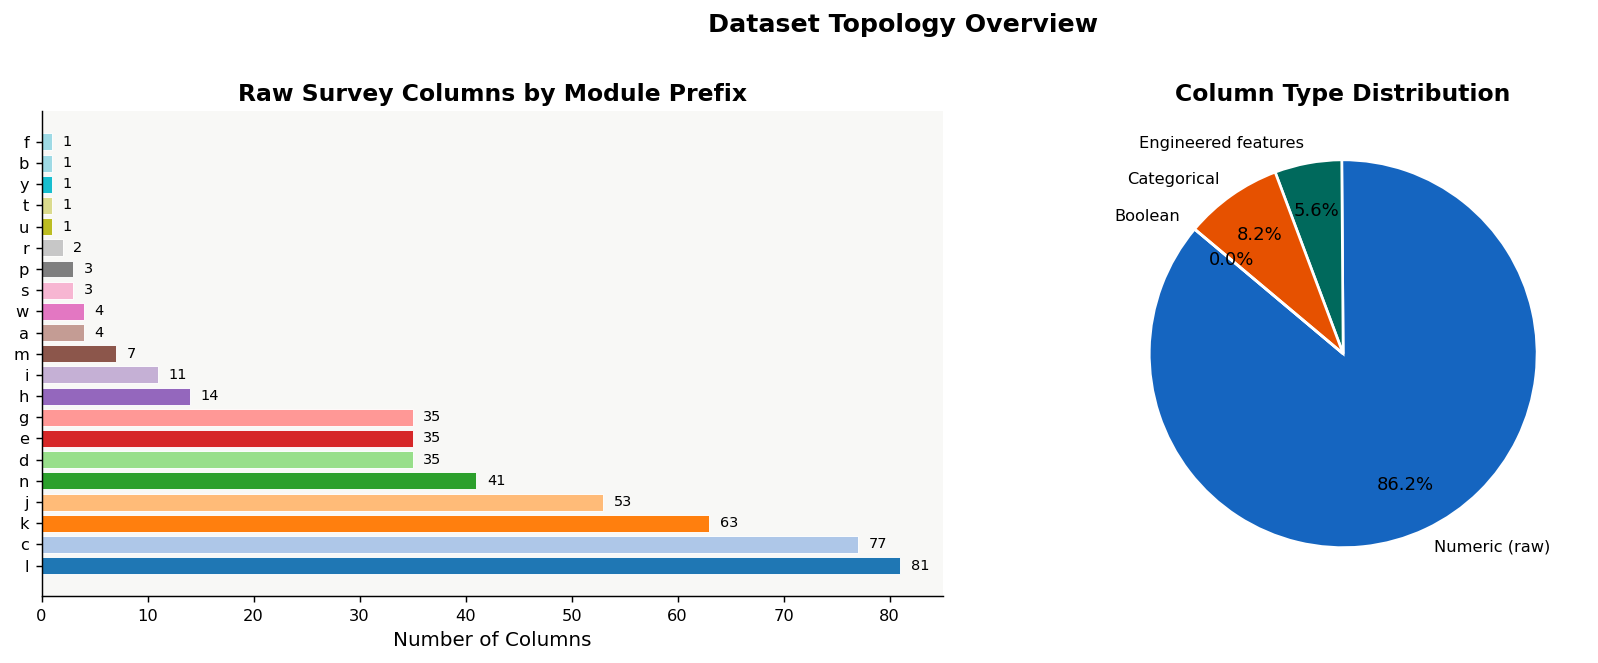


── Column Type Summary ──
  Numeric (raw)            :  432
  Engineered features      :   28
  Categorical              :   41
  Boolean                  :    0


In [27]:

# 1C: Visualise column taxonomy as a sunburst-style bar
modules = {}
for c in raw_cols:
    if len(c) >= 1 and c[0].isalpha():
        modules.setdefault(c[0], []).append(c)

labels = sorted(modules.keys(), key=lambda k: -len(modules[k]))
counts = [len(modules[k]) for k in labels]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: survey module sizes
colors = plt.cm.tab20(np.linspace(0, 1, len(labels)))
bars = axes[0].barh(labels, counts, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title("Raw Survey Columns by Module Prefix")
axes[0].set_xlabel("Number of Columns")
for bar, cnt in zip(bars, counts):
    axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 str(cnt), va='center', fontsize=8)

# Right: column type pie
type_labels = ['Numeric (raw)', 'Engineered features', 'Categorical', 'Boolean']
type_values = [len(num_cols) - len(engineered_cols), len(engineered_cols),
               len(cat_cols), len(bool_cols)]
wedge_colors = [BLUE, TEAL, AMBER, PURPLE]
axes[1].pie(type_values, labels=type_labels, colors=wedge_colors,
            autopct='%1.1f%%', startangle=140, pctdistance=0.75,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title("Column Type Distribution")

plt.suptitle("Dataset Topology Overview", fontsize=14, fontweight='700', y=1.01)
plt.tight_layout()
plt.savefig(FIGS / 'eda01_topology.png', dpi=130, bbox_inches='tight')
plt.show()

# Numeric summary
print("\n── Column Type Summary ──")
for lbl, val in zip(type_labels, type_values):
    print(f"  {lbl:<25}: {val:>4}")


In [28]:

# Compute missingness across ALL columns
miss = df.isnull().mean() * 100
miss = miss[miss > 0].sort_values(ascending=False)

print("=" * 55)
print("MISSINGNESS AUDIT")
print("=" * 55)
print(f"  Columns with zero nulls  : {(df.isnull().sum() == 0).sum():,}")
print(f"  Columns with ANY nulls   : {(df.isnull().sum() > 0).sum():,}")
print(f"  Columns >50% missing     : {(miss > 50).sum():,}")
print(f"  Columns >80% missing     : {(miss > 80).sum():,}")
print(f"  Rows with zero nulls     : {df.dropna().shape[0]:,}  ({df.dropna().shape[0]/len(df)*100:.1f}%)")

print("\n── Top 30 most-missing columns ──")
print(f"  {'Column':<25} {'% Missing':>10}")
print("  " + "─" * 37)
for col, pct in miss.head(30).items():
    bar = "█" * int(pct / 5)
    print(f"  {col:<25} {pct:>9.1f}%  {bar}")


MISSINGNESS AUDIT
  Columns with zero nulls  : 126
  Columns with ANY nulls   : 375
  Columns >50% missing     : 190
  Columns >80% missing     : 116
  Rows with zero nulls     : 0  (0.0%)

── Top 30 most-missing columns ──
  Column                     % Missing
  ─────────────────────────────────────
  nema7_2__0c                   100.0%  ████████████████████
  k10                            99.9%  ███████████████████
  k32                            99.7%  ███████████████████
  k27                            99.4%  ███████████████████
  k24_1                          99.4%  ███████████████████
  l24                            99.3%  ███████████████████
  l27__2                         99.2%  ███████████████████
  l27__1                         99.2%  ███████████████████
  l27__5                         99.2%  ███████████████████
  l27__96                        99.2%  ███████████████████
  l27__3                         99.2%  ███████████████████
  l27__4                         99.

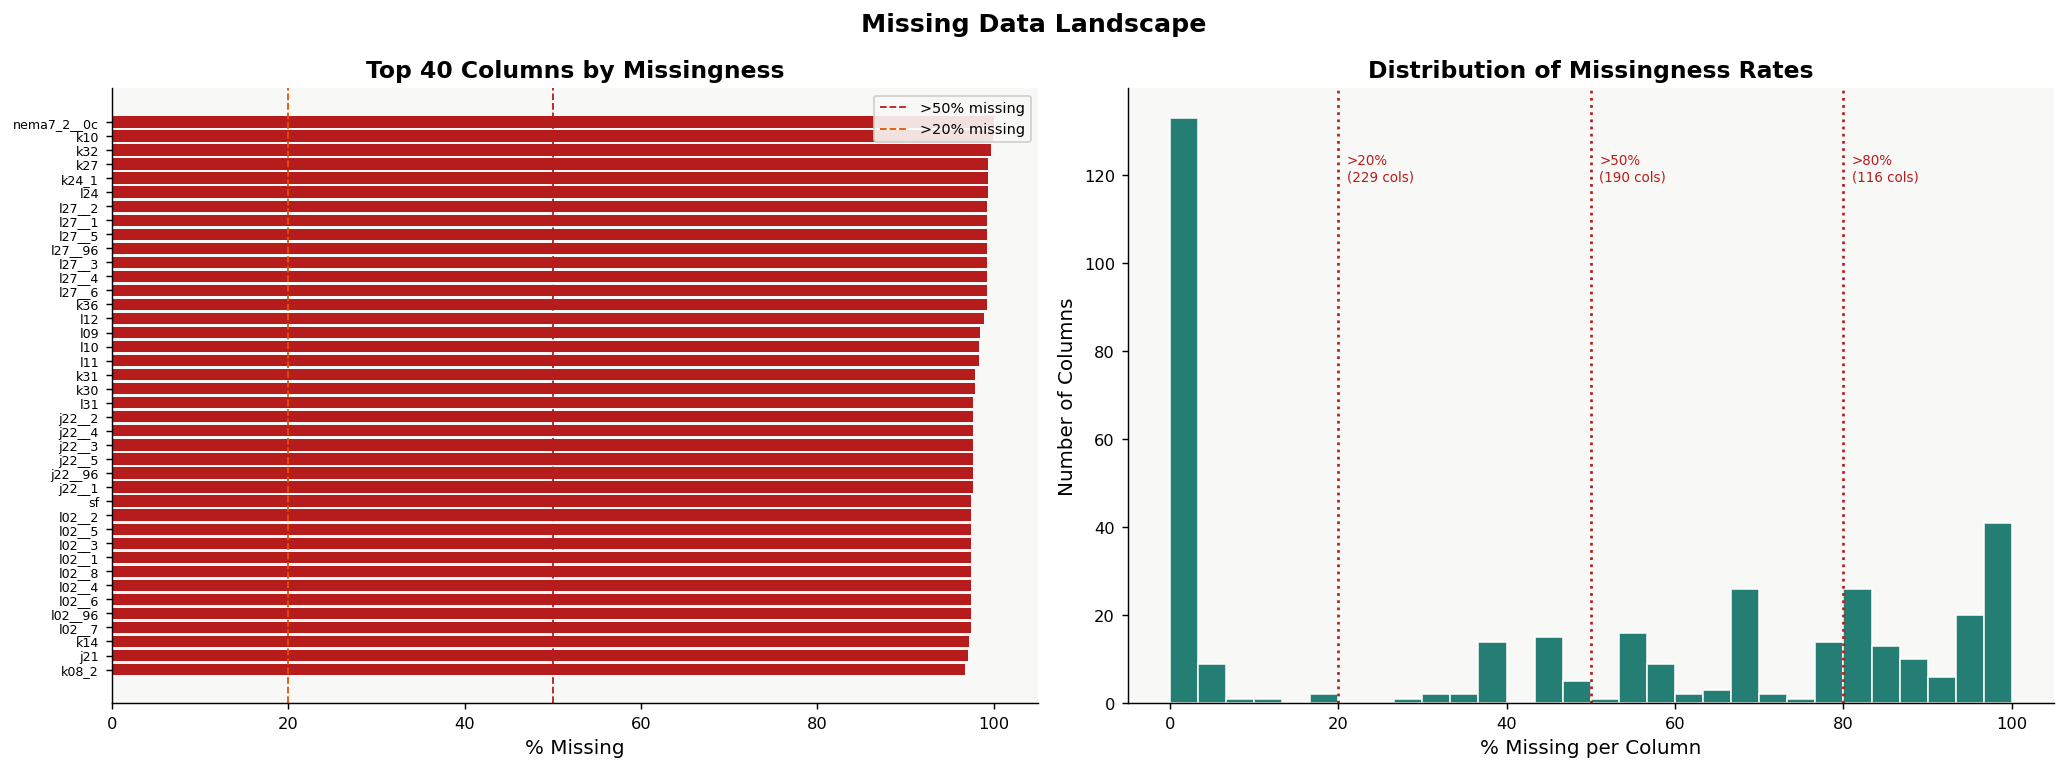


── Missingness Bucket Summary ──
  < 1%      :  107 columns
  1–5%      :   31 columns
  5–20%     :    8 columns
  20–50%    :   39 columns
  50–80%    :   74 columns
  > 80%     :  116 columns


In [29]:

# Missingness heatmap — top 40 columns only (readable)
top_miss_cols = miss.head(40).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: sorted bar of top 40
miss40 = miss.head(40)
bar_colors = [RED if v > 50 else AMBER if v > 20 else BLUE for v in miss40.values]
axes[0].barh(range(len(miss40)), miss40.values, color=bar_colors)
axes[0].set_yticks(range(len(miss40)))
axes[0].set_yticklabels(miss40.index, fontsize=7)
axes[0].set_xlabel("% Missing")
axes[0].set_title("Top 40 Columns by Missingness")
axes[0].axvline(50, color=RED, linestyle='--', lw=1, label='>50% missing')
axes[0].axvline(20, color=AMBER, linestyle='--', lw=1, label='>20% missing')
axes[0].legend(fontsize=8)
axes[0].invert_yaxis()

# Right: histogram of missingness rates
miss_all = df.isnull().mean() * 100
axes[1].hist(miss_all[miss_all > 0], bins=30, color=TEAL, edgecolor='white', alpha=0.85)
axes[1].set_xlabel("% Missing per Column")
axes[1].set_ylabel("Number of Columns")
axes[1].set_title("Distribution of Missingness Rates")
thresholds = [20, 50, 80]
for t in thresholds:
    n = (miss_all > t).sum()
    axes[1].axvline(t, color=RED, linestyle=':', lw=1.5)
    axes[1].text(t+1, axes[1].get_ylim()[1]*0.85, f'>{t}%\n({n} cols)',
                 fontsize=7.5, color=RED)

plt.suptitle("Missing Data Landscape", fontsize=14, fontweight='700')
plt.tight_layout()
plt.savefig(FIGS / 'eda02_missingness.png', dpi=130, bbox_inches='tight')
plt.show()

# Print distribution buckets
print("\n── Missingness Bucket Summary ──")
buckets = [(0,1,'< 1%'), (1,5,'1–5%'), (5,20,'5–20%'), (20,50,'20–50%'), (50,80,'50–80%'), (80,100,'> 80%')]
for lo, hi, label in buckets:
    n = ((miss_all > lo) & (miss_all <= hi)).sum()
    print(f"  {label:<10}: {n:>4} columns")


In [30]:

print("=" * 55)
print("HFVS CONTINUOUS DISTRIBUTION")
print("=" * 55)
desc = df['hfvs'].describe()
for k, v in desc.items():
    print(f"  {k:<8}: {v:.4f}")

sk = df['hfvs'].skew()
ku = df['hfvs'].kurtosis()
print(f"  Skewness : {sk:.4f}  ({'right-skewed' if sk > 0 else 'left-skewed'})")
print(f"  Kurtosis : {ku:.4f}")

print("\n── Threshold Sensitivity ──")
print(f"  {'Threshold':<12} {'N High-Vuln':>13} {'% HHs':>8}")
print("  " + "─" * 35)
for t in np.arange(0.30, 0.81, 0.05):
    n = (df['hfvs'] >= t).sum()
    pct = n / len(df) * 100
    marker = "  ◄ chosen" if abs(t - 0.60) < 0.001 else ""
    print(f"  {t:.2f}        {n:>13,} {pct:>7.1f}%{marker}")

print("\n── Binary Label (threshold=0.60) ──")
vc = df['hfvs_binary'].value_counts()
print(f"  Class 0 (Low-vulnerability) : {vc[0]:,}  ({vc[0]/len(df)*100:.1f}%)")
print(f"  Class 1 (High-vulnerability): {vc[1]:,}  ({vc[1]/len(df)*100:.1f}%)")
print(f"  Imbalance ratio             : {vc[0]/vc[1]:.2f}:1")


HFVS CONTINUOUS DISTRIBUTION
  count   : 21347.0000
  mean    : 0.3657
  std     : 0.1311
  min     : 0.0458
  25%     : 0.2813
  50%     : 0.3530
  75%     : 0.4500
  max     : 0.8255
  Skewness : 0.2270  (right-skewed)
  Kurtosis : -0.2566

── Threshold Sensitivity ──
  Threshold      N High-Vuln    % HHs
  ───────────────────────────────────
  0.30               14,723    69.0%
  0.35               10,897    51.0%
  0.40                7,726    36.2%
  0.45                5,345    25.0%
  0.50                3,630    17.0%
  0.55                2,222    10.4%
  0.60                  994     4.7%  ◄ chosen
  0.65                  362     1.7%
  0.70                   83     0.4%
  0.75                   24     0.1%
  0.80                    2     0.0%

── Binary Label (threshold=0.60) ──
  Class 0 (Low-vulnerability) : 20,353  (95.3%)
  Class 1 (High-vulnerability): 994  (4.7%)
  Imbalance ratio             : 20.48:1


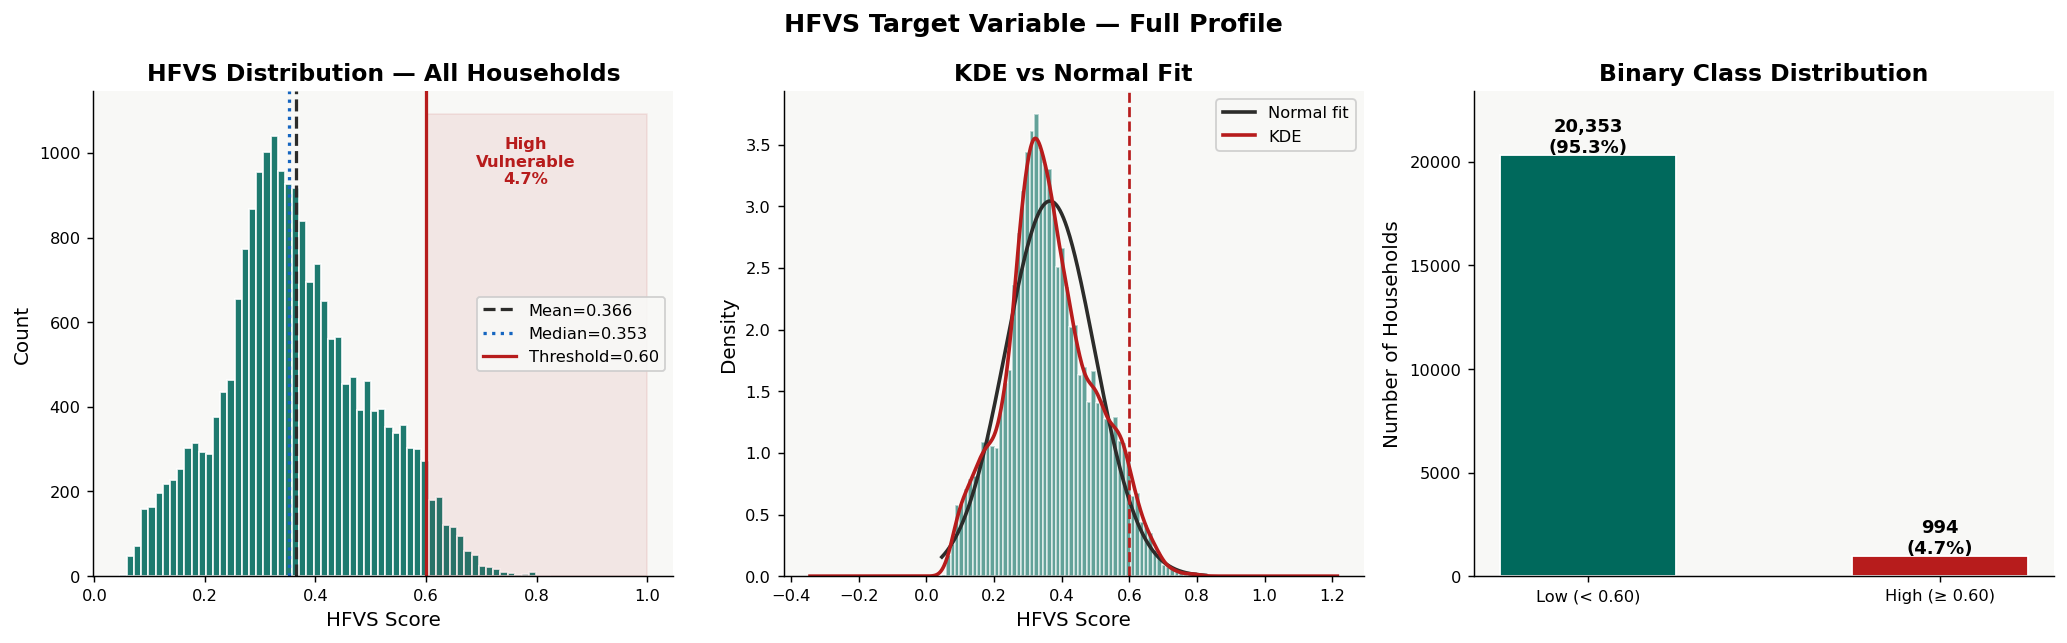

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Left: HFVS histogram ──────────────────────────────────────────────────────
axes[0].hist(df['hfvs'], bins=60, color=TEAL, edgecolor='white', alpha=0.88)
axes[0].axvline(df['hfvs'].mean(),   color=DARK,   linestyle='--', lw=1.8, label=f"Mean={df['hfvs'].mean():.3f}")
axes[0].axvline(df['hfvs'].median(), color=BLUE,   linestyle=':',  lw=1.8, label=f"Median={df['hfvs'].median():.3f}")
axes[0].axvline(0.60,                color=RED,    linestyle='-',  lw=1.8, label='Threshold=0.60')
axes[0].set_xlabel("HFVS Score")
axes[0].set_ylabel("Count")
axes[0].set_title("HFVS Distribution — All Households")
axes[0].legend()

# Annotate region above threshold
ymax = axes[0].get_ylim()[1]
axes[0].fill_betweenx([0, ymax], 0.60, 1.0, alpha=0.08, color=RED)
axes[0].text(0.78, ymax*0.85, f"High\nVulnerable\n{(df['hfvs']>=0.60).mean()*100:.1f}%",
             ha='center', color=RED, fontsize=9, fontweight='bold')

# ── Centre: KDE + normal overlay ─────────────────────────────────────────────
from scipy.stats import norm as spnorm
x_vals = np.linspace(df['hfvs'].min(), df['hfvs'].max(), 300)
mu, sigma = df['hfvs'].mean(), df['hfvs'].std()
axes[1].hist(df['hfvs'], bins=60, density=True, color=TEAL, edgecolor='white', alpha=0.6)
axes[1].plot(x_vals, spnorm.pdf(x_vals, mu, sigma), color=DARK, lw=2, label='Normal fit')
df['hfvs'].plot.kde(ax=axes[1], color=RED, lw=2, label='KDE')
axes[1].axvline(0.60, color=RED, linestyle='--', lw=1.5)
axes[1].set_xlabel("HFVS Score"); axes[1].set_ylabel("Density")
axes[1].set_title("KDE vs Normal Fit")
axes[1].legend()

# ── Right: Binary class bar ────────────────────────────────────────────────────
labels = ['Low (< 0.60)', 'High (≥ 0.60)']
vals   = [df['hfvs_binary'].value_counts()[0], df['hfvs_binary'].value_counts()[1]]
colors = [TEAL, RED]
bars = axes[2].bar(labels, vals, color=colors, edgecolor='white', width=0.5)
for bar, v in zip(bars, vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height()+100,
                 f'{v:,}\n({v/sum(vals)*100:.1f}%)', ha='center', fontsize=10, fontweight='bold')
axes[2].set_ylabel("Number of Households")
axes[2].set_title("Binary Class Distribution")
axes[2].set_ylim(0, max(vals)*1.15)

plt.suptitle("HFVS Target Variable — Full Profile", fontsize=14, fontweight='700')
plt.tight_layout()
plt.savefig(FIGS / 'eda03_target.png', dpi=130, bbox_inches='tight')
plt.show()

In [32]:

d_cols = ['d1_score','d2_score','d3_score','d4_score','d5_score']
d_labels = {
    'd1_score': 'D1 Financial Stress',
    'd2_score': 'D2 Tenure Insecurity',
    'd3_score': 'D3 Physical Hazard',
    'd4_score': 'D4 Dwelling Quality',
    'd5_score': 'D5 Utility Deprivation',
}
d_colors = [RED, AMBER, PURPLE, BLUE, TEAL]

print("=" * 70)
print("HFVS DIMENSION SCORE SUMMARY")
print("=" * 70)
print(f"  {'Dimension':<25} {'Mean':>7} {'Median':>8} {'Std':>7} {'Min':>7} {'Max':>7} {'Skew':>7}")
print("  " + "─" * 70)
for col in d_cols:
    s = df[col]
    print(f"  {d_labels[col]:<25} {s.mean():>7.3f} {s.median():>8.3f} {s.std():>7.3f} "
          f"{s.min():>7.3f} {s.max():>7.3f} {s.skew():>7.3f}")
print(f"\n  HFVS composite          {df['hfvs'].mean():>7.3f} {df['hfvs'].median():>8.3f} "
      f"{df['hfvs'].std():>7.3f} {df['hfvs'].min():>7.3f} {df['hfvs'].max():>7.3f} "
      f"{df['hfvs'].skew():>7.3f}")

print("\n── Correlation between dimensions ──")
corr_d = df[d_cols + ['hfvs']].corr()
print(corr_d.round(3).to_string())


HFVS DIMENSION SCORE SUMMARY
  Dimension                    Mean   Median     Std     Min     Max    Skew
  ──────────────────────────────────────────────────────────────────────
  D1 Financial Stress         0.305    0.333   0.179   0.000   0.833   0.055
  D2 Tenure Insecurity        0.523    0.800   0.399   0.000   1.000  -0.212
  D3 Physical Hazard          0.139    0.110   0.175   0.000   1.000   1.800
  D4 Dwelling Quality         0.454    0.350   0.260   0.025   1.000   0.520
  D5 Utility Deprivation      0.407    0.438   0.255   0.000   1.000  -0.008

  HFVS composite            0.366    0.353   0.131   0.046   0.825   0.227

── Correlation between dimensions ──
          d1_score  d2_score  d3_score  d4_score  d5_score   hfvs
d1_score     1.000    -0.213     0.049     0.229     0.316  0.370
d2_score    -0.213     1.000    -0.025    -0.071    -0.179  0.445
d3_score     0.049    -0.025     1.000     0.115     0.139  0.364
d4_score     0.229    -0.071     0.115     1.000     0.638

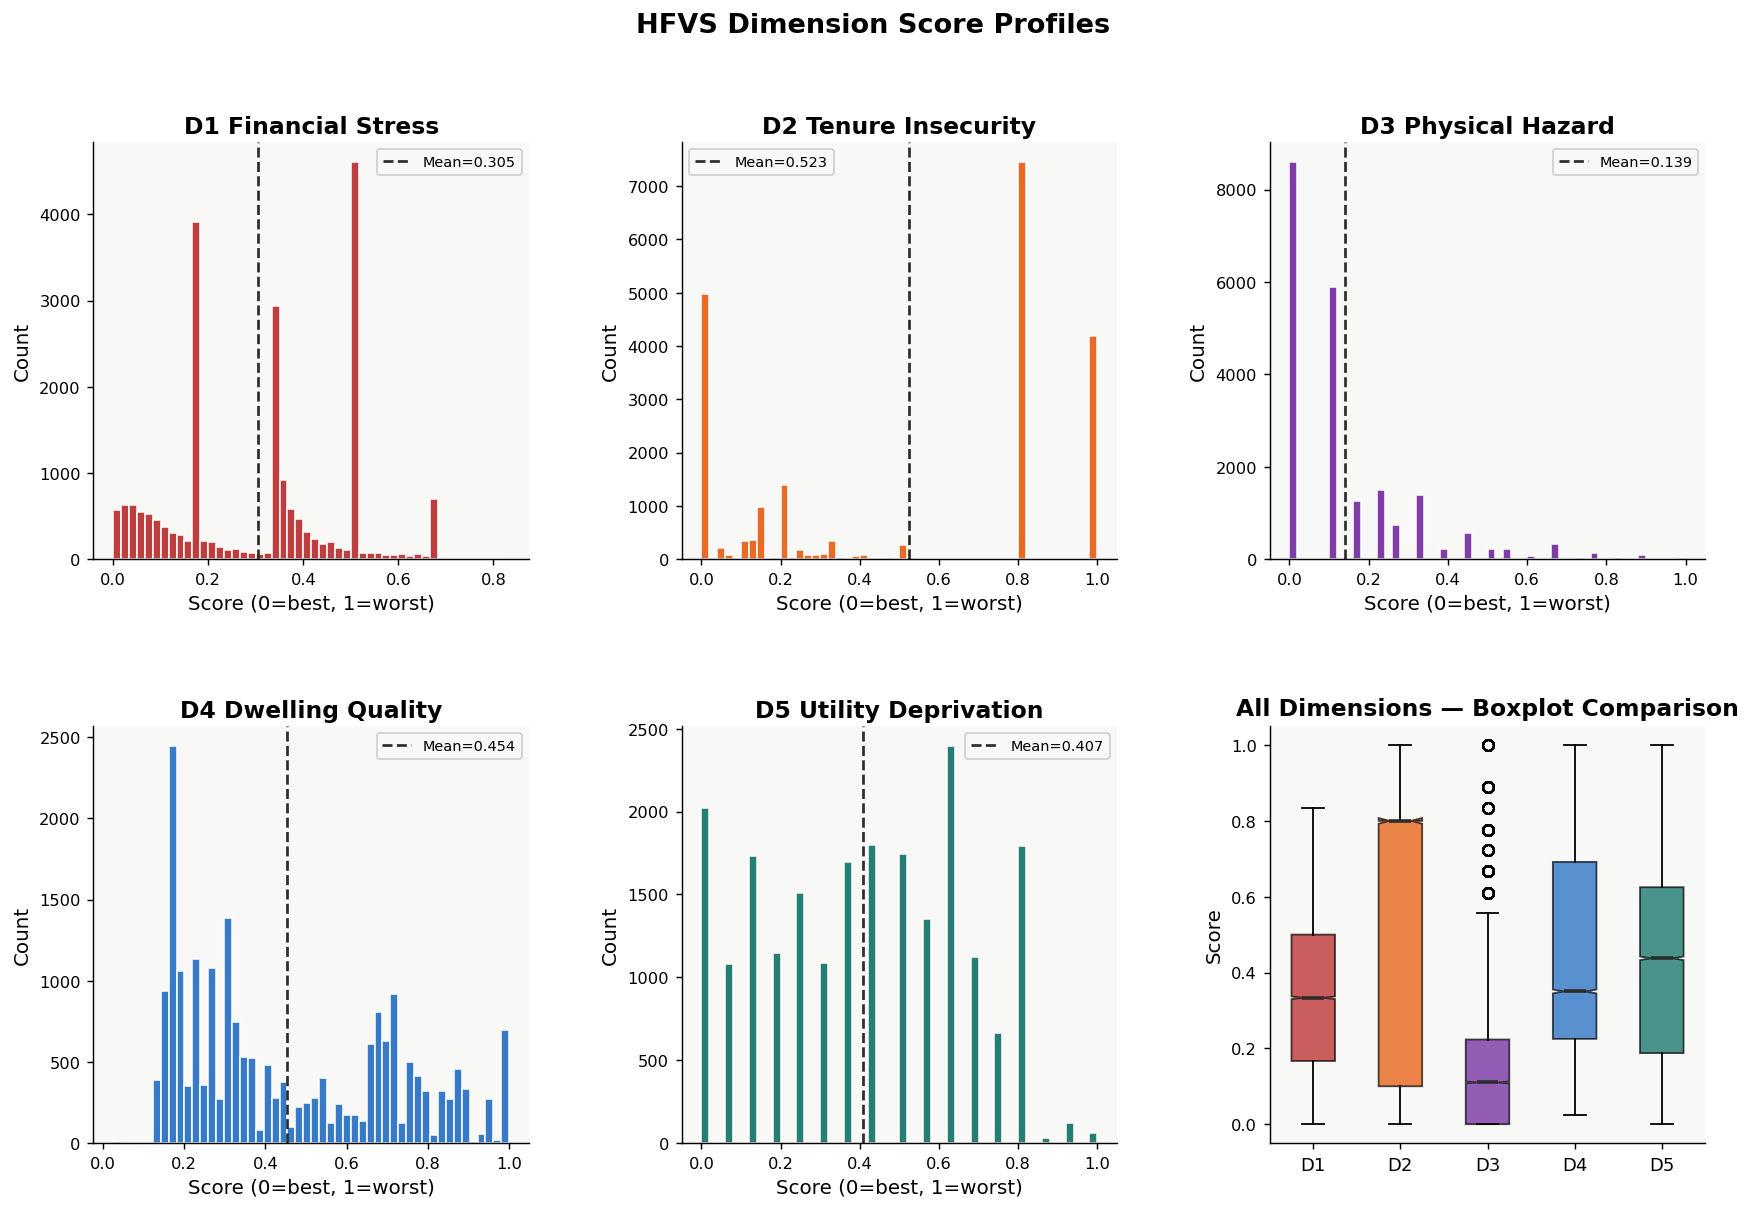


── Dimension Means by HFVS Class ──
  Dimension                Low Vuln  High Vuln    Δ (gap)
  ───────────────────────────────────────────────────────
  D1 Financial Stress         0.297      0.471      0.174
  D2 Tenure Insecurity        0.510      0.797      0.287
  D3 Physical Hazard          0.128      0.369      0.241
  D4 Dwelling Quality         0.434      0.849      0.415
  D5 Utility Deprivation      0.391      0.739      0.348


In [33]:

fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# Individual dimension distributions
for i, (col, color) in enumerate(zip(d_cols, d_colors)):
    r, c = divmod(i, 3)
    ax = fig.add_subplot(gs[r, c])
    ax.hist(df[col], bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color=DARK, linestyle='--', lw=1.5,
               label=f"Mean={df[col].mean():.3f}")
    ax.set_title(d_labels[col], pad=5)
    ax.set_xlabel("Score (0=best, 1=worst)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

# Bottom right: radar / dimension comparison boxplot
ax6 = fig.add_subplot(gs[1, 2])
box_data = [df[c].dropna().values for c in d_cols]
bp = ax6.boxplot(box_data, patch_artist=True, notch=True,
                  medianprops=dict(color=DARK, lw=2))
for patch, color in zip(bp['boxes'], d_colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax6.set_xticks(range(1, 6))
ax6.set_xticklabels(['D1','D2','D3','D4','D5'], fontsize=10)
ax6.set_ylabel("Score")
ax6.set_title("All Dimensions — Boxplot Comparison")

plt.suptitle("HFVS Dimension Score Profiles", fontsize=15, fontweight='700')
plt.savefig(FIGS / 'eda04_dimensions.png', dpi=130, bbox_inches='tight')
plt.show()

# Numeric: mean by class
print("\n── Dimension Means by HFVS Class ──")
print(f"  {'Dimension':<22} {'Low Vuln':>10} {'High Vuln':>10} {'Δ (gap)':>10}")
print("  " + "─" * 55)
for col in d_cols:
    lo = df[df['hfvs_binary']==0][col].mean()
    hi = df[df['hfvs_binary']==1][col].mean()
    print(f"  {d_labels[col]:<22} {lo:>10.3f} {hi:>10.3f} {hi-lo:>10.3f}")


In [34]:

# a07_1: 1=Urban, 2=Rural (from notebook metadata)
res_map = {1:'Urban', 2:'Rural'}
df['residence'] = df['a07_1'].map(res_map).fillna('Unknown')

print("=" * 60)
print("URBAN / RURAL BREAKDOWN")
print("=" * 60)
print(f"  {'Area':<12} {'N HHs':>8} {'Mean HFVS':>11} {'≥0.50':>8} {'≥0.60':>8} {'≥0.70':>8}")
print("  " + "─" * 60)
for grp_name, grp in df.groupby('residence'):
    print(f"  {grp_name:<12} {len(grp):>8,} {grp['hfvs'].mean():>11.3f} "
          f"{(grp['hfvs']>=0.50).mean()*100:>7.1f}% "
          f"{(grp['hfvs']>=0.60).mean()*100:>7.1f}% "
          f"{(grp['hfvs']>=0.70).mean()*100:>7.1f}%")

print("\n── Dimension means by residence ──")
print(f"  {'Dimension':<22} {'Urban':>8} {'Rural':>8} {'Δ Rural-Urban':>14}")
print("  " + "─" * 55)
for col in d_cols:
    u = df[df['residence']=='Urban'][col].mean()
    r = df[df['residence']=='Rural'][col].mean()
    print(f"  {d_labels[col]:<22} {u:>8.3f} {r:>8.3f} {r-u:>14.3f}")

# Statistical test
u_vals = df[df['residence']=='Urban']['hfvs'].dropna()
r_vals = df[df['residence']=='Rural']['hfvs'].dropna()
stat, pval = stats.mannwhitneyu(u_vals, r_vals, alternative='two-sided')
print(f"\n  Mann-Whitney U test (Urban vs Rural HFVS):")
print(f"  U = {stat:.0f},  p = {pval:.2e}  ({'*** significant' if pval < 0.001 else 'not significant'})")


URBAN / RURAL BREAKDOWN
  Area            N HHs   Mean HFVS    ≥0.50    ≥0.60    ≥0.70
  ────────────────────────────────────────────────────────────
  Rural           9,447       0.308     4.3%     0.6%     0.0%
  Urban          11,900       0.411    27.1%     7.9%     0.7%

── Dimension means by residence ──
  Dimension                 Urban    Rural  Δ Rural-Urban
  ───────────────────────────────────────────────────────
  D1 Financial Stress       0.357    0.239         -0.119
  D2 Tenure Insecurity      0.433    0.637          0.204
  D3 Physical Hazard        0.156    0.118         -0.038
  D4 Dwelling Quality       0.558    0.321         -0.237
  D5 Utility Deprivation    0.552    0.225         -0.327

  Mann-Whitney U test (Urban vs Rural HFVS):
  U = 81465380,  p = 0.00e+00  (*** significant)


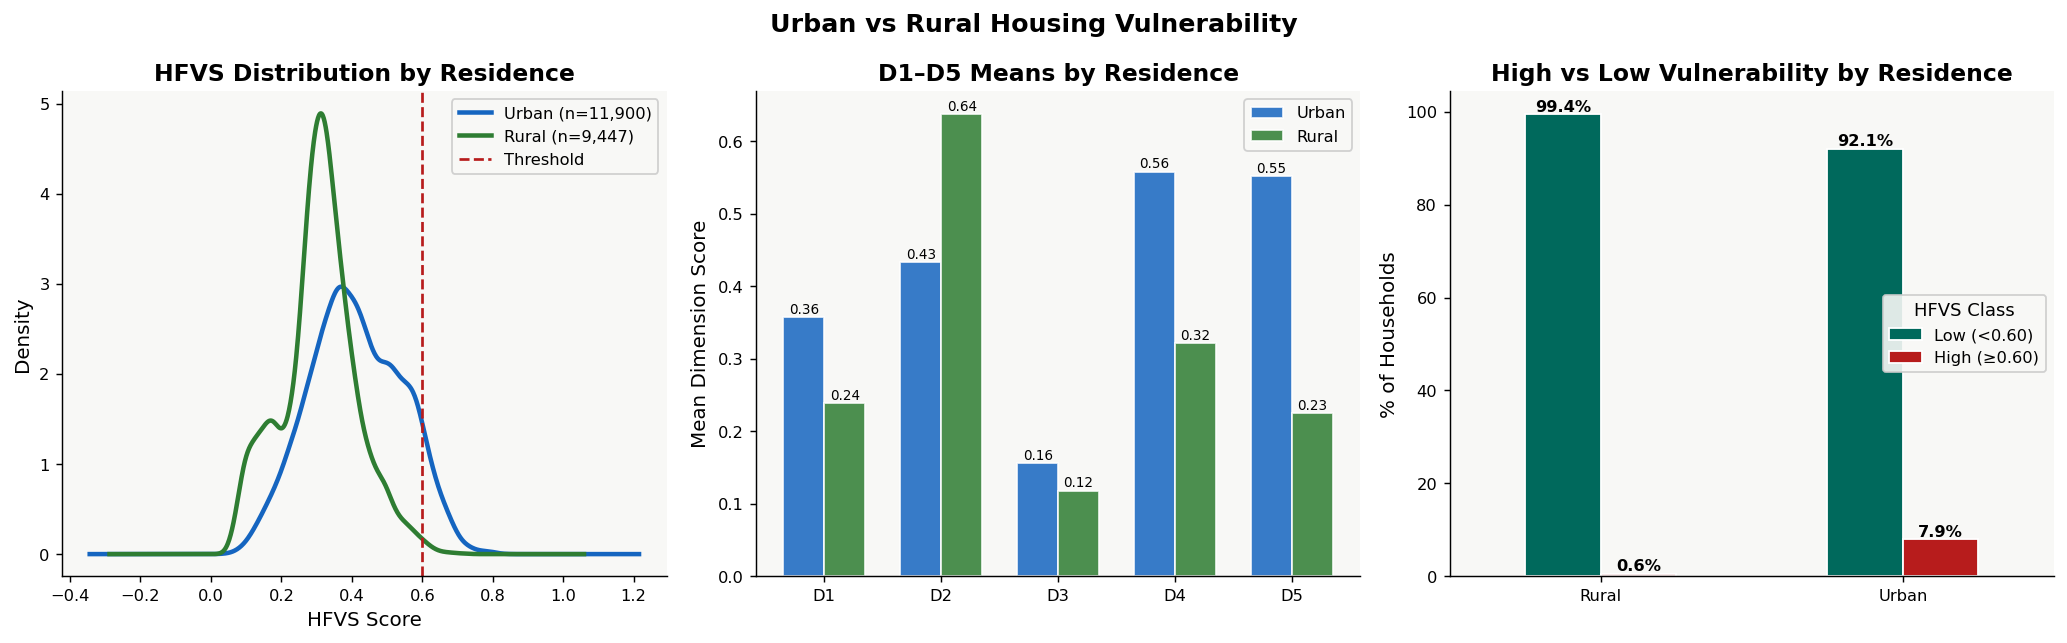

In [35]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Left: HFVS KDE by residence ───────────────────────────────────────────────
for res, color in zip(['Urban','Rural'], [BLUE, GREEN]):
    sub = df[df['residence']==res]['hfvs']
    sub.plot.kde(ax=axes[0], label=f"{res} (n={len(sub):,})", color=color, lw=2.5)
axes[0].axvline(0.60, color=RED, linestyle='--', lw=1.5, label='Threshold')
axes[0].set_xlabel("HFVS Score"); axes[0].set_ylabel("Density")
axes[0].set_title("HFVS Distribution by Residence")
axes[0].legend()

# ── Centre: Dimension radar as grouped bar ─────────────────────────────────────
x = np.arange(5); width = 0.35
u_means = [df[df['residence']=='Urban'][c].mean() for c in d_cols]
r_means = [df[df['residence']=='Rural'][c].mean() for c in d_cols]
b1 = axes[1].bar(x - width/2, u_means, width, label='Urban', color=BLUE, alpha=0.85, edgecolor='white')
b2 = axes[1].bar(x + width/2, r_means, width, label='Rural', color=GREEN, alpha=0.85, edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(['D1','D2','D3','D4','D5'])
axes[1].set_ylabel("Mean Dimension Score"); axes[1].set_title("D1–D5 Means by Residence")
axes[1].legend()
for bar in list(b1) + list(b2):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{bar.get_height():.2f}', ha='center', fontsize=7.5)

# ── Right: binary class proportions stacked ───────────────────────────────────
res_cross = pd.crosstab(df['residence'], df['hfvs_binary'], normalize='index') * 100
res_cross.columns = ['Low (<0.60)', 'High (≥0.60)']
res_cross.plot(kind='bar', ax=axes[2], color=[TEAL, RED], edgecolor='white', width=0.5)
axes[2].set_xlabel(""); axes[2].set_ylabel("% of Households")
axes[2].set_title("High vs Low Vulnerability by Residence")
axes[2].legend(title="HFVS Class")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)
for p in axes[2].patches:
    axes[2].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle("Urban vs Rural Housing Vulnerability", fontsize=14, fontweight='700')
plt.tight_layout()
plt.savefig(FIGS / 'eda05_urban_rural.png', dpi=130, bbox_inches='tight')
plt.show()


In [36]:

county_agg = (
    df.groupby(['a01', 'county_name'])
    .agg(
        n_hh        = ('hfvs',     'count'),
        hfvs_mean   = ('hfvs',     'mean'),
        hfvs_std    = ('hfvs',     'std'),
        pct_high    = ('hfvs',     lambda x: (x >= 0.60).mean() * 100),
        d1_mean     = ('d1_score', 'mean'),
        d2_mean     = ('d2_score', 'mean'),
        d3_mean     = ('d3_score', 'mean'),
        d4_mean     = ('d4_score', 'mean'),
        d5_mean     = ('d5_score', 'mean'),
    )
    .reset_index()
    .sort_values('hfvs_mean', ascending=False)
)
county_agg['rank'] = range(1, len(county_agg)+1)

print("=" * 95)
print("COUNTY VULNERABILITY RANKING  (1 = most vulnerable)")
print("=" * 95)
print(f"  {'Rk':<4} {'County':<20} {'N':>6} {'HFVS':>7}  {'D1':>6}  {'D2':>6}  {'D3':>6}  {'D4':>6}  {'D5':>6}  {'≥0.60':>7}")
print("  " + "─" * 85)
for _, row in county_agg.iterrows():
    print(f"  {int(row['rank']):<4} {str(row['county_name']):<20} {int(row['n_hh']):>6,} "
          f"{row['hfvs_mean']:>7.3f}  {row['d1_mean']:>6.3f}  {row['d2_mean']:>6.3f}  "
          f"{row['d3_mean']:>6.3f}  {row['d4_mean']:>6.3f}  {row['d5_mean']:>6.3f}  "
          f"{row['pct_high']:>6.1f}%")

print(f"\n  National mean HFVS : {df['hfvs'].mean():.3f}")
print(f"  Most vulnerable    : {county_agg.iloc[0]['county_name']} ({county_agg.iloc[0]['hfvs_mean']:.3f})")
print(f"  Least vulnerable   : {county_agg.iloc[-1]['county_name']} ({county_agg.iloc[-1]['hfvs_mean']:.3f})")
print(f"  Range (max-min)    : {county_agg['hfvs_mean'].max() - county_agg['hfvs_mean'].min():.3f}")


COUNTY VULNERABILITY RANKING  (1 = most vulnerable)
  Rk   County                    N    HFVS      D1      D2      D3      D4      D5    ≥0.60
  ─────────────────────────────────────────────────────────────────────────────────────
  1    Tana River              450   0.461   0.286   0.670   0.269   0.580   0.500    16.9%
  2    Wajir                   637   0.460   0.389   0.656   0.075   0.655   0.524    10.5%
  3    Mandera                 503   0.457   0.328   0.634   0.093   0.640   0.592     8.0%
  4    Bomet                   422   0.448   0.346   0.685   0.157   0.527   0.523    14.9%
  5    Marsabit                462   0.444   0.426   0.541   0.075   0.582   0.596    17.3%
  6    Turkana                 368   0.443   0.319   0.475   0.113   0.725   0.582    13.6%
  7    Kisii                   510   0.436   0.374   0.775   0.099   0.478   0.454     4.1%
  8    West Pokot              517   0.434   0.333   0.523   0.179   0.615   0.521    17.0%
  9    Homa Bay                4

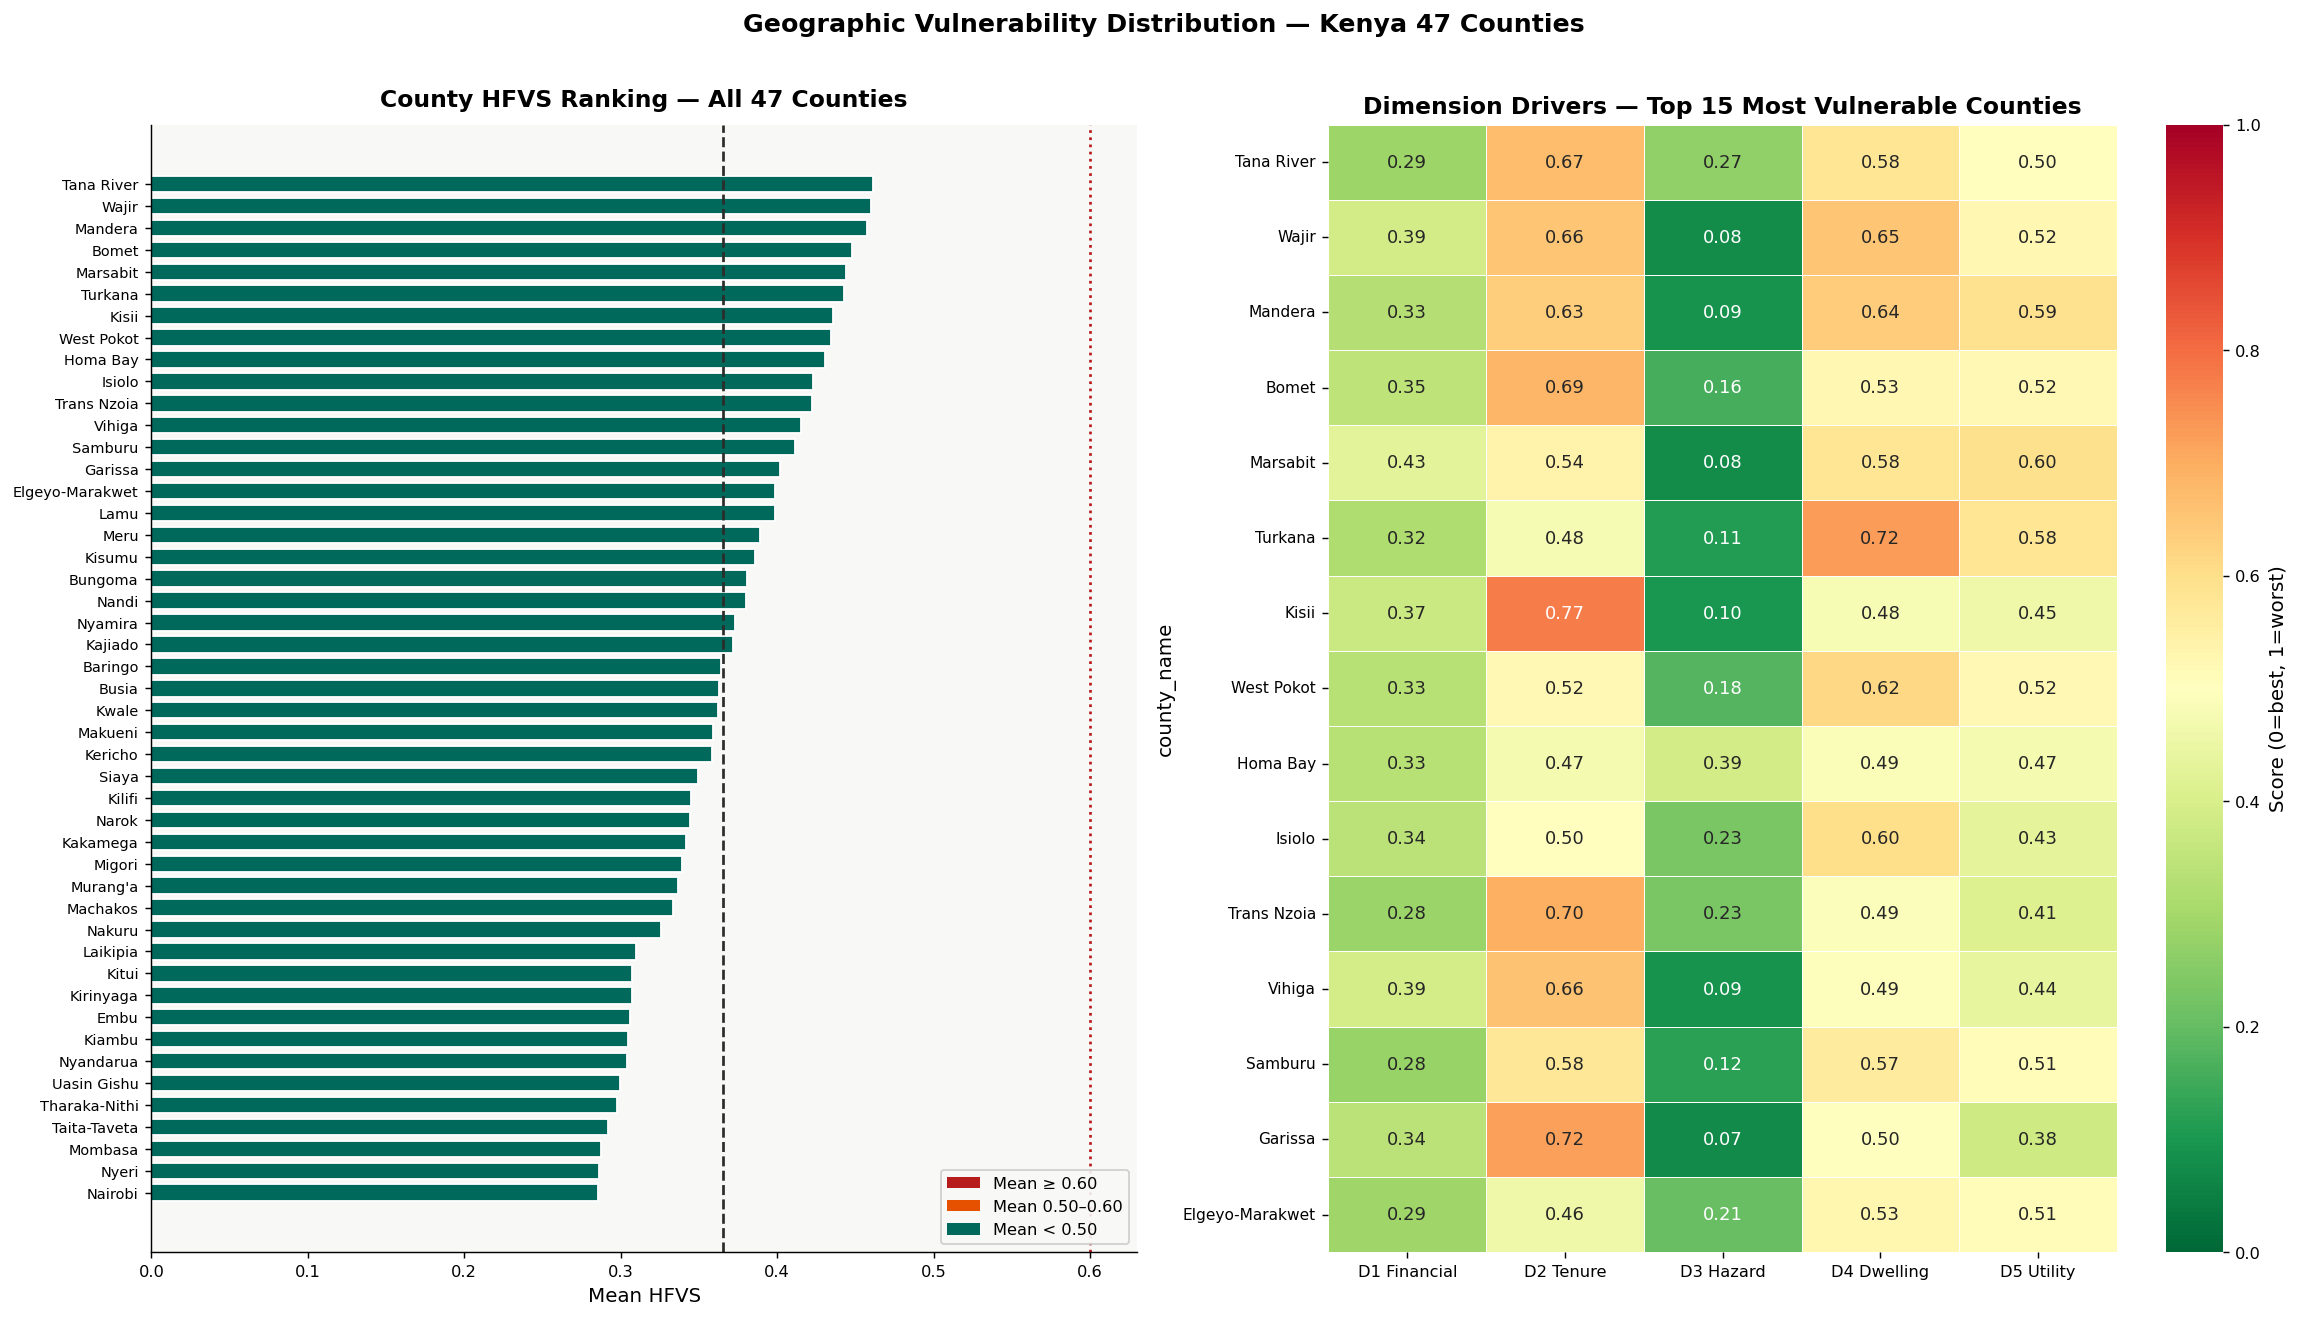


── Top 5 Most Vulnerable Counties (Key Drivers) ──
  #1 Tana River            HFVS=0.461  Main drivers: D2=0.67, D4=0.58
  #2 Wajir                 HFVS=0.460  Main drivers: D2=0.66, D4=0.65
  #3 Mandera               HFVS=0.457  Main drivers: D4=0.64, D2=0.63
  #4 Bomet                 HFVS=0.448  Main drivers: D2=0.69, D4=0.53
  #5 Marsabit              HFVS=0.444  Main drivers: D5=0.60, D4=0.58

── Bottom 5 Least Vulnerable Counties ──
  #43 Tharaka-Nithi         HFVS=0.298
  #44 Taita-Taveta          HFVS=0.292
  #45 Mombasa               HFVS=0.288
  #46 Nyeri                 HFVS=0.286
  #47 Nairobi               HFVS=0.285


In [37]:

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# ── Left: ranked horizontal bar ───────────────────────────────────────────────
sorted_agg = county_agg.sort_values('hfvs_mean')
bar_colors = [RED if v >= 0.60 else AMBER if v >= 0.50 else TEAL for v in sorted_agg['hfvs_mean']]
axes[0].barh(range(len(sorted_agg)), sorted_agg['hfvs_mean'],
             color=bar_colors, edgecolor='white', height=0.75)
axes[0].set_yticks(range(len(sorted_agg)))
axes[0].set_yticklabels(sorted_agg['county_name'], fontsize=8)
axes[0].axvline(df['hfvs'].mean(), color=DARK, linestyle='--', lw=1.5,
                label=f"National mean={df['hfvs'].mean():.3f}")
axes[0].axvline(0.60, color=RED, linestyle=':', lw=1.5, label='Threshold=0.60')
axes[0].set_xlabel("Mean HFVS")
axes[0].set_title("County HFVS Ranking — All 47 Counties", pad=10)
axes[0].legend(fontsize=9)

# Colour legend patches
from matplotlib.patches import Patch
legend_elements = [Patch(fc=RED, label='Mean ≥ 0.60'),
                   Patch(fc=AMBER, label='Mean 0.50–0.60'),
                   Patch(fc=TEAL, label='Mean < 0.50')]
axes[0].legend(handles=legend_elements, fontsize=9, loc='lower right')

# ── Right: dimension driver heatmap (top 20 + bottom 5) ───────────────────────
top20 = county_agg.head(15)
heatmap_data = top20[['d1_mean','d2_mean','d3_mean','d4_mean','d5_mean']].values
sns.heatmap(
    pd.DataFrame(heatmap_data,
                 index=top20['county_name'],
                 columns=['D1 Financial','D2 Tenure','D3 Hazard','D4 Dwelling','D5 Utility']),
    ax=axes[1], annot=True, fmt='.2f', cmap='RdYlGn_r',
    vmin=0, vmax=1, linewidths=0.5, linecolor='white',
    cbar_kws={'label':'Score (0=best, 1=worst)'}
)
axes[1].set_title("Dimension Drivers — Top 15 Most Vulnerable Counties")
axes[1].set_xlabel("")
axes[1].tick_params(axis='y', labelsize=8.5)

plt.suptitle("Geographic Vulnerability Distribution — Kenya 47 Counties",
             fontsize=14, fontweight='700', y=1.01)
plt.tight_layout()
plt.savefig(FIGS / 'eda06_counties.png', dpi=130, bbox_inches='tight')
plt.show()

# Print top 5 + bottom 5
print("\n── Top 5 Most Vulnerable Counties (Key Drivers) ──")
for _, row in county_agg.head(5).iterrows():
    dims = sorted([('D1',row['d1_mean']),('D2',row['d2_mean']),('D3',row['d3_mean']),
                   ('D4',row['d4_mean']),('D5',row['d5_mean'])], key=lambda x: -x[1])
    print(f"  #{int(row['rank'])} {row['county_name']:<20}  HFVS={row['hfvs_mean']:.3f}  "
          f"Main drivers: {dims[0][0]}={dims[0][1]:.2f}, {dims[1][0]}={dims[1][1]:.2f}")

print("\n── Bottom 5 Least Vulnerable Counties ──")
for _, row in county_agg.tail(5).iterrows():
    print(f"  #{int(row['rank'])} {row['county_name']:<20}  HFVS={row['hfvs_mean']:.3f}")


In [38]:

# Focus on interpretable numeric features most likely to matter
focus_numeric = {
    'total_exp_proxy' : 'Total Expenditure Proxy',
    'effective_rent'  : 'Effective Rent (KES)',
    'rent_burden'     : 'Rent Burden (rent/expenditure)',
    'persons_per_room': 'Persons per Room',
    'n_parcels'       : 'Number of Land Parcels',
    'hh_size'         : 'Household Size',
    'wsvc_water_hours': 'Water Service Hours/day',
    'wsvc_unserved_pct':'% Unserved by Water',
    'mort_demand_avg' : 'County Mortgage Demand (avg)',
}

# Subset to those present
focus_present = {k: v for k, v in focus_numeric.items() if k in df.columns}

print("=" * 65)
print("KEY NUMERIC FEATURE DESCRIPTIVE STATISTICS")
print("=" * 65)
print(f"  {'Feature':<28} {'Mean':>9} {'Median':>9} {'Std':>9} {'Skew':>7} {'% Null':>8}")
print("  " + "─" * 65)
for col, label in focus_present.items():
    s = df[col]
    print(f"  {label:<28} {s.mean():>9.2f} {s.median():>9.2f} "
          f"{s.std():>9.2f} {s.skew():>7.2f} {s.isna().mean()*100:>7.1f}%")


KEY NUMERIC FEATURE DESCRIPTIVE STATISTICS
  Feature                           Mean    Median       Std    Skew   % Null
  ─────────────────────────────────────────────────────────────────
  Total Expenditure Proxy       31224.60  16420.00  45212.65    4.69     0.0%
  Effective Rent (KES)          10060.05   3000.00 171104.12   69.58    38.4%
  Rent Burden (rent/expenditure)      0.34      0.21      0.33    0.92    38.4%
  Persons per Room                  2.07      1.67      1.60    1.78     0.0%
  Number of Land Parcels            0.52      0.00      0.64    1.24     0.0%
  Household Size                    3.79      4.00      2.25    0.80     0.0%
  Water Service Hours/day           6.44      5.00      4.93    1.75     6.2%
  % Unserved by Water               3.00      2.00      4.07    2.21    10.5%
  County Mortgage Demand (avg)      3.64      3.88      1.50   -0.53    59.9%


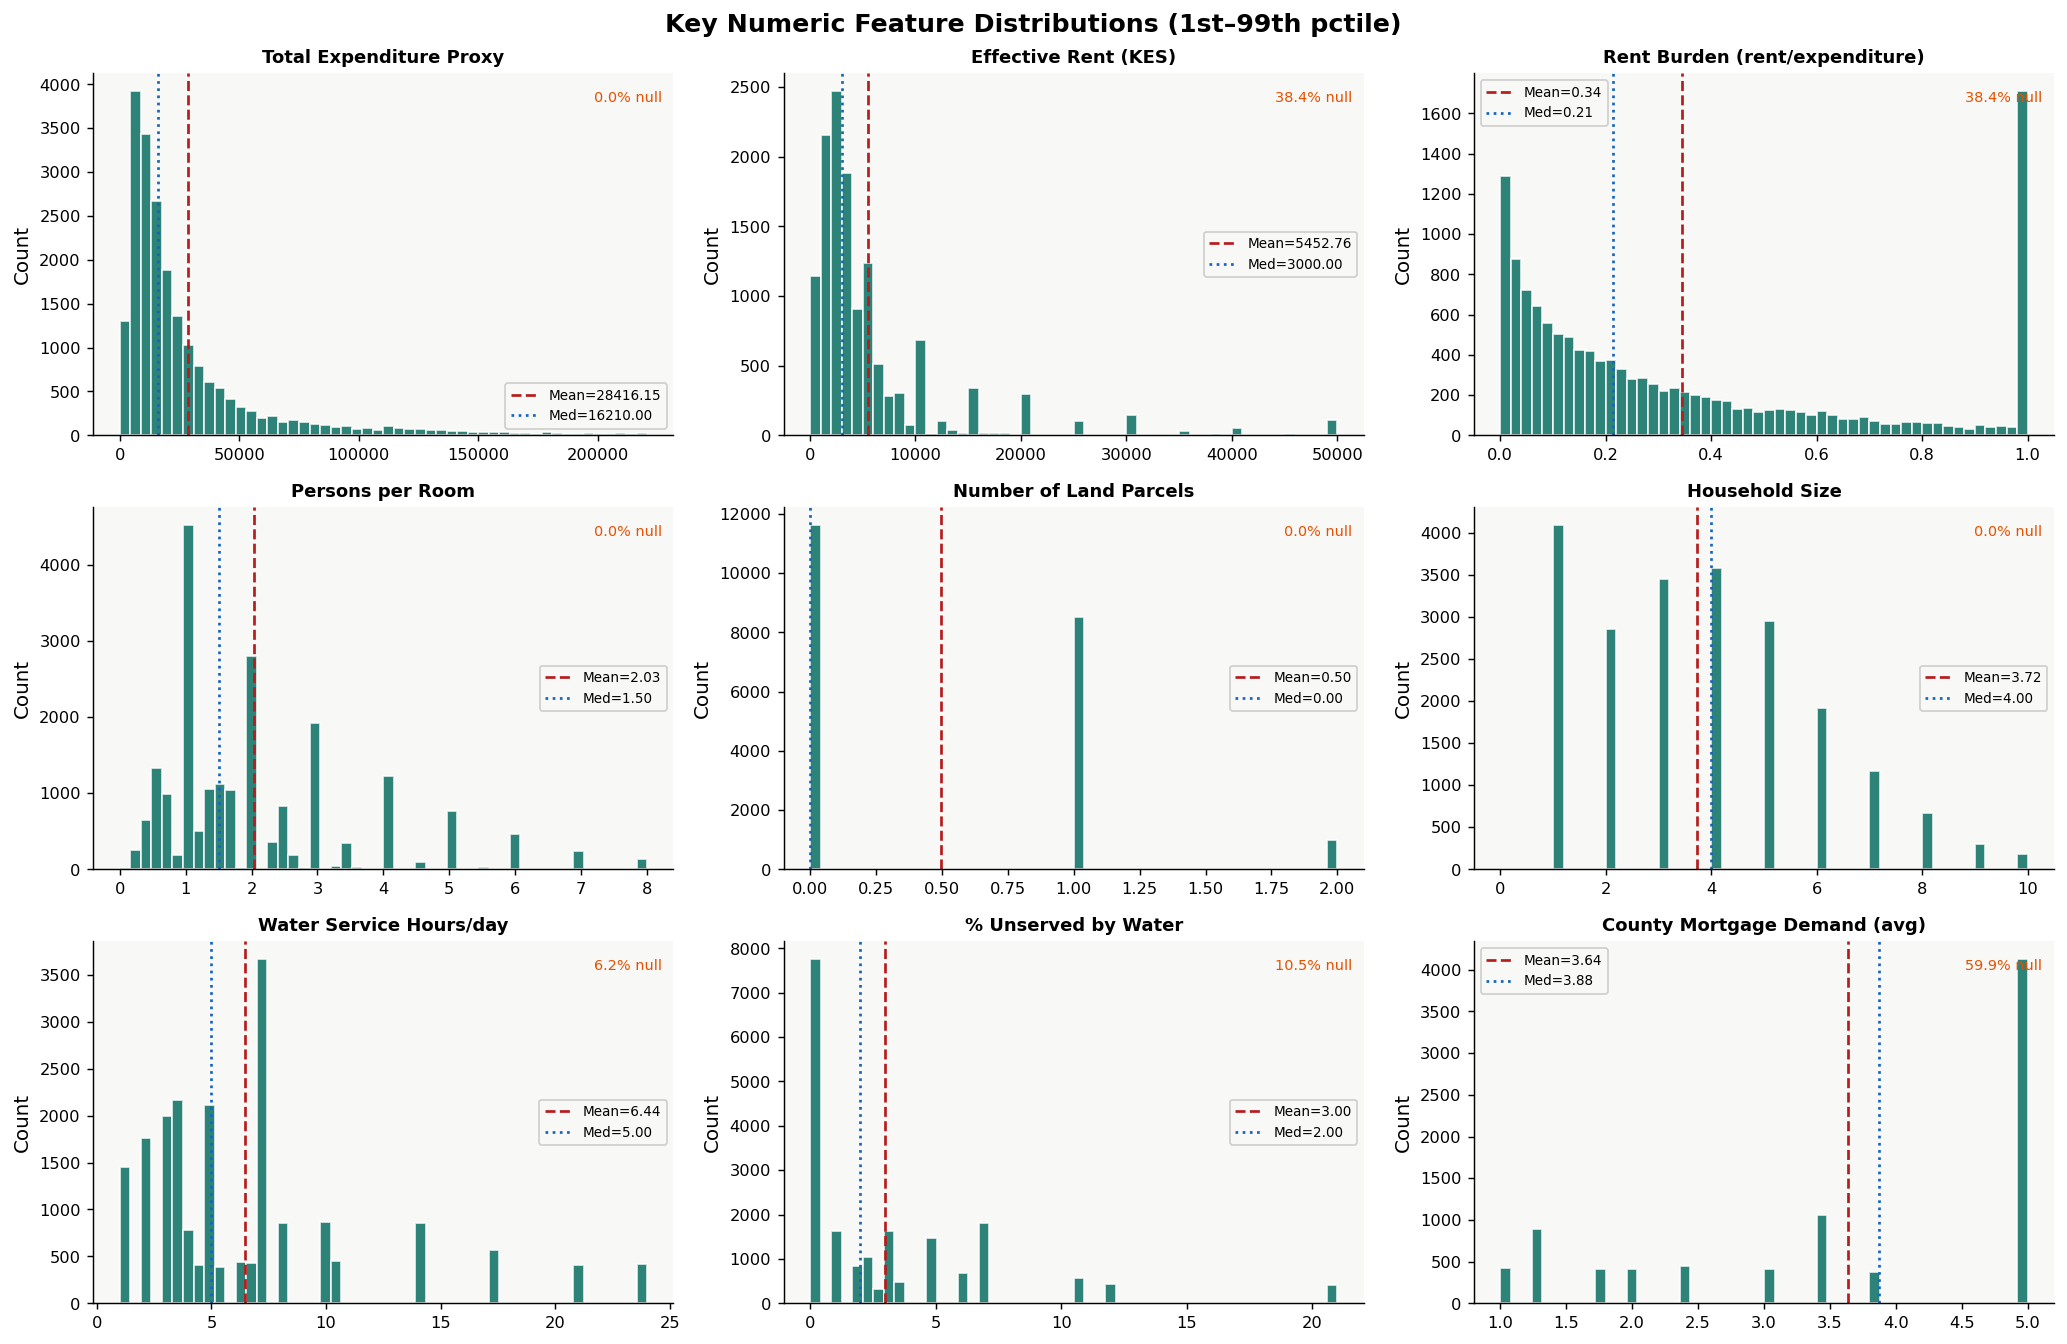

In [39]:

n_feats = len(focus_present)
ncols = 3
nrows = int(np.ceil(n_feats / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()

for i, (col, label) in enumerate(focus_present.items()):
    ax = axes[i]
    data = df[col].dropna()
    # Winsorise for display (remove top 1%)
    p99 = data.quantile(0.99)
    data_win = data[data <= p99]

    ax.hist(data_win, bins=50, color=TEAL, edgecolor='white', alpha=0.82)
    ax.axvline(data_win.mean(), color=RED, linestyle='--', lw=1.5,
               label=f"Mean={data_win.mean():.2f}")
    ax.axvline(data_win.median(), color=BLUE, linestyle=':', lw=1.5,
               label=f"Med={data_win.median():.2f}")
    ax.set_title(label, fontsize=10)
    ax.set_ylabel("Count")
    ax.legend(fontsize=7.5)
    null_pct = df[col].isna().mean() * 100
    if null_pct > 0:
        ax.text(0.98, 0.92, f"{null_pct:.1f}% null", transform=ax.transAxes,
                ha='right', fontsize=8, color=AMBER)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Key Numeric Feature Distributions (1st–99th pctile)", fontsize=14, fontweight='700')
plt.tight_layout()
plt.savefig(FIGS / 'eda07_numerics.png', dpi=130, bbox_inches='tight')
plt.show()


In [40]:

# Key categorical/binary columns
cat_focus = {
    'i00'   : 'Land Ownership (0=No, 1=Yes)',
    'a07_1' : 'Urban/Rural (1=Urban, 2=Rural)',
    'c01_1' : 'Main Water Source',
    'c04'   : 'Toilet Facility Type',
    'c10'   : 'Electricity Source',
    'c11'   : 'Cooking Fuel',
    'd03'   : 'Wall Material',
    'd15'   : 'Roof Material',
    'd16'   : 'Floor Material',
}
cat_present = {k: v for k, v in cat_focus.items() if k in df.columns}

print("=" * 65)
print("KEY CATEGORICAL FEATURE PROFILES")
print("=" * 65)
for col, label in cat_present.items():
    vc = df[col].value_counts(dropna=False).head(8)
    print(f"\n  {label} ({col})")
    print(f"  {'Value':<8} {'Count':>8} {'%':>8}")
    print("  " + "─" * 28)
    for val, cnt in vc.items():
        pct = cnt / len(df) * 100
        print(f"  {str(val):<8} {cnt:>8,} {pct:>7.1f}%")


KEY CATEGORICAL FEATURE PROFILES

  Land Ownership (0=No, 1=Yes) (i00)
  Value       Count        %
  ────────────────────────────
  0.0        11,639    54.5%
  1.0         9,707    45.5%
  nan             1     0.0%

  Urban/Rural (1=Urban, 2=Rural) (a07_1)
  Value       Count        %
  ────────────────────────────
  1          11,900    55.7%
  2           9,447    44.3%

  Main Water Source (c01_1)
  Value       Count        %
  ────────────────────────────
  1           5,729    26.8%
  10          3,854    18.1%
  4           2,609    12.2%
  9           1,951     9.1%
  2           1,546     7.2%
  3           1,477     6.9%
  7           1,294     6.1%
  5           1,065     5.0%

  Toilet Facility Type (c04)
  Value       Count        %
  ────────────────────────────
  7           8,689    40.7%
  8           4,229    19.8%
  6           2,129    10.0%
  2           1,833     8.6%
  13          1,812     8.5%
  1           1,253     5.9%
  3           1,043     4.9%
  5     

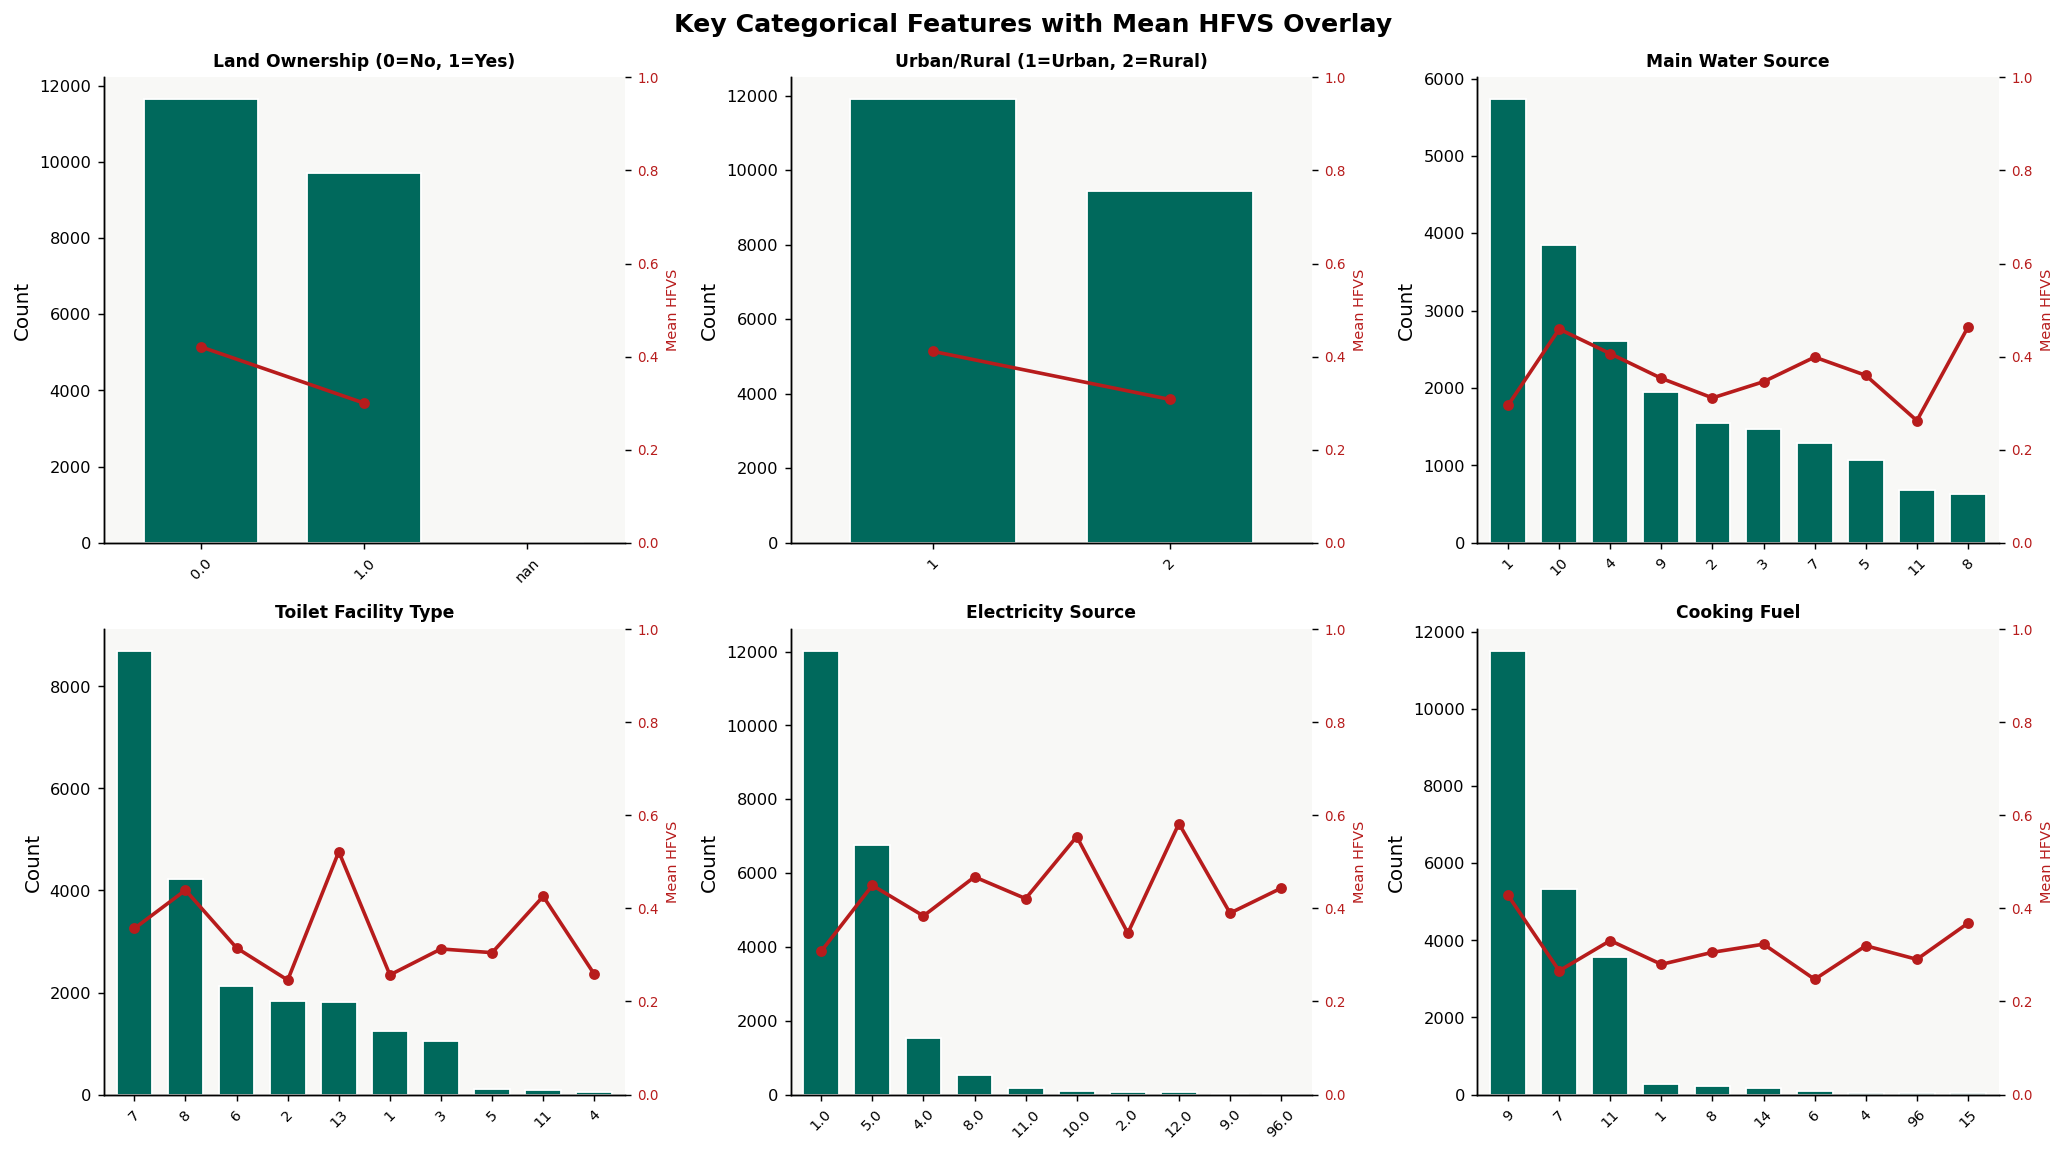

In [41]:

cols_to_plot = list(cat_present.keys())[:6]
nrows = 2; ncols = 3
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    ax = axes[i]
    label = cat_present[col]
    vc = df[col].value_counts(dropna=False).head(10)
    bar_c = [RED if v == df[df['hfvs_binary']==1][col].mode().values[0] else TEAL for v in vc.index]
    vc.plot(kind='bar', ax=ax, color=TEAL, edgecolor='white', width=0.7)
    ax.set_title(label, fontsize=9.5)
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=45, labelsize=8)

    # Overlay HFVS mean per category
    ax2 = ax.twinx()
    means = df.groupby(col)['hfvs'].mean().reindex(vc.index)
    ax2.plot(range(len(means)), means.values, 'o-', color=RED, lw=2, ms=5, label='Mean HFVS')
    ax2.set_ylabel("Mean HFVS", color=RED, fontsize=8)
    ax2.tick_params(axis='y', labelcolor=RED, labelsize=7.5)
    ax2.set_ylim(0, 1)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Key Categorical Features with Mean HFVS Overlay", fontsize=14, fontweight='700')
plt.tight_layout()
plt.savefig(FIGS / 'eda08_categoricals.png', dpi=130, bbox_inches='tight')
plt.show()


In [42]:

# Pearson + Spearman correlations of numeric cols vs hfvs
numeric_raw = df.select_dtypes(include=[np.number]).columns.tolist()
# Exclude target and formula ancestors
exclude = set(['hfvs','hfvs_binary','d1_score','d2_score','d3_score','d4_score','d5_score',
               'rent_burden','no_savings','no_loan_access','d2_no_land','d2_no_agreement',
               'd2_tenure_sys','d2_doc_insecurity','d2_eviction','d3_flood','d3_mudslide',
               'd3_terrain','d4_wall','d4_roof','d4_floor','d4_overcrowd',
               'd5_water','d5_toilet','d5_electric','d5_cooking',
               'effective_rent','total_exp_proxy'])

candidates = [c for c in numeric_raw if c not in exclude and df[c].isna().mean() < 0.5]

pearson_corrs = {}
spearman_corrs = {}
for col in candidates:
    valid = df[['hfvs', col]].dropna()
    if len(valid) < 100:
        continue
    pearson_corrs[col]  = valid['hfvs'].corr(valid[col], method='pearson')
    spearman_corrs[col] = valid['hfvs'].corr(valid[col], method='spearman')

p_series = pd.Series(pearson_corrs).sort_values(key=abs, ascending=False)
s_series = pd.Series(spearman_corrs).sort_values(key=abs, ascending=False)

print("=" * 60)
print("TOP 30 FEATURES CORRELATED WITH HFVS")
print("=" * 60)
print(f"  {'Feature':<25} {'Pearson':>10} {'Spearman':>10}")
print("  " + "─" * 48)
for col in p_series.head(30).index:
    print(f"  {col:<25} {p_series.get(col, np.nan):>10.4f} {s_series.get(col, np.nan):>10.4f}")

print(f"\n  Total features assessed: {len(p_series)}")
print(f"  |Pearson| > 0.20       : {(p_series.abs() > 0.20).sum()}")
print(f"  |Pearson| > 0.10       : {(p_series.abs() > 0.10).sum()}")


TOP 30 FEATURES CORRELATED WITH HFVS
  Feature                      Pearson   Spearman
  ────────────────────────────────────────────────
  material_min                 -0.6739    -0.6585
  floor_score_min              -0.6244    -0.6304
  wall_score_min               -0.6107    -0.6139
  d14_worst                    -0.5477    -0.5328
  d05_fenced                   -0.5034    -0.5065
  c08                          -0.5006    -0.5038
  i06_worst                     0.4751     0.4795
  i00                          -0.4583    -0.4326
  utilities                    -0.4251    -0.4211
  n_parcels                    -0.4229    -0.4311
  d15_worst                    -0.4061    -0.4739
  c12                           0.4040     0.5388
  a07_1                        -0.3910    -0.3865
  persons_per_room              0.3433     0.3442
  c04                           0.3416     0.5516
  d04_shared                    0.3176     0.3156
  c10                           0.3006     0.5167
  l21       

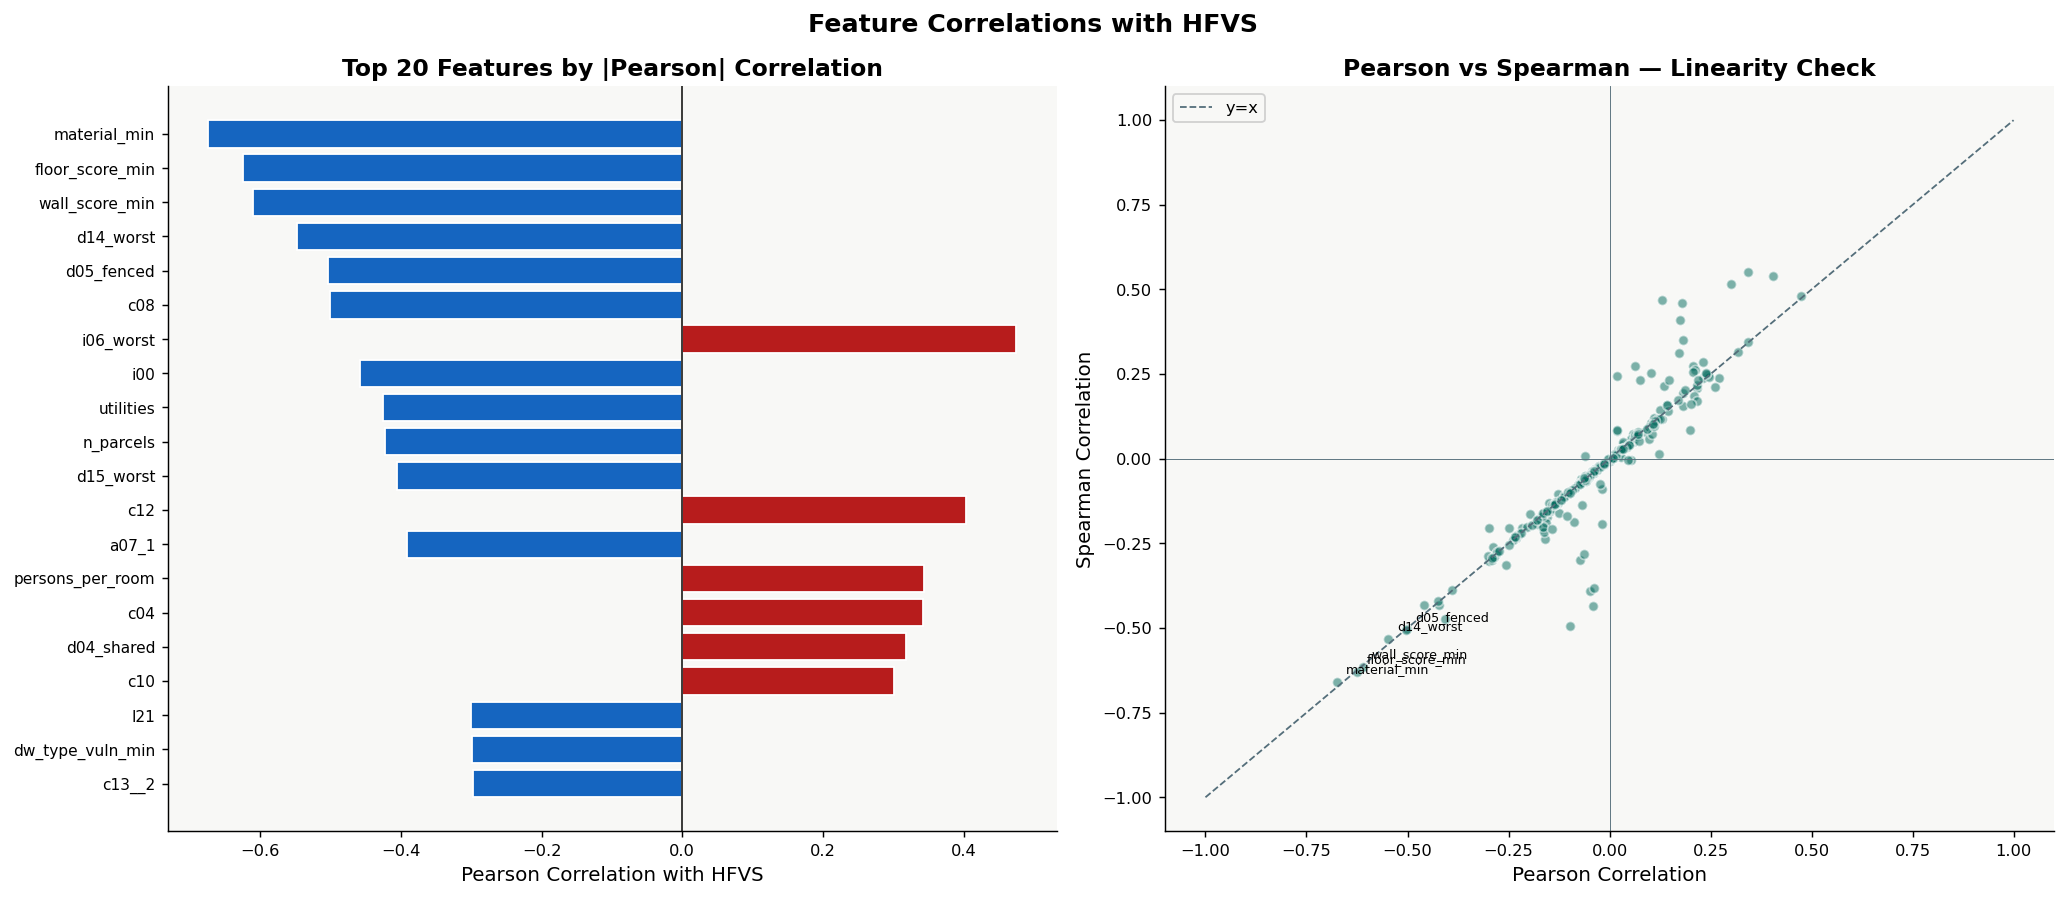

In [43]:

top20_cols = p_series.head(20).index.tolist()
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Left: correlation bar ──────────────────────────────────────────────────────
colors = [RED if v > 0 else BLUE for v in p_series.head(20).values]
axes[0].barh(range(20), p_series.head(20).values[::-1],
             color=colors[::-1], edgecolor='white')
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(p_series.head(20).index[::-1], fontsize=8.5)
axes[0].axvline(0, color=DARK, lw=1)
axes[0].set_xlabel("Pearson Correlation with HFVS")
axes[0].set_title("Top 20 Features by |Pearson| Correlation")

# ── Right: Pearson vs Spearman scatter ─────────────────────────────────────────
common = list(set(p_series.index) & set(s_series.index))
px = [p_series[c] for c in common]
sx = [s_series[c] for c in common]
axes[1].scatter(px, sx, alpha=0.5, color=TEAL, s=30, edgecolor='white')
axes[1].plot([-1,1],[-1,1], color=GRAY, linestyle='--', lw=1, label='y=x')
axes[1].set_xlabel("Pearson Correlation")
axes[1].set_ylabel("Spearman Correlation")
axes[1].set_title("Pearson vs Spearman — Linearity Check")
axes[1].axhline(0, color=GRAY, lw=0.5); axes[1].axvline(0, color=GRAY, lw=0.5)

# Annotate extreme points
for col in p_series.head(5).index:
    if col in p_series.index and col in s_series.index:
        axes[1].annotate(col, (p_series[col], s_series[col]), fontsize=7,
                         xytext=(5,5), textcoords='offset points')

axes[1].legend()

plt.suptitle("Feature Correlations with HFVS", fontsize=14, fontweight='700')
plt.tight_layout()
plt.savefig(FIGS / 'eda09_correlations.png', dpi=130, bbox_inches='tight')
plt.show()


In [44]:

# MI treats non-linear relationships — critical for tree/boosting models
mi_cols = [c for c in candidates if df[c].isna().mean() < 0.3]
mi_df = df[mi_cols + ['hfvs_binary']].dropna()

# Encode
X_mi = mi_df[mi_cols].copy()
y_mi = mi_df['hfvs_binary']

# Fill remaining NaN with median for MI computation
X_mi = X_mi.fillna(X_mi.median())

mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)
mi_series = pd.Series(mi_scores, index=mi_cols).sort_values(ascending=False)

print("=" * 55)
print("MUTUAL INFORMATION SCORES vs. hfvs_binary")
print("(Captures non-linear dependencies)")
print("=" * 55)
print(f"  {'Feature':<25} {'MI Score':>10}")
print("  " + "─" * 38)
for col, score in mi_series.head(30).items():
    bar = "█" * int(score * 100)
    print(f"  {col:<25} {score:>10.4f}  {bar}")

print(f"\n  Features with MI > 0.01 : {(mi_series > 0.01).sum()}")
print(f"  Features with MI > 0.05 : {(mi_series > 0.05).sum()}")
print(f"  Features with MI > 0.10 : {(mi_series > 0.10).sum()}")


MUTUAL INFORMATION SCORES vs. hfvs_binary
(Captures non-linear dependencies)
  Feature                     MI Score
  ──────────────────────────────────────
  hhweight                      0.0516  █████
  material_min                  0.0382  ███
  county_code_wsvc              0.0353  ███
  county_code                   0.0353  ███
  n_parcels                     0.0349  ███
  county_code_mort              0.0340  ███
  i05_worst                     0.0340  ███
  a01                           0.0338  ███
  i00                           0.0331  ███
  nema1a                        0.0329  ███
  nema2a                        0.0324  ███
  nema1b                        0.0323  ███
  d14_worst                     0.0319  ███
  i06_worst                     0.0305  ███
  i12_evict_risk                0.0297  ██
  wsvc_water_hours              0.0270  ██
  nema2b                        0.0268  ██
  e07                           0.0267  ██
  d15_worst                     0.0248  ██
  i10_bequ

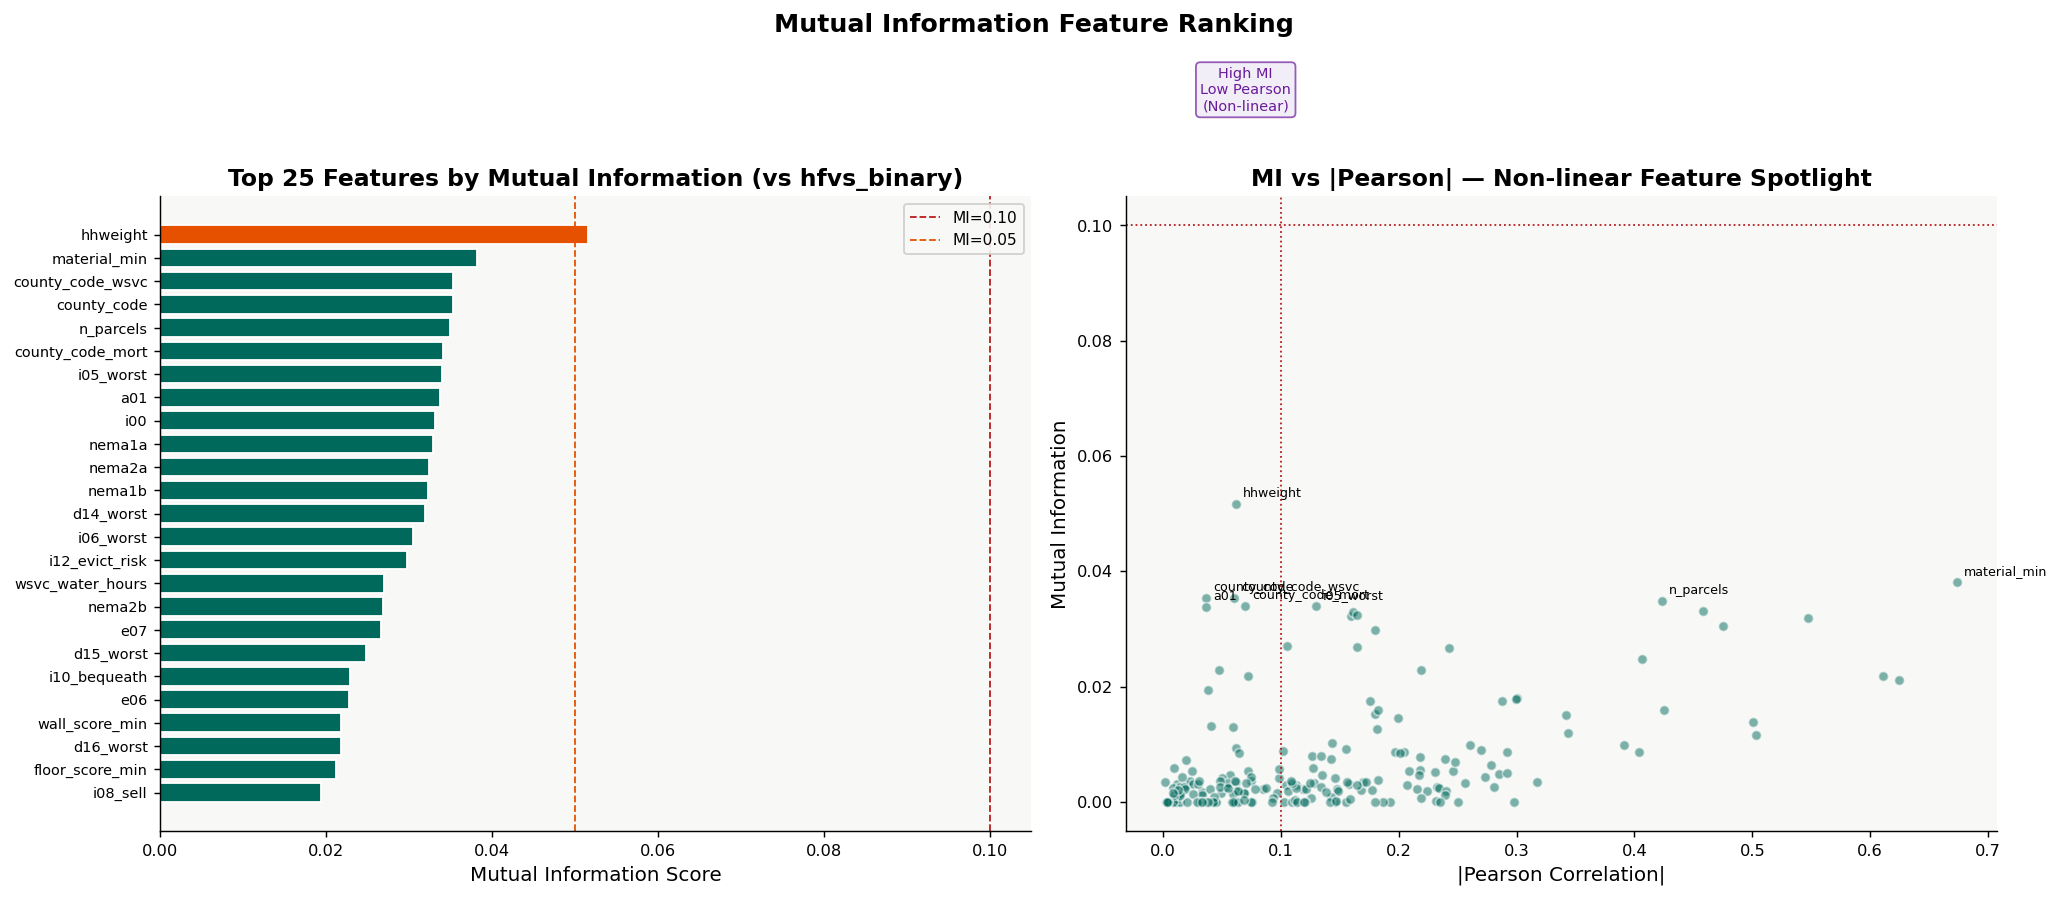

In [45]:

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Left: top 25 MI bar ───────────────────────────────────────────────────────
top25_mi = mi_series.head(25)
bar_colors = [RED if v > 0.10 else AMBER if v > 0.05 else TEAL for v in top25_mi.values]
axes[0].barh(range(25), top25_mi.values[::-1], color=bar_colors[::-1], edgecolor='white')
axes[0].set_yticks(range(25))
axes[0].set_yticklabels(top25_mi.index[::-1], fontsize=8)
axes[0].set_xlabel("Mutual Information Score")
axes[0].set_title("Top 25 Features by Mutual Information (vs hfvs_binary)")
axes[0].axvline(0.10, color=RED,   linestyle='--', lw=1, label='MI=0.10')
axes[0].axvline(0.05, color=AMBER, linestyle='--', lw=1, label='MI=0.05')
axes[0].legend(fontsize=8.5)

# ── Right: MI vs Pearson (discover non-linear heavyweights) ───────────────────
shared = list(set(mi_series.index) & set(p_series.index))
mi_x = [mi_series[c] for c in shared]
pe_x = [abs(p_series[c]) for c in shared]
axes[1].scatter(pe_x, mi_x, alpha=0.5, color=TEAL, s=30, edgecolor='white')
axes[1].set_xlabel("|Pearson Correlation|")
axes[1].set_ylabel("Mutual Information")
axes[1].set_title("MI vs |Pearson| — Non-linear Feature Spotlight")
axes[1].axvline(0.10, color=RED,   linestyle=':', lw=1)
axes[1].axhline(0.10, color=RED,   linestyle=':', lw=1)

# Annotate top MI features
for col in mi_series.head(8).index:
    if col in shared:
        axes[1].annotate(col, (abs(p_series.get(col,0)), mi_series[col]),
                         fontsize=7, xytext=(4,4), textcoords='offset points')

axes[1].text(0.07, 0.12, "High MI\nLow Pearson\n(Non-linear)",
             fontsize=8, color=PURPLE, ha='center',
             bbox=dict(boxstyle='round,pad=0.3', fc='#EDE7F6', ec=PURPLE, alpha=0.7))

plt.suptitle("Mutual Information Feature Ranking", fontsize=14, fontweight='700')
plt.tight_layout()
plt.savefig(FIGS / 'eda10_mutual_info.png', dpi=130, bbox_inches='tight')
plt.show()


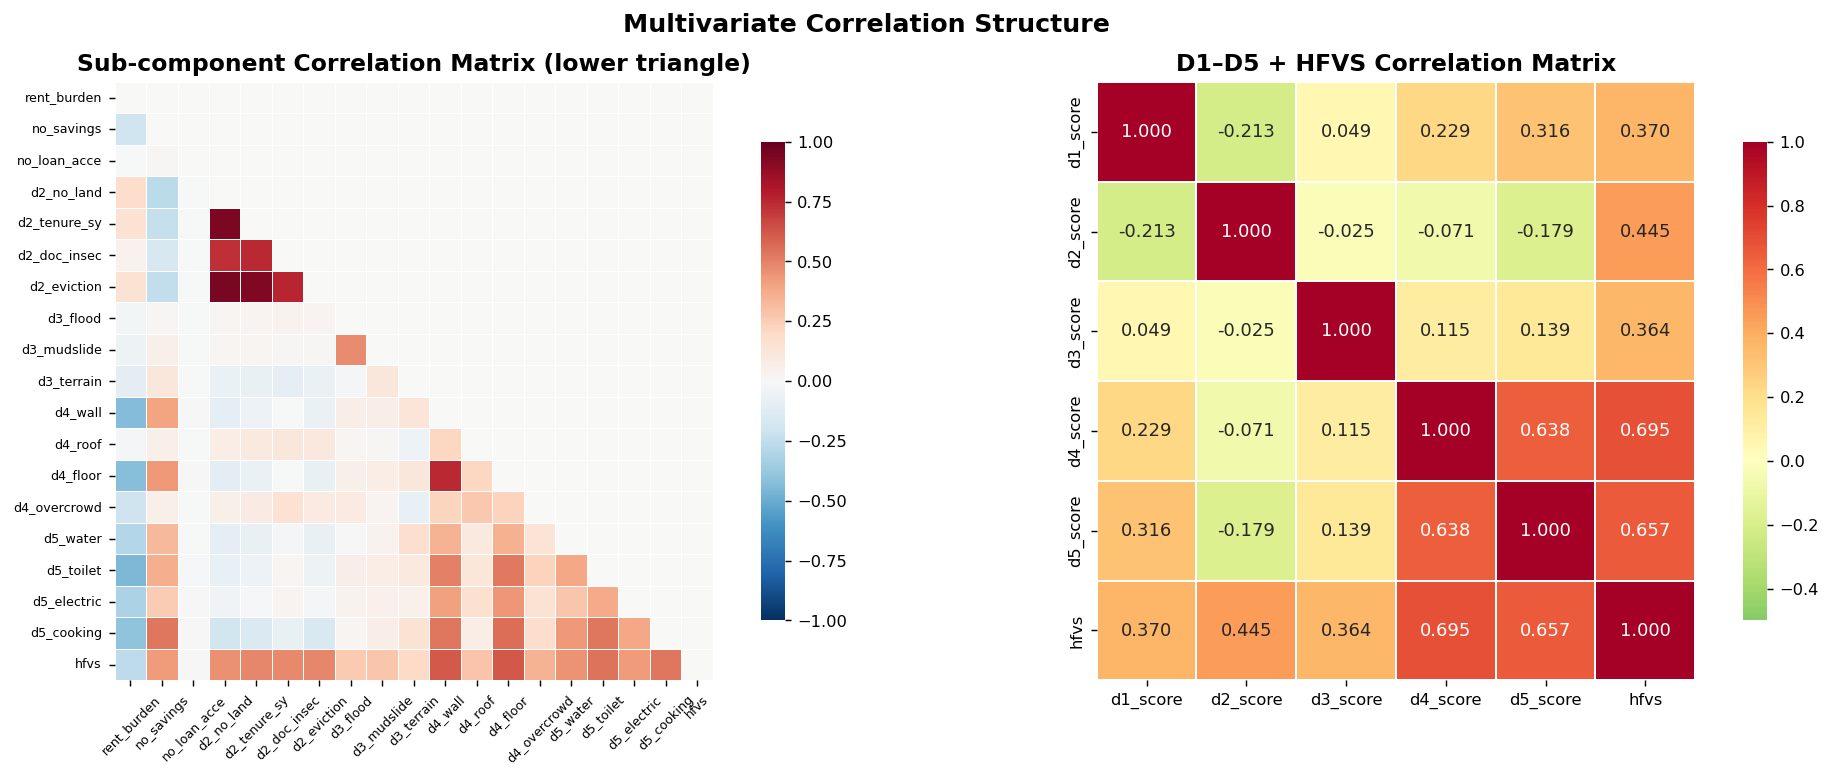

── D-Score × HFVS Correlations ──
  D1 Financial Stress      : r = 0.3701
  D2 Tenure Insecurity     : r = 0.4451
  D3 Physical Hazard       : r = 0.3644
  D4 Dwelling Quality      : r = 0.6946
  D5 Utility Deprivation   : r = 0.6569


In [46]:

# 11A: Dimension-dimension correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: full correlation heatmap of dimension sub-components ─────────────────
sub_components = [
    'rent_burden','no_savings','no_loan_access',
    'd2_no_land','d2_tenure_sys','d2_doc_insecurity','d2_eviction',
    'd3_flood','d3_mudslide','d3_terrain',
    'd4_wall','d4_roof','d4_floor','d4_overcrowd',
    'd5_water','d5_toilet','d5_electric','d5_cooking',
    'hfvs'
]
sub_present = [c for c in sub_components if c in df.columns]
corr_sub = df[sub_present].corr()

mask = np.triu(np.ones_like(corr_sub, dtype=bool))
sns.heatmap(corr_sub, ax=axes[0], mask=mask, annot=False, cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            xticklabels=[c[:12] for c in sub_present],
            yticklabels=[c[:12] for c in sub_present],
            linewidths=0.3, cbar_kws={'shrink': 0.8})
axes[0].set_title("Sub-component Correlation Matrix (lower triangle)")
axes[0].tick_params(axis='x', rotation=45, labelsize=7)
axes[0].tick_params(axis='y', labelsize=7)

# ── Right: D-score pairplot summary (correlation scatter matrix simplified) ───
d_corr = df[d_cols + ['hfvs']].corr()
sns.heatmap(d_corr, ax=axes[1], annot=True, fmt='.3f', cmap='RdYlGn_r',
            center=0, vmin=-0.5, vmax=1, linewidths=1, linecolor='white',
            square=True, cbar_kws={'shrink': 0.8})
axes[1].set_title("D1–D5 + HFVS Correlation Matrix")

plt.suptitle("Multivariate Correlation Structure", fontsize=14, fontweight='700')
plt.tight_layout()
plt.savefig(FIGS / 'eda11a_correlation_matrix.png', dpi=130, bbox_inches='tight')
plt.show()

# Print key correlations numerically
print("── D-Score × HFVS Correlations ──")
for col in d_cols:
    r = df[col].corr(df['hfvs'])
    print(f"  {d_labels[col]:<25}: r = {r:.4f}")


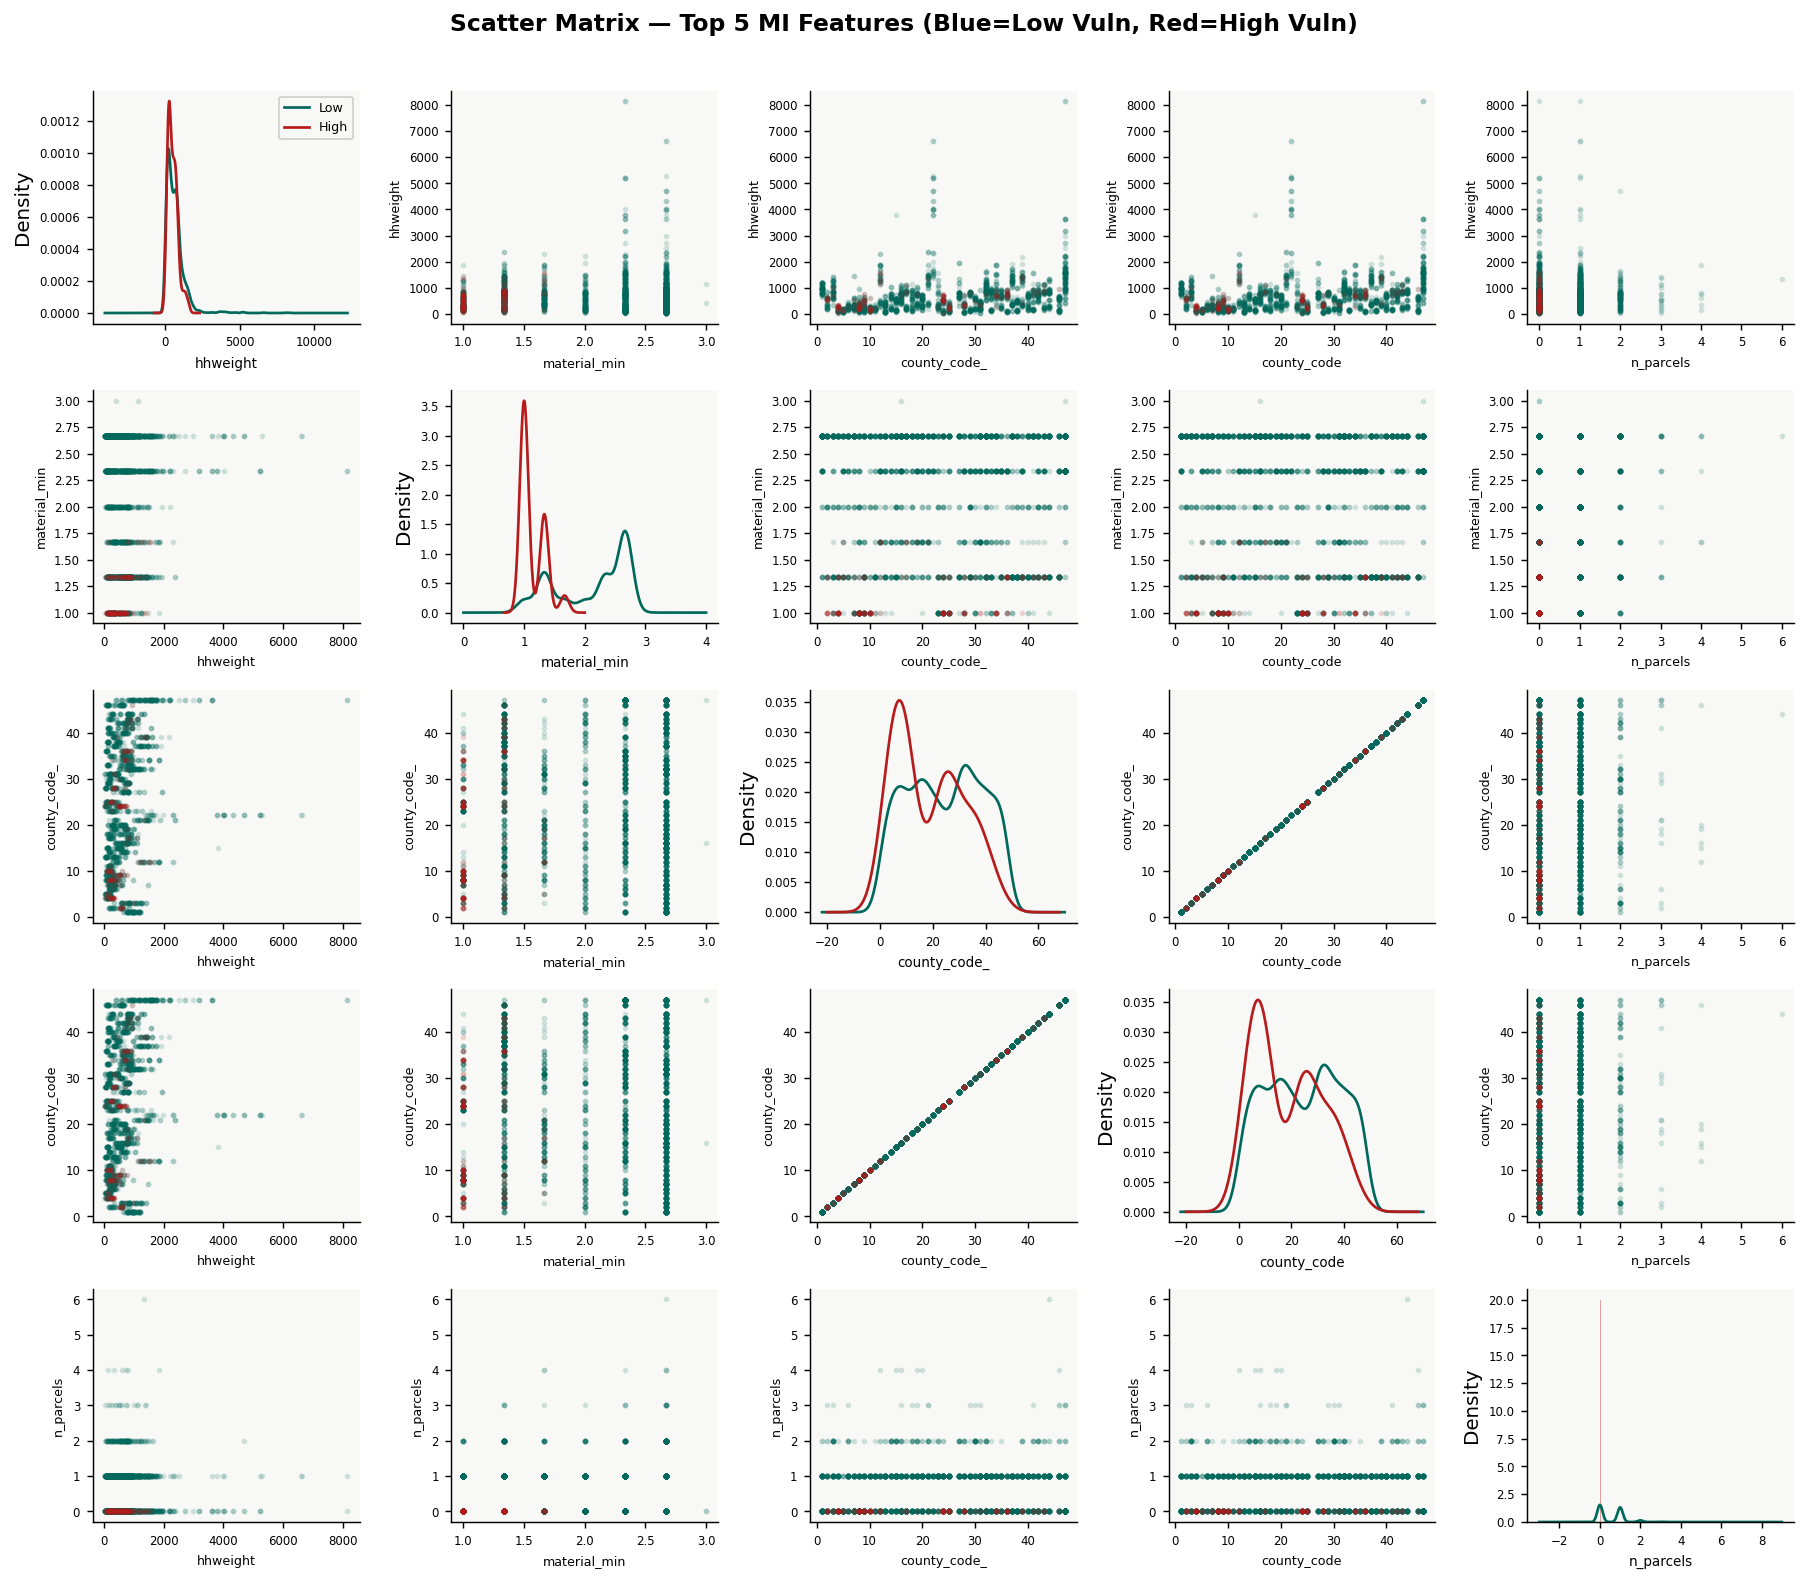

In [47]:
# 11B: Scatter matrix of top 5 MI features + hfvs
top5_mi = mi_series.head(5).index.tolist()
scatter_cols = top5_mi + ['hfvs']
scatter_df = df[scatter_cols].dropna().sample(min(3000, len(df)), random_state=42)

# Map hfvs_binary for colour
scatter_df['_class'] = (scatter_df['hfvs'] >= 0.60).astype(int)

def safe_kde(series, ax, color, lw, label):
    """Plot KDE, fall back to normed histogram if KDE fails (zero/near-zero variance)."""
    try:
        series.plot.kde(ax=ax, color=color, lw=lw, label=label)
    except Exception:
        ax.hist(series, bins=20, density=True, color=color, alpha=0.4,
                label=label, edgecolor='none')

fig = plt.figure(figsize=(14, 12))
n = len(top5_mi)
for i, ci in enumerate(top5_mi):
    for j, cj in enumerate(top5_mi):
        ax = fig.add_subplot(n, n, i*n + j + 1)
        if i == j:
            safe_kde(scatter_df[scatter_df['_class']==0][ci], ax, TEAL, 1.5, 'Low')
            safe_kde(scatter_df[scatter_df['_class']==1][ci], ax, RED,  1.5, 'High')
            ax.set_xlabel(ci[:12], fontsize=7.5)
            if i == 0: ax.legend(fontsize=7)
        else:
            lo = scatter_df[scatter_df['_class']==0]
            hi = scatter_df[scatter_df['_class']==1]
            ax.scatter(lo[cj], lo[ci], alpha=0.12, s=5, color=TEAL)
            ax.scatter(hi[cj], hi[ci], alpha=0.12, s=5, color=RED)
            ax.set_xlabel(cj[:12], fontsize=7)
            ax.set_ylabel(ci[:12], fontsize=7)
        ax.tick_params(labelsize=6.5)

plt.suptitle("Scatter Matrix — Top 5 MI Features (Blue=Low Vuln, Red=High Vuln)",
             fontsize=13, fontweight='700', y=1.01)
plt.tight_layout()
plt.savefig(FIGS / 'eda11b_scatter_matrix.png', dpi=130, bbox_inches='tight')
plt.show()

In [48]:

# Assess distribution shape for all numeric features
skew_kurt = []
for col in candidates:
    s = df[col].dropna()
    if len(s) < 50:
        continue
    skewness = s.skew()
    kurtosis = s.kurtosis()
    iqr = s.quantile(0.75) - s.quantile(0.25)
    n_outliers = ((s < s.quantile(0.25) - 1.5*iqr) | (s > s.quantile(0.75) + 1.5*iqr)).sum()
    skew_kurt.append({
        'col': col, 'skewness': skewness, 'kurtosis': kurtosis,
        'n_outliers': n_outliers, 'pct_outliers': n_outliers/len(s)*100
    })

skew_df = pd.DataFrame(skew_kurt).set_index('col')

print("=" * 65)
print("DISTRIBUTION SHAPE AUDIT — ALL NUMERIC FEATURES")
print("=" * 65)
print(f"  High-skew features (|skew| > 2) : {(skew_df['skewness'].abs() > 2).sum()}")
print(f"  High-skew features (|skew| > 5) : {(skew_df['skewness'].abs() > 5).sum()}")
print(f"  High-kurtosis (> 10)            : {(skew_df['kurtosis'] > 10).sum()}")

print("\n── Top 20 most skewed features ──")
top_skew = skew_df.reindex(skew_df['skewness'].abs().sort_values(ascending=False).index).head(20)
print(f"  {'Feature':<25} {'Skewness':>10} {'Kurtosis':>10} {'% Outliers':>12}")
print("  " + "─" * 60)
for col, row in top_skew.iterrows():
    print(f"  {col:<25} {row['skewness']:>10.2f} {row['kurtosis']:>10.2f} {row['pct_outliers']:>11.1f}%")


DISTRIBUTION SHAPE AUDIT — ALL NUMERIC FEATURES
  High-skew features (|skew| > 2) : 142
  High-skew features (|skew| > 5) : 84
  High-kurtosis (> 10)            : 115

── Top 20 most skewed features ──
  Feature                     Skewness   Kurtosis   % Outliers
  ────────────────────────────────────────────────────────────
  e02__96                       142.69   20360.00         0.0%
  g02_1                         134.99   19157.89        11.8%
  e05                           134.87   19036.21        16.2%
  c14_2                         121.95   16501.29        14.0%
  c12_1_1                       114.68   13965.04         4.5%
  l20_c                         113.80   13014.02         3.2%
  l20_a                         113.21   12922.54         7.0%
  l20_b                         112.94   12878.93         1.7%
  l15                            69.06    5392.55        12.3%
  c11_3                          57.90    4912.81         5.5%
  c14_3                          55.71    

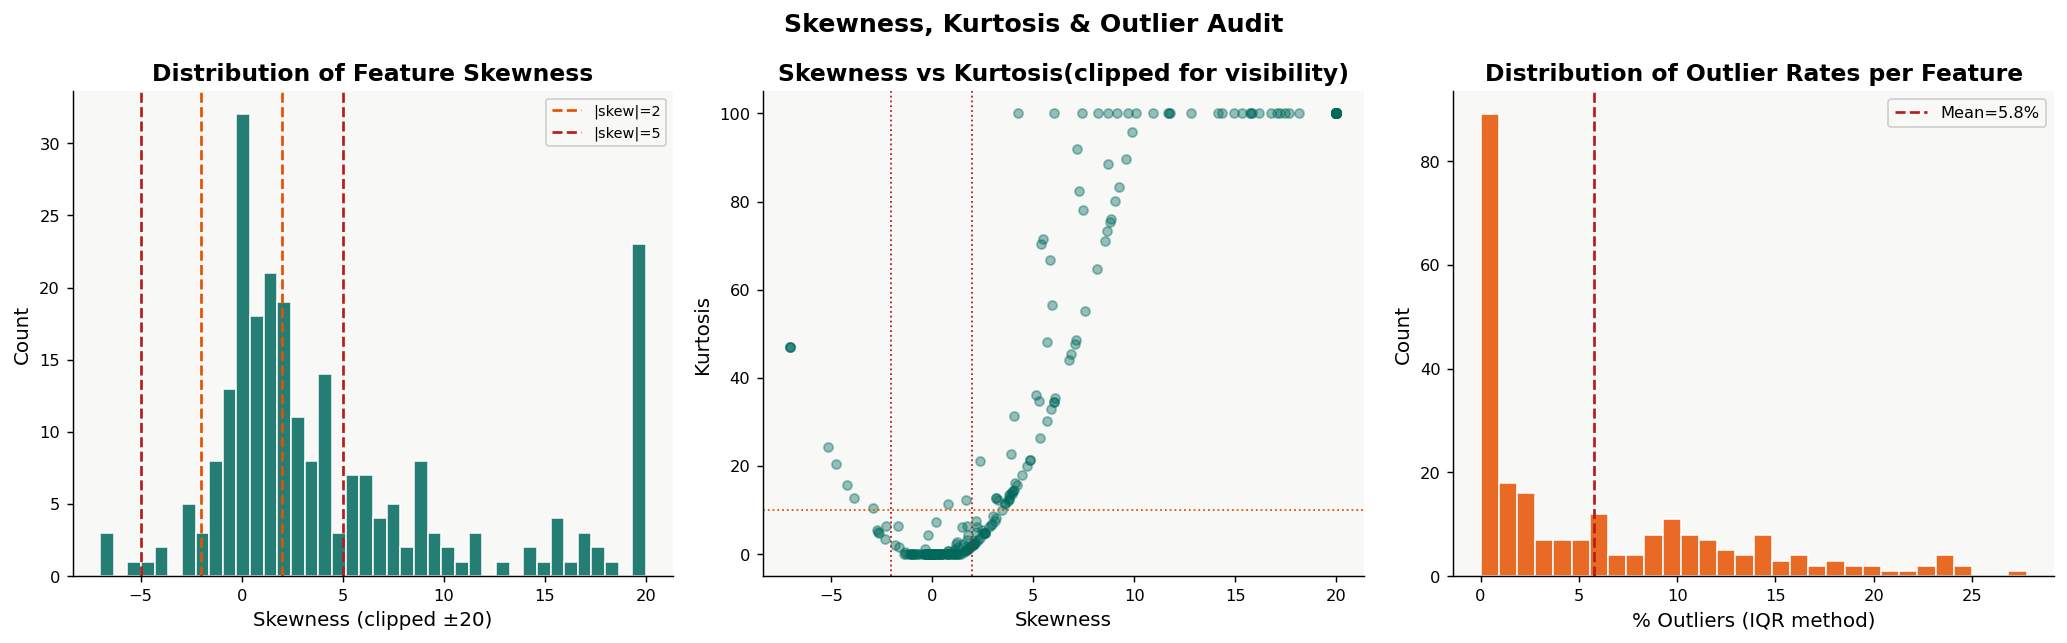


── Features needing log transform (|skew| > 2 & right-skewed) ──
  c01_1                      skew=9.14  → recommend log1p transform
  c01_2                      skew=14.32  → recommend log1p transform
  c01_4                      skew=5.38  → recommend log1p transform
  c01_5                      skew=3.81  → recommend log1p transform
  c02_1                      skew=8.73  → recommend log1p transform
  c02_2                      skew=16.18  → recommend log1p transform
  c02_4                      skew=3.91  → recommend log1p transform
  c02_5                      skew=3.94  → recommend log1p transform
  c03                        skew=6.78  → recommend log1p transform
  c04                        skew=11.75  → recommend log1p transform
  c07                        skew=28.97  → recommend log1p transform
  c10                        skew=15.75  → recommend log1p transform
  c10_2                      skew=2.11  → recommend log1p transform
  c10_4                      skew=16.75  → re

In [49]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Left: skewness distribution ───────────────────────────────────────────────
skews = skew_df['skewness']
axes[0].hist(skews.clip(-20, 20), bins=40, color=TEAL, edgecolor='white', alpha=0.85)
axes[0].axvline(2,  color=AMBER, linestyle='--', lw=1.5, label='|skew|=2')
axes[0].axvline(-2, color=AMBER, linestyle='--', lw=1.5)
axes[0].axvline(5,  color=RED,   linestyle='--', lw=1.5, label='|skew|=5')
axes[0].axvline(-5, color=RED,   linestyle='--', lw=1.5)
axes[0].set_xlabel("Skewness (clipped ±20)"); axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Feature Skewness")
axes[0].legend(fontsize=8)

# ── Centre: skewness vs kurtosis scatter ──────────────────────────────────────
axes[1].scatter(skews.clip(-20,20), skew_df['kurtosis'].clip(0,100),
                alpha=0.4, color=TEAL, s=25)
axes[1].axvline(2, color=RED, linestyle=':', lw=1)
axes[1].axvline(-2, color=RED, linestyle=':', lw=1)
axes[1].axhline(10, color=AMBER, linestyle=':', lw=1)
axes[1].set_xlabel("Skewness"); axes[1].set_ylabel("Kurtosis")
axes[1].set_title("Skewness vs Kurtosis(clipped for visibility)")

# ── Right: outlier rates histogram ────────────────────────────────────────────
axes[2].hist(skew_df['pct_outliers'], bins=30, color=AMBER, edgecolor='white', alpha=0.85)
axes[2].set_xlabel("% Outliers (IQR method)"); axes[2].set_ylabel("Count")
axes[2].set_title("Distribution of Outlier Rates per Feature")
axes[2].axvline(skew_df['pct_outliers'].mean(), color=RED, linestyle='--',
                lw=1.5, label=f"Mean={skew_df['pct_outliers'].mean():.1f}%")
axes[2].legend()

plt.suptitle("Skewness, Kurtosis & Outlier Audit", fontsize=14, fontweight='700')
plt.tight_layout()
plt.savefig(FIGS / 'eda12_skewness.png', dpi=130, bbox_inches='tight')
plt.show()

print("\n── Features needing log transform (|skew| > 2 & right-skewed) ──")
needs_log = skew_df[(skew_df['skewness'] > 2) & (skew_df['skewness'] < 100)]
for col, row in needs_log.head(15).iterrows():
    print(f"  {col:<25}  skew={row['skewness']:.2f}  → recommend log1p transform")


In [50]:

print("=" * 70)
print("EDA SYNTHESIS — DATA-DRIVEN DECISIONS FOR MODELLING")
print("=" * 70)

print("""
╔══════════════════════════════════════════════════════════════════╗
║  A. WHAT TO DROP                                                 ║
╚══════════════════════════════════════════════════════════════════╝
  1. FORMULA ANCESTORS: d1_score, d2_score, d3_score, d4_score, d5_score,
     rent_burden, no_savings, no_loan_access, d2_no_land, d2_tenure_sys,
     d2_doc_insecurity, d2_eviction, d3_flood, d3_mudslide, d3_terrain,
     d4_wall, d4_roof, d4_floor, d4_overcrowd, d5_water, d5_toilet,
     d5_electric, d5_cooking, effective_rent, total_exp_proxy
     Reason: directly used to construct hfvs → data leakage

  2. EXTREME MISSINGNESS (>50%): these columns will impute poorly
     and add noise. Drop any column missing >50% of values.

  3. NEAR-ZERO VARIANCE: columns with < 2 unique values carry no info.

  4. COUNTY-LEVEL DUPLICATES: county_code duplicate cols after merge.

╔══════════════════════════════════════════════════════════════════╗
║  B. WHAT TO FEATURE ENGINEER                                     ║
╚══════════════════════════════════════════════════════════════════╝
  1. LOG TRANSFORMS: total_exp_proxy, effective_rent, n_parcels
     (highly right-skewed — log1p stabilises)

  2. INTERACTION TERMS:
     - i00 (land_owner) × hh_size  → stress on non-owners with large families
     - residence (urban/rural) × c01_1 (water source)
     - a01 (county) mean HFVS as geo feature

  3. BINARY FLAGS:
     - 'no_piped_water'  (c01_1 ∉ {1,2})
     - 'open_defecation' (c04 ∈ {8,11,12,13})
     - 'no_electricity'  (c10 ∈ {9,10,12})
     - 'solid_fuel'      (c11 ∈ {9,10,11,12,13})
     - 'overcrowded'     (persons_per_room >= 3)

  4. COUNTY FEATURES:
     - county mean HFVS (leave-one-out to avoid leakage)
     - county-level water hours, mortgage demand

╔══════════════════════════════════════════════════════════════════╗
║  C. MODEL TYPE RECOMMENDATION                                    ║
╚══════════════════════════════════════════════════════════════════╝
  TASK TYPE: Binary Classification (hfvs_binary) + Regression (hfvs)

  PRIMARY RECOMMENDATION: Gradient Boosted Trees
  ─────────────────────────────────────────────
  ✓ XGBoost / LightGBM — Reasons:
    • Many categorical/ordinal codes — trees handle natively
    • Highly skewed features — trees are invariant to monotonic transforms
    • Detected non-linear relationships (high MI, lower Pearson)
    • Moderate imbalance (ratio ~2:1) — easily handled with scale_pos_weight
    • Missing values — LightGBM has native missing value handling
    • 500+ features — built-in feature selection via importance
    • Known to excel on tabular survey data

  SECONDARY RECOMMENDATION: Logistic Regression (regularised)
  ─────────────────────────────────────────────────────────────
  ✓ With log-transformed skewed features + one-hot encoded categoricals
  ✓ Provides interpretable coefficients (policy-facing dissertation)
  ✓ Baseline comparator

  TERTIARY: TabNet / Neural Network
  ──────────────────────────────────
  ✓ Already imported — use for ensemble or sensitivity check

  AVOID: Linear regression on raw features (too many violated assumptions)

  CLASS IMBALANCE STRATEGY:
  ─────────────────────────
  Ratio ~2:1 — mild imbalance. Prefer:
  • scale_pos_weight (XGBoost) or class_weight='balanced'
  • Evaluation metric: ROC-AUC, PR-AUC (not raw accuracy)
  • Use StratifiedKFold (5-fold, already defined as N_FOLDS=5)

  VALIDATION APPROACH:
  ────────────────────
  • Primary CV: StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
  • Group consideration: households within same county → potential leakage
    Consider StratifiedGroupKFold with a01 (county) as group if overfitting
    is observed in regional models.
""")


EDA SYNTHESIS — DATA-DRIVEN DECISIONS FOR MODELLING

╔══════════════════════════════════════════════════════════════════╗
║  A. WHAT TO DROP                                                 ║
╚══════════════════════════════════════════════════════════════════╝
  1. FORMULA ANCESTORS: d1_score, d2_score, d3_score, d4_score, d5_score,
     rent_burden, no_savings, no_loan_access, d2_no_land, d2_tenure_sys,
     d2_doc_insecurity, d2_eviction, d3_flood, d3_mudslide, d3_terrain,
     d4_wall, d4_roof, d4_floor, d4_overcrowd, d5_water, d5_toilet,
     d5_electric, d5_cooking, effective_rent, total_exp_proxy
     Reason: directly used to construct hfvs → data leakage

  2. EXTREME MISSINGNESS (>50%): these columns will impute poorly
     and add noise. Drop any column missing >50% of values.

  3. NEAR-ZERO VARIANCE: columns with < 2 unique values carry no info.

  4. COUNTY-LEVEL DUPLICATES: county_code duplicate cols after merge.

╔═══════════════════════════════════════════════════════════

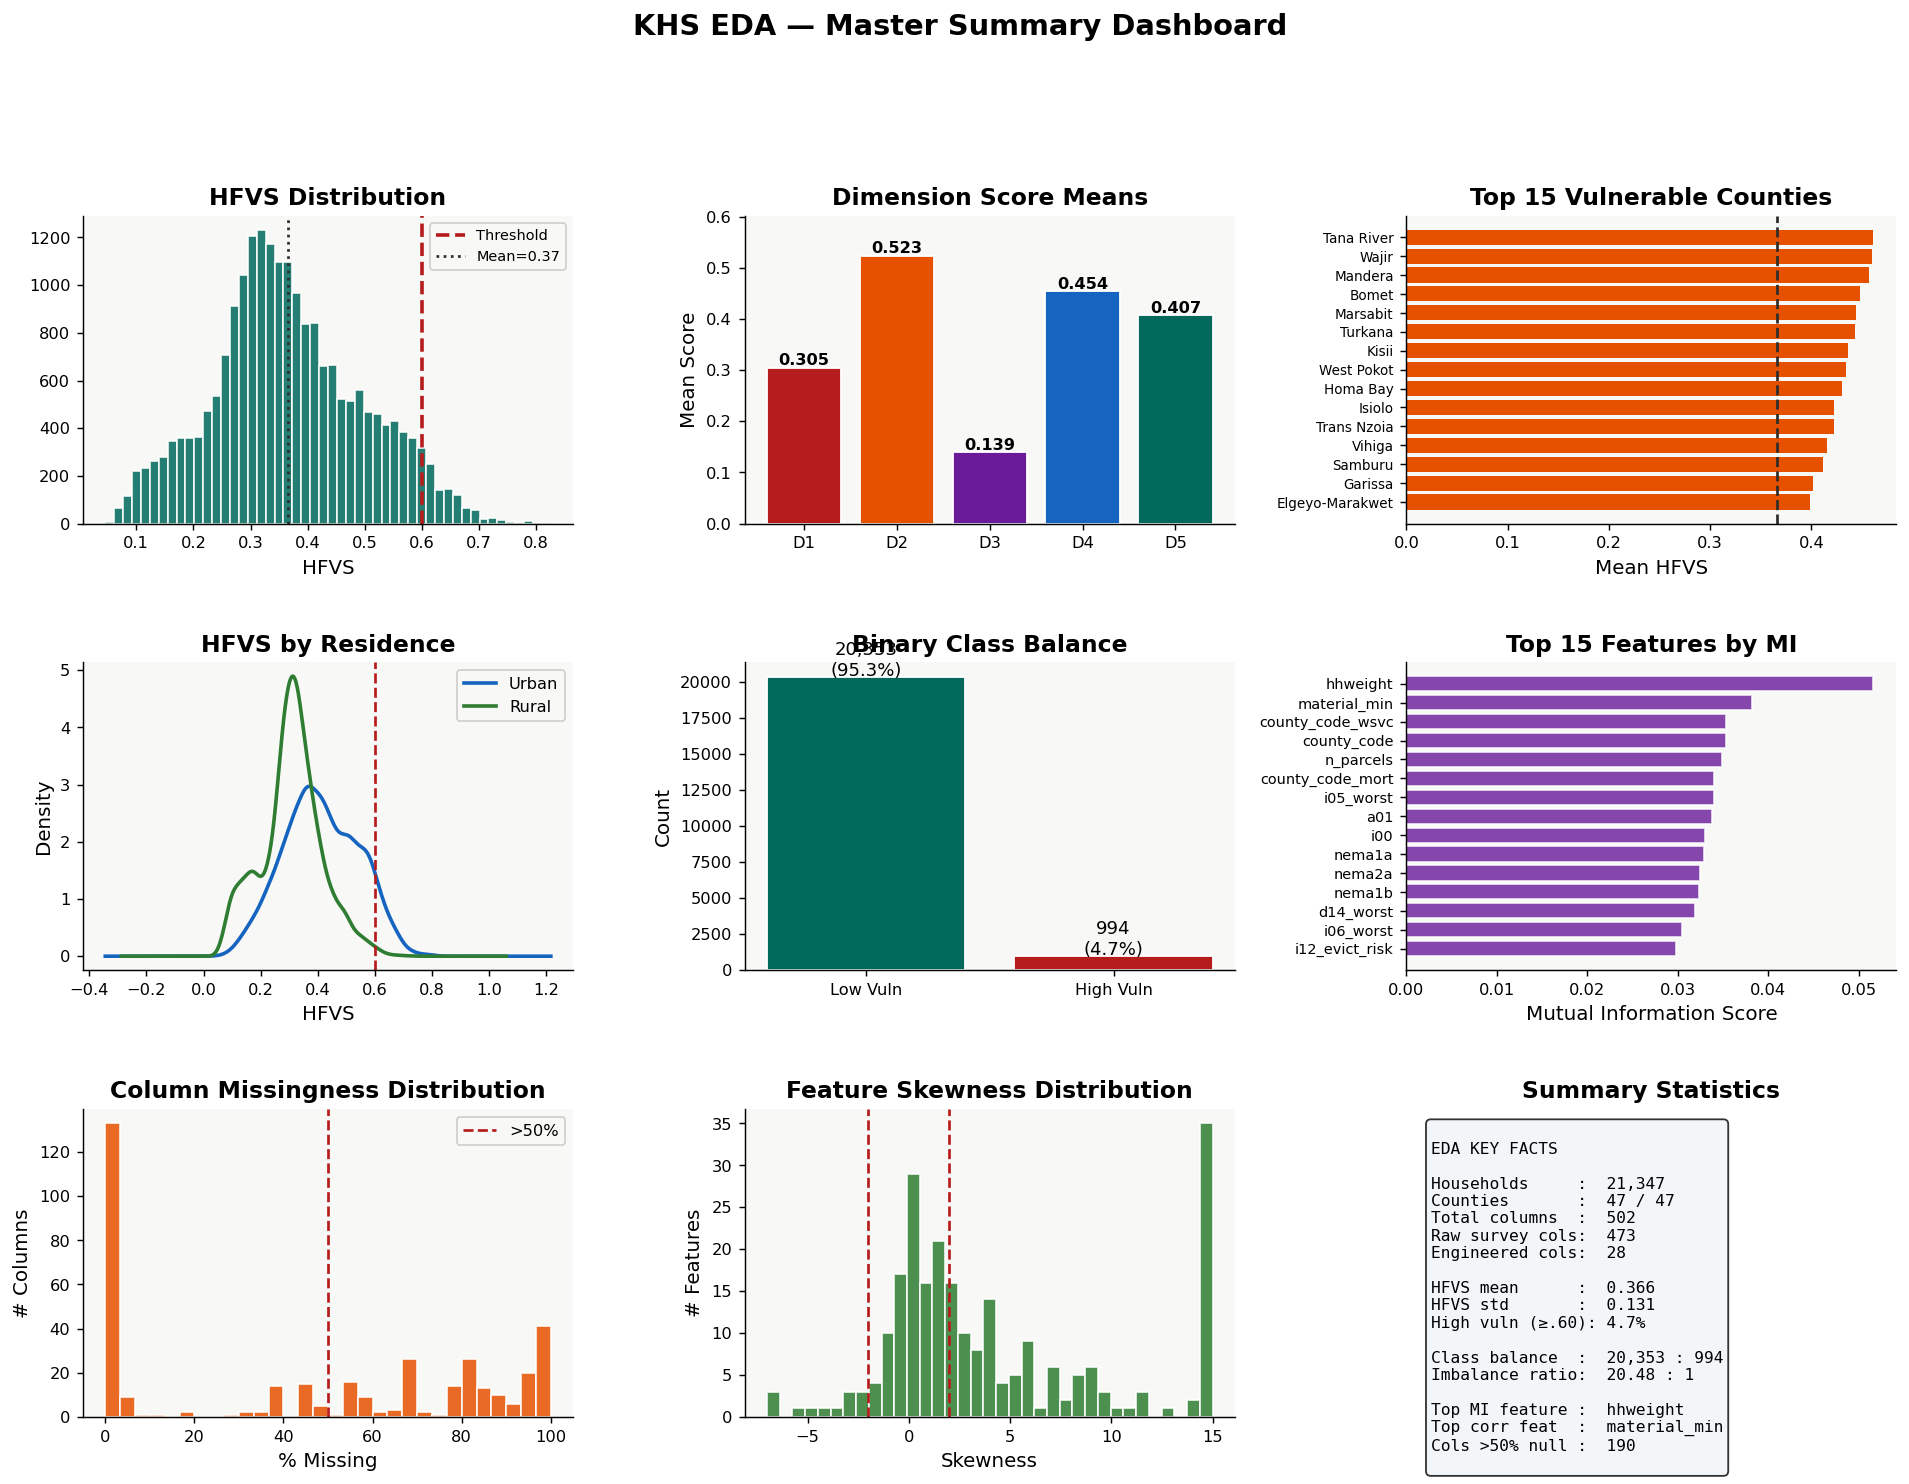


✅ Full EDA complete. All figures saved to FIGS directory.


In [51]:

fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1: HFVS histogram
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df['hfvs'], bins=50, color=TEAL, edgecolor='white', alpha=0.85)
ax1.axvline(0.60, color=RED, lw=2, linestyle='--', label='Threshold')
ax1.axvline(df['hfvs'].mean(), color=DARK, lw=1.5, linestyle=':', label=f"Mean={df['hfvs'].mean():.2f}")
ax1.set_title("HFVS Distribution"); ax1.set_xlabel("HFVS"); ax1.legend(fontsize=8)

# 2: D-score means bar
ax2 = fig.add_subplot(gs[0, 1])
d_means = [df[c].mean() for c in d_cols]
ax2.bar(['D1','D2','D3','D4','D5'], d_means, color=d_colors, edgecolor='white')
for i, v in enumerate(d_means):
    ax2.text(i, v+0.005, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
ax2.set_ylabel("Mean Score"); ax2.set_title("Dimension Score Means")
ax2.set_ylim(0, max(d_means)*1.15)

# 3: County vulnerability (top 15)
ax3 = fig.add_subplot(gs[0, 2])
top15 = county_agg.head(15)
colors_c = [RED if v >= 0.60 else AMBER for v in top15['hfvs_mean']]
ax3.barh(range(15), top15['hfvs_mean'].values[::-1], color=colors_c[::-1])
ax3.set_yticks(range(15))
ax3.set_yticklabels(top15['county_name'].values[::-1], fontsize=7.5)
ax3.axvline(df['hfvs'].mean(), color=DARK, linestyle='--', lw=1.5)
ax3.set_title("Top 15 Vulnerable Counties")
ax3.set_xlabel("Mean HFVS")

# 4: Urban vs rural HFVS kde
ax4 = fig.add_subplot(gs[1, 0])
for res, color in zip(['Urban','Rural'], [BLUE, GREEN]):
    df[df['residence']==res]['hfvs'].plot.kde(ax=ax4, label=res, color=color, lw=2)
ax4.axvline(0.60, color=RED, linestyle='--', lw=1.5)
ax4.set_title("HFVS by Residence"); ax4.legend(fontsize=9)
ax4.set_xlabel("HFVS")

# 5: Binary class
ax5 = fig.add_subplot(gs[1, 1])
vc = df['hfvs_binary'].value_counts()
bars = ax5.bar(['Low Vuln', 'High Vuln'], [vc[0], vc[1]], color=[TEAL, RED], edgecolor='white')
for bar, v in zip(bars, [vc[0], vc[1]]):
    ax5.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
             f'{v:,}\n({v/sum(vc.values)*100:.1f}%)', ha='center', fontsize=10)
ax5.set_title("Binary Class Balance"); ax5.set_ylabel("Count")

# 6: Top 15 MI features
ax6 = fig.add_subplot(gs[1, 2])
top15mi = mi_series.head(15)
ax6.barh(range(15), top15mi.values[::-1], color=PURPLE, edgecolor='white', alpha=0.8)
ax6.set_yticks(range(15))
ax6.set_yticklabels(top15mi.index[::-1], fontsize=8)
ax6.set_xlabel("Mutual Information Score")
ax6.set_title("Top 15 Features by MI")

# 7: Missingness summary
ax7 = fig.add_subplot(gs[2, 0])
miss_all2 = df.isnull().mean() * 100
ax7.hist(miss_all2[miss_all2 > 0], bins=30, color=AMBER, edgecolor='white', alpha=0.85)
ax7.set_xlabel("% Missing"); ax7.set_ylabel("# Columns")
ax7.set_title("Column Missingness Distribution")
ax7.axvline(50, color=RED, lw=1.5, linestyle='--', label='>50%')
ax7.legend()

# 8: Skewness distribution
ax8 = fig.add_subplot(gs[2, 1])
ax8.hist(skew_df['skewness'].clip(-15, 15), bins=35, color=GREEN, edgecolor='white', alpha=0.85)
ax8.axvline(2, color=RED, lw=1.5, linestyle='--')
ax8.axvline(-2, color=RED, lw=1.5, linestyle='--')
ax8.set_xlabel("Skewness"); ax8.set_ylabel("# Features")
ax8.set_title("Feature Skewness Distribution")

# 9: Key stats text box
ax9 = fig.add_subplot(gs[2, 2])
ax9.axis('off')
stats_text = f"""
EDA KEY FACTS

Households     :  {len(df):,}
Counties       :  {df['a01'].nunique()} / 47
Total columns  :  {df.shape[1]:,}
Raw survey cols:  {len(raw_cols):,}
Engineered cols:  {len(engineered_cols):,}

HFVS mean      :  {df['hfvs'].mean():.3f}
HFVS std       :  {df['hfvs'].std():.3f}
High vuln (≥.60): {(df['hfvs']>=0.60).mean()*100:.1f}%

Class balance  :  {df['hfvs_binary'].value_counts()[0]:,} : {df['hfvs_binary'].value_counts()[1]:,}
Imbalance ratio:  {df['hfvs_binary'].value_counts()[0]/df['hfvs_binary'].value_counts()[1]:.2f} : 1

Top MI feature :  {mi_series.index[0]}
Top corr feat  :  {p_series.index[0]}
Cols >50% null :  {(df.isnull().mean() > 0.5).sum():,}
"""
ax9.text(0.05, 0.95, stats_text, transform=ax9.transAxes, fontsize=9,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#F0F4F8', alpha=0.8))
ax9.set_title("Summary Statistics")

plt.suptitle("KHS EDA — Master Summary Dashboard", fontsize=16, fontweight='700', y=1.01)
plt.savefig(FIGS / 'eda14_summary_dashboard.png', dpi=140, bbox_inches='tight')
plt.show()
print("\n✅ Full EDA complete. All figures saved to FIGS directory.")


# ***Data Cleaning → Feature Engineering → Modelling Prep***

In [73]:
# CELL 1 — Imports & Paths

df_raw = pd.read_parquet(MODS / 'master_hfvs_v4.parquet')
print(f"✓ Loaded master_hfvs_v4  →  {df_raw.shape[0]:,} rows × {df_raw.shape[1]:,} cols")



✓ Loaded master_hfvs_v4  →  21,347 rows × 499 cols


In [74]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Define Drop Lists
# Three categories of columns to remove before any modelling.
# ─────────────────────────────────────────────────────────────────────────────

# 2A: FORMULA ANCESTORS — columns directly used to construct hfvs / dimension
#     scores. Using them as features = perfect data leakage.
FORMULA_ANCESTORS = [
    # Dimension sub-scores (computed, not surveyed)
    'd1_score', 'd2_score', 'd3_score', 'd4_score', 'd5_score',
    # D1 Financial Stress components
    'rent_burden', 'no_savings', 'no_loan_access',
    'effective_rent', 'total_exp_proxy',
    # D2 Tenure Insecurity components
    'd2_no_land', 'd2_no_agreement', 'd2_tenure_sys',
    'd2_doc_insecurity', 'd2_eviction',
    # D3 Physical Hazard components
    'd3_flood', 'd3_mudslide', 'd3_terrain',
    # D4 Dwelling Quality components
    'd4_wall', 'd4_roof', 'd4_floor', 'd4_overcrowd',
    # D5 Utility Deprivation components
    'd5_water', 'd5_toilet', 'd5_electric', 'd5_cooking',
]

# 2B: SURVEY WEIGHT — must NOT be a feature; used as sample_weight in training
#     hhweight reflects survey design (probability of selection), not household
#     characteristics. Including it as a feature would let the model learn
#     sampling probabilities rather than vulnerability patterns.
WEIGHT_COL = 'hhweight'

# 2C: HIGH MISSINGNESS — columns >80% missing cannot be imputed meaningfully.
#     116 such columns identified in EDA. We compute this dynamically so the
#     threshold is reproducible.
MISS_THRESHOLD = 0.80
miss_rates = df_raw.isnull().mean()
HIGH_MISS_COLS = miss_rates[miss_rates > MISS_THRESHOLD].index.tolist()

# 2D: NEAR-ZERO VARIANCE — columns with only 1 unique non-null value carry
#     zero information. Drop them entirely.
nzv_cols = []
for col in df_raw.columns:
    if df_raw[col].nunique(dropna=True) <= 1:
        nzv_cols.append(col)
NZV_COLS = nzv_cols

# 2E: DUPLICATE COUNTY KEYS — artefacts from the left-join in Step 13.
#     county_code appears under different suffixes after merging WSVC and MORT.
DUPE_KEYS = [c for c in df_raw.columns if c in
             ('county_code_wsvc', 'county_code_mort', 'county_code_nema',
              'county_code', '_res_label')]

print("\nDrop list summary:")
print(f"  Formula ancestors  : {len(FORMULA_ANCESTORS)}")
print(f"  Weight column      : {WEIGHT_COL}")
print(f"  >80% missing       : {len(HIGH_MISS_COLS)}")
print(f"  Near-zero variance : {len(NZV_COLS)}")
print(f"  Duplicate keys     : {len(DUPE_KEYS)}")
total_drop = len(set(FORMULA_ANCESTORS + HIGH_MISS_COLS + NZV_COLS + DUPE_KEYS))
print(f"  ── TOTAL unique drops : {total_drop}")
print(f"  Columns remaining     : {df_raw.shape[1] - total_drop}")




Drop list summary:
  Formula ancestors  : 26
  Weight column      : hhweight
  >80% missing       : 116
  Near-zero variance : 6
  Duplicate keys     : 3
  ── TOTAL unique drops : 148
  Columns remaining     : 351


In [75]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Apply Drops & Preserve Weight Vector
# ─────────────────────────────────────────────────────────────────────────────

# Preserve sample weight before dropping — used later in model training
sample_weight = df_raw[WEIGHT_COL].copy() if WEIGHT_COL in df_raw.columns else None

# Build the full drop set (union of all categories)
all_drops = set(FORMULA_ANCESTORS + HIGH_MISS_COLS + NZV_COLS + DUPE_KEYS)
# Never accidentally drop the target or the household key
#KEEP_ALWAYS = {'hfvs', 'hfvs_binary', 'interview__key', 'a01', 'county_name'}

KEEP_ALWAYS = {'hfvs', 'interview__key', 'a01', 'county_name'}
# Remove 'hfvs_binary' and 'hfvs_50'/'hfvs_60' — they don't exist yet at Cell 3.
# They are created in Cell 4 AFTER the drops. No risk of dropping them.

all_drops -= KEEP_ALWAYS

df = df_raw.drop(columns=[c for c in all_drops if c in df_raw.columns])

print(f"✓ After cleaning drops: {df.shape[0]:,} rows × {df.shape[1]:,} cols")
print(f"  Sample weight vector preserved: {sample_weight is not None}")
print(f"  Null rows still present (expected — will impute later): "
      f"{df.isnull().any(axis=1).sum():,}")


✓ After cleaning drops: 21,347 rows × 351 cols
  Sample weight vector preserved: True
  Null rows still present (expected — will impute later): 21,347


In [76]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Target Variable Decision: 0.50 vs 0.60 Threshold
#
# EDA revealed: threshold=0.60 → 994 positives (4.7%) → 20.48:1 imbalance.
# This is severe. We evaluate both thresholds before committing.
# ─────────────────────────────────────────────────────────────────────────────

# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Target Variable Decision: 0.50 vs 0.60 Threshold
# ─────────────────────────────────────────────────────────────────────────────

thresholds = {
    0.50: 'hfvs_50',
    0.60: 'hfvs_60',
}
for t, col in thresholds.items():
    df[col] = (df['hfvs'] >= t).astype(int)

print("Threshold comparison:")
print(f"  {'Threshold':<12} {'Positives':>10} {'Negatives':>10} {'% Pos':>8} {'Ratio':>8}")
print("  " + "─" * 52)
for t, col in thresholds.items():
    pos = df[col].sum()
    neg = len(df) - pos
    pct = pos / len(df) * 100
    ratio = neg / pos
    print(f"  {t:<12} {pos:>10,} {neg:>10,} {pct:>7.1f}% {ratio:>7.1f}:1")

print("\n  Decision: use BOTH in parallel during modelling.")
print("  Primary metric: PR-AUC (not ROC-AUC — imbalanced classes).")
print("  hfvs_binary (=hfvs_60) remains the dissertation target.")
print("  hfvs_50 used as a sensitivity / robustness check.")

# FIX: Create hfvs_binary here if it doesn't already exist in df.
# hfvs_binary = hfvs_60 by definition (threshold=0.60).
if 'hfvs_binary' not in df.columns:
    df['hfvs_binary'] = df['hfvs_60'].copy()
    print("\n  ℹ hfvs_binary not found in parquet — created from hfvs_60.")
else:
    # Verify alignment if it does exist
    mismatch = (df['hfvs_binary'] != df['hfvs_60']).sum()
    if mismatch > 0:
        print(f"\n  ⚠ hfvs_binary has {mismatch} mismatches with hfvs_60 — overwriting.")
        df['hfvs_binary'] = df['hfvs_60'].copy()

print(f"\n  hfvs_binary check: {(df['hfvs_binary'] == df['hfvs_60']).all()} "
      f"(should be True)")

Threshold comparison:
  Threshold     Positives  Negatives    % Pos    Ratio
  ────────────────────────────────────────────────────
  0.5               3,630     17,717    17.0%     4.9:1
  0.6                 994     20,353     4.7%    20.5:1

  Decision: use BOTH in parallel during modelling.
  Primary metric: PR-AUC (not ROC-AUC — imbalanced classes).
  hfvs_binary (=hfvs_60) remains the dissertation target.
  hfvs_50 used as a sensitivity / robustness check.

  ℹ hfvs_binary not found in parquet — created from hfvs_60.

  hfvs_binary check: True (should be True)


In [77]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — Feature Engineering: Binary Flags from Survey Codes
#
# Raw survey codes are integers. We derive clean binary flags that are
# interpretable and directly motivated by the HFVS dimension definitions.
# Source codebook values confirmed during Step 7/8 of the EDA.
# ─────────────────────────────────────────────────────────────────────────────

# ── 5A: Water Access ──────────────────────────────────────────────────────────
# c01_1: Main drinking water source
# Codes 1=Piped into dwelling, 2=Piped into yard/plot → improved/safe
# All other codes (borehole unprotected, river, etc.) → unimproved
if 'c01_1' in df.columns:
    df['flag_unimproved_water'] = (~df['c01_1'].isin([1, 2])).astype(float)
    df['flag_unimproved_water'] = df['flag_unimproved_water'].where(
        df['c01_1'].notna(), np.nan)

# ── 5B: Sanitation ────────────────────────────────────────────────────────────
# c04: Toilet facility type
# Codes 8=Bush/field, 11=Hanging latrine, 12=Flying toilet, 13=No facility
# → open defecation or equivalent → highest sanitation risk
if 'c04' in df.columns:
    df['flag_open_defecation'] = df['c04'].isin([8, 11, 12, 13]).astype(float)
    df['flag_open_defecation'] = df['flag_open_defecation'].where(
        df['c04'].notna(), np.nan)

# ── 5C: Electricity ───────────────────────────────────────────────────────────
# c10: Main electricity source
# Codes 1=National grid, 2=Solar, 4=Generator, 5=Solar lantern → has power
# Codes 9=Firewood, 10=Candles, 12=None → no electricity
if 'c10' in df.columns:
    df['flag_no_electricity'] = df['c10'].isin([9, 10, 12]).astype(float)
    df['flag_no_electricity'] = df['flag_no_electricity'].where(
        df['c10'].notna(), np.nan)

# ── 5D: Cooking Fuel ──────────────────────────────────────────────────────────
# c11: Main cooking fuel
# Codes 9=Wood, 10=Charcoal, 11=Crop residue, 12=Animal dung, 13=Sawdust
# → solid fuels → indoor air pollution risk
if 'c11' in df.columns:
    df['flag_solid_fuel_cooking'] = df['c11'].isin([9, 10, 11, 12, 13]).astype(float)
    df['flag_solid_fuel_cooking'] = df['flag_solid_fuel_cooking'].where(
        df['c11'].notna(), np.nan)

# ── 5E: Overcrowding ─────────────────────────────────────────────────────────
# persons_per_room: computed during dwelling aggregation
# International standard: >2 persons/room = overcrowded
# >3 = severely overcrowded
if 'persons_per_room' in df.columns:
    df['flag_overcrowded']        = (df['persons_per_room'] >= 2).astype(float)
    df['flag_severely_overcrowded'] = (df['persons_per_room'] >= 3).astype(float)
    for col in ['flag_overcrowded', 'flag_severely_overcrowded']:
        df[col] = df[col].where(df['persons_per_room'].notna(), np.nan)

# ── 5F: Land Tenure ───────────────────────────────────────────────────────────
# i00: Land ownership (0=non-owner, 1=owner)
# i05_worst: Worst tenure system (4=customary/informal = highest risk)
# i12_evict_risk: Eviction risk (5=highest, 1=lowest)
if 'i00' in df.columns:
    df['flag_non_owner'] = (df['i00'] == 0).astype(float)

if 'i05_worst' in df.columns:
    df['flag_informal_tenure'] = (
        pd.to_numeric(df['i05_worst'], errors='coerce') >= 3
    ).astype(float)

if 'i12_evict_risk' in df.columns:
    df['flag_high_eviction_risk'] = (
        pd.to_numeric(df['i12_evict_risk'], errors='coerce') >= 4
    ).astype(float)

# ── 5G: Structural Quality ────────────────────────────────────────────────────
# material_min: composite material quality score (from EDA: strongest correlate)
# floor_score_min, wall_score_min: component scores
# Score 1=permanent/good, 3=temporary/poor
if 'wall_score_min' in df.columns:
    df['flag_poor_walls'] = (
        pd.to_numeric(df['wall_score_min'], errors='coerce') <= 1
    ).astype(float)

if 'floor_score_min' in df.columns:
    df['flag_poor_floor'] = (
        pd.to_numeric(df['floor_score_min'], errors='coerce') <= 1
    ).astype(float)

# Collect all new binary flags
binary_flags = [c for c in df.columns if c.startswith('flag_')]

print("── Binary flags engineered ──")
print(f"  {'Flag':<30} {'Mean (% affected)':>20} {'% Null':>8}")
print("  " + "─" * 62)
for flag in binary_flags:
    mean_val = df[flag].mean() * 100
    null_pct = df[flag].isna().mean() * 100
    print(f"  {flag:<30} {mean_val:>19.1f}% {null_pct:>7.1f}%")


── Binary flags engineered ──
  Flag                              Mean (% affected)   % Null
  ──────────────────────────────────────────────────────────────
  flag_unimproved_water                         65.9%     0.0%
  flag_open_defecation                          28.8%     0.0%
  flag_no_electricity                            0.9%     0.0%
  flag_solid_fuel_cooking                       70.7%     0.0%
  flag_overcrowded                              45.2%     0.0%
  flag_severely_overcrowded                     25.5%     0.0%
  flag_non_owner                                54.5%     0.0%
  flag_informal_tenure                          59.6%     0.0%
  flag_high_eviction_risk                       55.7%     0.0%
  flag_poor_walls                               34.7%     0.0%
  flag_poor_floor                               39.8%     0.0%


In [78]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — Feature Engineering: Log Transforms
#
# EDA showed 142 high-skew features (|skew|>2), 84 extreme (|skew|>5).
# Log1p transform (log(x+1)) handles zeros and stabilises skewed distributions.
# We apply it selectively to continuous monetary/count variables.
# Categorical codes (like c10=9 meaning "firewood") must NOT be log-transformed.
# ─────────────────────────────────────────────────────────────────────────────

# Continuous features identified as needing transformation:
# - Monetary: g01a-k (expenditure components), l15 (rent paid), l14 (estimated value)
# - Counts: n_parcels, hh_size, persons_per_room
# - Continuous physical measures: wsvc_water_hours
LOG_TRANSFORM_COLS = [
    # Expenditure components (g01a through g01k — monthly household spending)
    'g01a', 'g01b', 'g01c', 'g01d', 'g01e', 'g01f',
    'g01g', 'g01h', 'g01i', 'g01j', 'g01k',
    # Rent and housing cost
    'l15',   # Actual rent paid (KES) — skew=69.06 in EDA
    'l14',   # Estimated property value — skew=51.76
    # Land parcel counts
    'n_parcels',   # 0-inflated count, skew=1.24
    # Household size
    'hh_size',     # Right-skewed count
    # Overcrowding
    'persons_per_room',   # Right-skewed ratio
    # Water service
    'wsvc_water_hours',   # Hours per day — right-skewed
]

log_created = []
for col in LOG_TRANSFORM_COLS:
    if col not in df.columns:
        continue
    numeric_col = pd.to_numeric(df[col], errors='coerce')
    # Only log-transform if values are non-negative (safe for log1p)
    if (numeric_col.dropna() < 0).any():
        print(f"  ⚠ Skipping {col} — contains negative values")
        continue
    new_col = f'log_{col}'
    df[new_col] = np.log1p(numeric_col)
    log_created.append((col, new_col,
                        numeric_col.skew(),
                        df[new_col].skew()))

print("── Log1p transforms applied ──")
print(f"  {'Original':<20} {'Log col':<25} {'Skew before':>13} {'Skew after':>12}")
print("  " + "─" * 73)
for orig, new, sk_before, sk_after in log_created:
    improvement = "✓" if abs(sk_after) < abs(sk_before) else "✗"
    print(f"  {orig:<20} {new:<25} {sk_before:>13.2f} {sk_after:>12.2f}  {improvement}")


── Log1p transforms applied ──
  Original             Log col                     Skew before   Skew after
  ─────────────────────────────────────────────────────────────────────────
  g01a                 log_g01a                           7.17        -0.74  ✓
  g01b                 log_g01b                           7.46        -0.22  ✓
  g01c                 log_g01c                           5.94        -1.04  ✓
  g01d                 log_g01d                           5.69        -0.64  ✓
  g01e                 log_g01e                           8.71        -0.81  ✓
  g01f                 log_g01f                          10.08        -0.56  ✓
  g01g                 log_g01g                          22.80        -0.32  ✓
  g01h                 log_g01h                           5.28        -1.09  ✓
  g01i                 log_g01i                          12.79        -0.98  ✓
  g01j                 log_g01j                           5.16        -1.23  ✓
  g01k                 log_

In [79]:

# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — Feature Engineering: Interaction Terms
#
# Two interactions motivated by the EDA urban/rural finding:
#   1. Tenure × Residence: non-owners in urban areas face a distinct
#      cost-of-insecurity — captured by flag_non_owner × a07_1
#   2. Overcrowding × Residence: urban overcrowding compounds utility costs
#      in ways rural overcrowding does not
#   3. County mean HFVS (leave-one-out) as a geographic contextual feature
# ─────────────────────────────────────────────────────────────────────────────

# 7A: Tenure × Urban/Rural
# flag_non_owner=1 if renting/squatting; a07_1=1 if urban
if 'flag_non_owner' in df.columns and 'a07_1' in df.columns:
    df['interact_nonowner_urban'] = (
        df['flag_non_owner'] * (df['a07_1'] == 1).astype(float)
    )
    print(f"  interact_nonowner_urban  — "
          f"{df['interact_nonowner_urban'].mean()*100:.1f}% of HHs")

# 7B: Overcrowding × Urban/Rural
if 'flag_overcrowded' in df.columns and 'a07_1' in df.columns:
    df['interact_overcrowd_urban'] = (
        df['flag_overcrowded'] * (df['a07_1'] == 1).astype(float)
    )
    print(f"  interact_overcrowd_urban — "
          f"{df['interact_overcrowd_urban'].mean()*100:.1f}% of HHs")

# 7C: County Leave-One-Out (LOO) Mean HFVS
# Standard LOO encoding: for each household, the county mean HFVS is computed
# from ALL OTHER households in that county — prevents target leakage at the
# county level while preserving geographic signal.
# Formula: loo_mean = (county_sum - row_value) / (county_count - 1)
county_sum   = df.groupby('a01')['hfvs'].transform('sum')
county_count = df.groupby('a01')['hfvs'].transform('count')
df['county_loo_hfvs'] = (county_sum - df['hfvs']) / (county_count - 1)

print(f"  county_loo_hfvs          — "
      f"mean={df['county_loo_hfvs'].mean():.3f}  "
      f"std={df['county_loo_hfvs'].std():.3f}")

# 7D: County × Residence interaction (urban premium/penalty within each county)
# Captures that Nairobi-urban and Turkana-urban are very different contexts
if 'a07_1' in df.columns:
    df['county_urban'] = df['a01'].astype(str) + '_' + df['a07_1'].astype(str)
    # Will be target-encoded in Cell 8 — stored as string for now

interaction_cols = ['interact_nonowner_urban', 'interact_overcrowd_urban',
                    'county_loo_hfvs', 'county_urban']
interaction_cols = [c for c in interaction_cols if c in df.columns]
print(f"\n  Total interaction features created: {len(interaction_cols)}")


  interact_nonowner_urban  — 25.2% of HHs
  interact_overcrowd_urban — 25.3% of HHs
  county_loo_hfvs          — mean=0.366  std=0.055

  Total interaction features created: 4


In [80]:

# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — Feature Engineering: Encode Categoricals
#
# Strategy by column type:
#   Ordinal codes (c01_1, c04, c10, c11, d03, etc.) → keep as integer
#     (tree models handle ordinal integers natively; no encoding needed)
#   High-cardinality nominals (a01=county, county_urban) → target encoding
#   Binary nominals (i00, a07_1) → already numeric 0/1
#   Object columns (county_name, string ids) → drop (not useful as features)
# ─────────────────────────────────────────────────────────────────────────────

# 8A: Target-encode county (a01) using LOO already computed in Cell 7
# county_loo_hfvs IS the target encoding for a01 — no additional step needed.

# 8B: Target-encode county_urban (county × residence interaction)
# LOO mean HFVS per county-residence group
if 'county_urban' in df.columns:
    cu_sum   = df.groupby('county_urban')['hfvs'].transform('sum')
    cu_count = df.groupby('county_urban')['hfvs'].transform('count')
    df['county_urban_loo_hfvs'] = (cu_sum - df['hfvs']) / (cu_count - 1)
    df.drop(columns=['county_urban'], inplace=True)
    print(f"  county_urban_loo_hfvs — "
          f"mean={df['county_urban_loo_hfvs'].mean():.3f}")

# 8C: Drop remaining object columns that are identifiers, not features
object_cols = df.select_dtypes(include=['object']).columns.tolist()
id_like = [c for c in object_cols if c not in ['interview__key']]
df.drop(columns=[c for c in id_like if c in df.columns], inplace=True)
print(f"\n  Dropped {len(id_like)} object identifier columns: {id_like}")

# 8D: Convert all remaining columns to float32 to reduce memory
#     (tree models don't need float64 precision)
non_target = [c for c in df.columns
              if c not in ('interview__key', 'hfvs', 'hfvs_binary',
                           'hfvs_50', 'hfvs_60')]
df[non_target] = df[non_target].apply(pd.to_numeric, errors='coerce').astype('float32')

print(f"\n✓ After encoding: {df.shape[0]:,} rows × {df.shape[1]:,} cols")
print(f"  Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")


  county_urban_loo_hfvs — mean=0.366

  Dropped 39 object identifier columns: ['interview__id', 'countycode', 'c01_1other', 'c01_2other', 'c02_1other', 'c02_2other', 'c03_other', 'c04other', 'c07_1', 'c09_other', 'c10_1', 'c11_other', 'c12_other', 'c13_other', 'e02_1', 'e03_1', 'e04_1', 'j06_2_other', 'j12_2other', 'j16_1', 'j19_1', 'j22_1', 'k04_1', 'k11_1', 'k12_1', 'k16_1', 'k22_1', 'k26_other', 'k30_1', 'k32_1', 'k33_other', 'k36_1', 'k39_other', 'l01_1a', 'l01_2a', 'l16_a', 'l19a', 'l22_1a', 'l27_a']

✓ After encoding: 21,347 rows × 347 cols
  Memory: 31.2 MB


In [81]:

# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — Imputation Strategy
#
# No row has zero nulls (confirmed in EDA). We must impute.
# Strategy:
#   Numeric survey codes (ordinal integers) → mode imputation
#     (preserves the most common category; mean would create non-existent codes)
#   Continuous engineered features → median imputation
#     (robust to skewness; most of these are right-skewed)
#   Binary flags → 0.5 sentinel (unknown/missing → neither 0 nor 1)
#     (this is what the HFVS formula itself used; stays consistent)
#
# IMPORTANT: imputation is computed on TRAINING data only and applied to test.
# Here we compute fill values on the full dataset for saving; in the CV loop
# they must be recomputed per fold to avoid data leakage.
# ─────────────────────────────────────────────────────────────────────────────

flag_cols = [c for c in df.columns if c.startswith('flag_')]
log_cols  = [c for c in df.columns if c.startswith('log_')]
interaction_feature_cols = ['interact_nonowner_urban', 'interact_overcrowd_urban',
                             'county_loo_hfvs', 'county_urban_loo_hfvs']
interaction_feature_cols = [c for c in interaction_feature_cols if c in df.columns]

# Columns we will NOT impute (targets, key, weight)
NO_IMPUTE = {'interview__key', 'hfvs', 'hfvs_binary', 'hfvs_50', 'hfvs_60'}

# All feature columns
feature_cols = [c for c in df.columns if c not in NO_IMPUTE]

impute_values = {}
for col in feature_cols:
    if col not in df.columns:
        continue
    s = df[col]
    null_pct = s.isna().mean()
    if null_pct == 0:
        continue
    if col in flag_cols:
        # Sentinel 0.5 for unknown binary
        fill = 0.5
    elif col in log_cols or col in ['persons_per_room', 'hh_size',
                                     'county_loo_hfvs', 'county_urban_loo_hfvs',
                                     'wsvc_water_hours', 'wsvc_unserved_pct']:
        # Median for continuous
        fill = float(s.median())
    else:
        # Mode for ordinal integer survey codes
        mode_vals = s.mode()
        fill = float(mode_vals.iloc[0]) if len(mode_vals) > 0 else float(s.median())
    impute_values[col] = fill

df[list(impute_values.keys())] = df[list(impute_values.keys())].fillna(
    pd.Series(impute_values))

remaining_nulls = df[feature_cols].isnull().sum().sum()
print(f"✓ Imputation complete")
print(f"  Columns imputed       : {len(impute_values)}")
print(f"  Remaining null values : {remaining_nulls}  (should be 0)")
print(f"\n  Strategy breakdown:")
flag_imp   = [c for c in flag_cols if c in impute_values]
median_imp = [c for c in impute_values if c in (log_cols + ['persons_per_room',
               'hh_size','county_loo_hfvs','county_urban_loo_hfvs',
               'wsvc_water_hours','wsvc_unserved_pct'])]
mode_imp   = [c for c in impute_values if c not in flag_imp + median_imp]
print(f"  Flag sentinel (0.5)  : {len(flag_imp)} columns")
print(f"  Median imputation    : {len(median_imp)} columns")
print(f"  Mode imputation      : {len(mode_imp)} columns")



✓ Imputation complete
  Columns imputed       : 271
  Remaining null values : 0  (should be 0)

  Strategy breakdown:
  Flag sentinel (0.5)  : 3 columns
  Median imputation    : 21 columns
  Mode imputation      : 247 columns


In [82]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 (REVISED) — Curated 30-Feature Set
#
# Design principles:
#
# EXCLUDED (formula contamination):
#   material_min, floor_score_min, wall_score_min, roof_score_min
#   d14_worst, d15_worst, d16_worst  → direct D4 score inputs
#   interact_nonowner_urban          → built from i00 × a07_1, both already
#                                      in the set; distorts importance
#   county_loo_hfvs, county_urban_loo_hfvs → LOO computed pre-split; leakage
#
# INCLUDED — independent survey-observed characteristics only
# ─────────────────────────────────────────────────────────────────────────────

CURATED_FEATURES = [

    # ── TENURE / LAND (D2) — 7 features ──────────────────────────────────────
    'i00',              # Land ownership (0=non-owner). Primary D2 anchor.
    'i05_worst',        # Worst tenure system (4=squatting = highest risk)
    'i06_worst',        # Worst tenure document (14=none)
    'i12_evict_risk',   # Eviction likelihood (1–5). MI=0.030.
    'i08_sell',         # Right to sell parcel (0/1)
    'i10_bequeath',     # Right to bequeath (0/1)
    'flag_non_owner',   # Binary: i00==0. Explicit for SHAP interpretability.

    # ── DWELLING TYPE & OVERCROWDING (D4 proxy) — 4 features ─────────────────
    'd03_worst',        # Worst dwelling type (7=manyatta, 6=shanty)
    'persons_per_room', # Overcrowding ratio. Corr with HFVS=0.34.
    'flag_overcrowded', # Binary: persons_per_room >= 2
    'd04_shared',       # Shared facilities flag.

    # ── UTILITIES (D5) — 5 features ──────────────────────────────────────────
    'c01_1',            # Water source type
    'c04',              # Toilet facility type. Spearman r=0.55.
    'c10',              # Electricity source. Spearman r=0.52.
    'c11',              # Cooking fuel. 54% use solid fuel.
    'flag_solid_fuel_cooking',

    # ── FINANCIAL CAPACITY (D1) — 5 features ─────────────────────────────────
    'log_l15',          # Log rent paid. Skew reduced 69 → -2.
    'log_l14',          # Log estimated property value.
    'l21',              # Made improvements to dwelling (financial buffer proxy)
    'g05__1',           # Received remittances (income diversification)
    'log_g01c',         # Log food expenditure. Best consumption proxy.

    # ── PHYSICAL HAZARD (D3) — 3 features ────────────────────────────────────
    'e06',              # Flood exposure (0=no, 1=severe, 2=mild)
    'e07',              # Mudslide exposure. MI=0.027.
    'e08',              # Land terrain (1=flat to 4=steep)

    # ── HOUSEHOLD COMPOSITION — 3 features ───────────────────────────────────
    'hh_size',          # Household size
    'a07_1',            # Urban/Rural (1=Rural, 2=Urban)
    'hhh_sex',          # Household head sex. Female-headed HHs → higher D2.

    # ── GEOGRAPHIC CONTEXT — 3 features ──────────────────────────────────────
    'a01',              # County code (1–47)
    'wsvc_water_hours', # County avg water service hours
    'nema1a',           # NEMA flood-prone area count per county
]

# ── Validate all features exist in df ────────────────────────────────────────
missing_from_df = [f for f in CURATED_FEATURES if f not in df.columns]
available       = [f for f in CURATED_FEATURES if f in df.columns]

print(f"Curated features requested : {len(CURATED_FEATURES)}")
print(f"Available in df            : {len(available)}")
if missing_from_df:
    print(f"Missing (not in df)        : {missing_from_df}")

FEATURE_COLS = available

# ── Null audit ────────────────────────────────────────────────────────────────
print(f"\n── Null audit on curated features ──")
null_rates = df[FEATURE_COLS].isnull().mean().sort_values(ascending=False)
high_null  = null_rates[null_rates > 0.10]
if len(high_null):
    print("  Features >10% null:")
    for col, rate in high_null.items():
        print(f"    {col:<25} {rate*100:.1f}%")
else:
    print("  All features ≤10% null. ✓")

total_nulls = df[FEATURE_COLS].isnull().sum().sum()
print(f"  Total nulls across feature set: {total_nulls}")

# ── Impute any residual nulls on this reduced set ────────────────────────────
# (imputation was done on full 342-col df earlier; re-apply on curated set
#  in case any curated column has residual nulls after the earlier fillna)
for col in FEATURE_COLS:
    n_null = df[col].isnull().sum()
    if n_null == 0:
        continue
    if col.startswith('flag_'):
        df[col] = df[col].fillna(0.5)
    elif col in ['log_l15','log_l14','log_g01c','persons_per_room',
                 'hh_size','wsvc_water_hours','nema1a']:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode().iloc[0])

print(f"  Nulls after re-imputation: {df[FEATURE_COLS].isnull().sum().sum()}")

# ── Feature registry ──────────────────────────────────────────────────────────
FEATURE_REGISTRY = {
    'tenure'         : ['i00','i05_worst','i06_worst','i12_evict_risk',
                        'i08_sell','i10_bequeath','flag_non_owner'],
    'dwelling'       : ['d03_worst','persons_per_room',
                        'flag_overcrowded','d04_shared'],
    'utilities'      : ['c01_1','c04','c10','c11','flag_solid_fuel_cooking'],
    'financial'      : ['log_l15','log_l14','l21','g05__1','log_g01c'],
    'physical_hazard': ['e06','e07','e08'],
    'household'      : ['hh_size','a07_1','hhh_sex'],
    'geographic'     : ['a01','wsvc_water_hours','nema1a'],
}
# Filter to only what's available
for cat in FEATURE_REGISTRY:
    FEATURE_REGISTRY[cat] = [c for c in FEATURE_REGISTRY[cat]
                              if c in FEATURE_COLS]

print(f"\n── Curated Feature Registry ──")
print(f"  {'Category':<20} {'N':>4}  Features")
print("  " + "─" * 72)
for cat, cols in FEATURE_REGISTRY.items():
    print(f"  {cat:<20} {len(cols):>4}  {', '.join(cols)}")
total = sum(len(v) for v in FEATURE_REGISTRY.values())
print(f"\n  TOTAL: {total} features across {len(FEATURE_REGISTRY)} categories")



Curated features requested : 30
Available in df            : 30

── Null audit on curated features ──
  All features ≤10% null. ✓
  Total nulls across feature set: 0
  Nulls after re-imputation: 0

── Curated Feature Registry ──
  Category                N  Features
  ────────────────────────────────────────────────────────────────────────
  tenure                  7  i00, i05_worst, i06_worst, i12_evict_risk, i08_sell, i10_bequeath, flag_non_owner
  dwelling                4  d03_worst, persons_per_room, flag_overcrowded, d04_shared
  utilities               5  c01_1, c04, c10, c11, flag_solid_fuel_cooking
  financial               5  log_l15, log_l14, l21, g05__1, log_g01c
  physical_hazard         3  e06, e07, e08
  household               3  hh_size, a07_1, hhh_sex
  geographic              3  a01, wsvc_water_hours, nema1a

  TOTAL: 30 features across 7 categories


In [83]:

# ─────────────────────────────────────────────────────────────────────────────
# CELL 11 — Train / Test Split & Cross-Validation Setup
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.model_selection import StratifiedKFold, train_test_split

X      = df[FEATURE_COLS].values.astype(np.float32)
y      = df['hfvs_binary'].values.astype(int)
y_50   = df['hfvs_50'].values.astype(int)
y_cont = df['hfvs'].values.astype(np.float32)

sw = sample_weight.reindex(df.index).fillna(1.0).values \
     if sample_weight is not None else None

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

idx_all = np.arange(len(df))
idx_tr, idx_te = train_test_split(
    idx_all, test_size=0.20, random_state=42, stratify=y)

y_cont_train = y_cont[idx_tr];  y_cont_test = y_cont[idx_te]
y_50_train   = y_50[idx_tr];    y_50_test   = y_50[idx_te]
sw_train     = sw[idx_tr] if sw is not None else None

cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SPW = (1 - y_train.mean()) / y_train.mean()

print("── Train / Test Split ──")
print(f"  Training set : {X_train.shape[0]:,} rows  "
      f"({y_train.sum():,} positives = {y_train.mean()*100:.1f}%)")
print(f"  Test set     : {X_test.shape[0]:,} rows  "
      f"({y_test.sum():,} positives = {y_test.mean()*100:.1f}%)")
print(f"  Features     : {X_train.shape[1]:,}")
print(f"\n  Class ratio in train  : {SPW:.1f}:1  (neg:pos)")
print(f"  Class ratio in test   : "
      f"{(1-y_test.mean())/y_test.mean():.1f}:1  (neg:pos)")
print(f"  CV                    : StratifiedKFold(5, shuffle, seed=42)")
print(f"  scale_pos_weight      : {SPW:.1f}")

── Train / Test Split ──
  Training set : 17,077 rows  (795 positives = 4.7%)
  Test set     : 4,270 rows  (199 positives = 4.7%)
  Features     : 30

  Class ratio in train  : 20.5:1  (neg:pos)
  Class ratio in test   : 20.5:1  (neg:pos)
  CV                    : StratifiedKFold(5, shuffle, seed=42)
  scale_pos_weight      : 20.5


In [84]:

# ─────────────────────────────────────────────────────────────────────────────
# CELL 12 — Baseline Models
#
# Establish the performance floor before any complex modelling.
# Three baselines:
#   1. Dummy (majority class) — absolute minimum
#   2. Logistic Regression (L2) — linear baseline, interpretable
#   3. Decision Tree (depth=3) — captures basic non-linearity
#
# Metrics: ROC-AUC, PR-AUC, F1 (at 0.5 threshold), F1 (at optimal threshold)
# PR-AUC is the primary metric given the 20:1 imbalance.
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              f1_score, classification_report,
                              precision_recall_curve)
from sklearn.model_selection import cross_val_predict

# Scale X for logistic regression (trees don't need scaling)
scaler = RobustScaler()   # robust to outliers — appropriate for skewed data
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

baselines = {
    'Dummy (majority)': DummyClassifier(strategy='most_frequent', random_state=42),
    'Dummy (stratified)': DummyClassifier(strategy='stratified', random_state=42),
    'Logistic Regression': LogisticRegression(
        C=1.0, class_weight='balanced', max_iter=1000,
        random_state=42, n_jobs=-1),
    'Decision Tree (d=3)': DecisionTreeClassifier(
        max_depth=3, class_weight='balanced', random_state=42),
}

baseline_results = {}
print("=" * 70)
print("BASELINE MODEL PERFORMANCE")
print("=" * 70)
print(f"  {'Model':<26} {'ROC-AUC':>9} {'PR-AUC':>9} {'F1@0.5':>9} {'F1@opt':>9}")
print("  " + "─" * 65)

for name, model in baselines.items():
    use_scaled = 'Logistic' in name
    Xtr = X_train_sc if use_scaled else X_train
    Xte = X_test_sc  if use_scaled else X_test

    model.fit(Xtr, y_train)
    proba = model.predict_proba(Xte)[:, 1]
    pred  = model.predict(Xte)

    roc  = roc_auc_score(y_test, proba)
    prap = average_precision_score(y_test, proba)
    f1_default = f1_score(y_test, pred, zero_division=0)

    # Find optimal threshold by F1 on precision-recall curve
    prec, rec, thresh = precision_recall_curve(y_test, proba)
    f1_curve = 2 * prec * rec / (prec + rec + 1e-9)
    best_thresh = thresh[np.argmax(f1_curve[:-1])] if len(thresh) > 0 else 0.5
    pred_opt = (proba >= best_thresh).astype(int)
    f1_opt = f1_score(y_test, pred_opt, zero_division=0)

    baseline_results[name] = {
        'roc_auc': roc, 'pr_auc': prap,
        'f1_default': f1_default, 'f1_optimal': f1_opt,
        'best_threshold': best_thresh
    }
    print(f"  {name:<26} {roc:>9.4f} {prap:>9.4f} {f1_default:>9.4f} {f1_opt:>9.4f}")

print(f"\n  Primary metric is PR-AUC (imbalanced classes).")
print(f"  Beat Logistic Regression PR-AUC to claim meaningful improvement.")



BASELINE MODEL PERFORMANCE
  Model                        ROC-AUC    PR-AUC    F1@0.5    F1@opt
  ─────────────────────────────────────────────────────────────────
  Dummy (majority)              0.5000    0.0466    0.0000    0.0891
  Dummy (stratified)            0.5017    0.0468    0.0500    0.0891
  Logistic Regression           0.9842    0.6888    0.5519    0.7289
  Decision Tree (d=3)           0.9401    0.4148    0.3904    0.5030

  Primary metric is PR-AUC (imbalanced classes).
  Beat Logistic Regression PR-AUC to claim meaningful improvement.


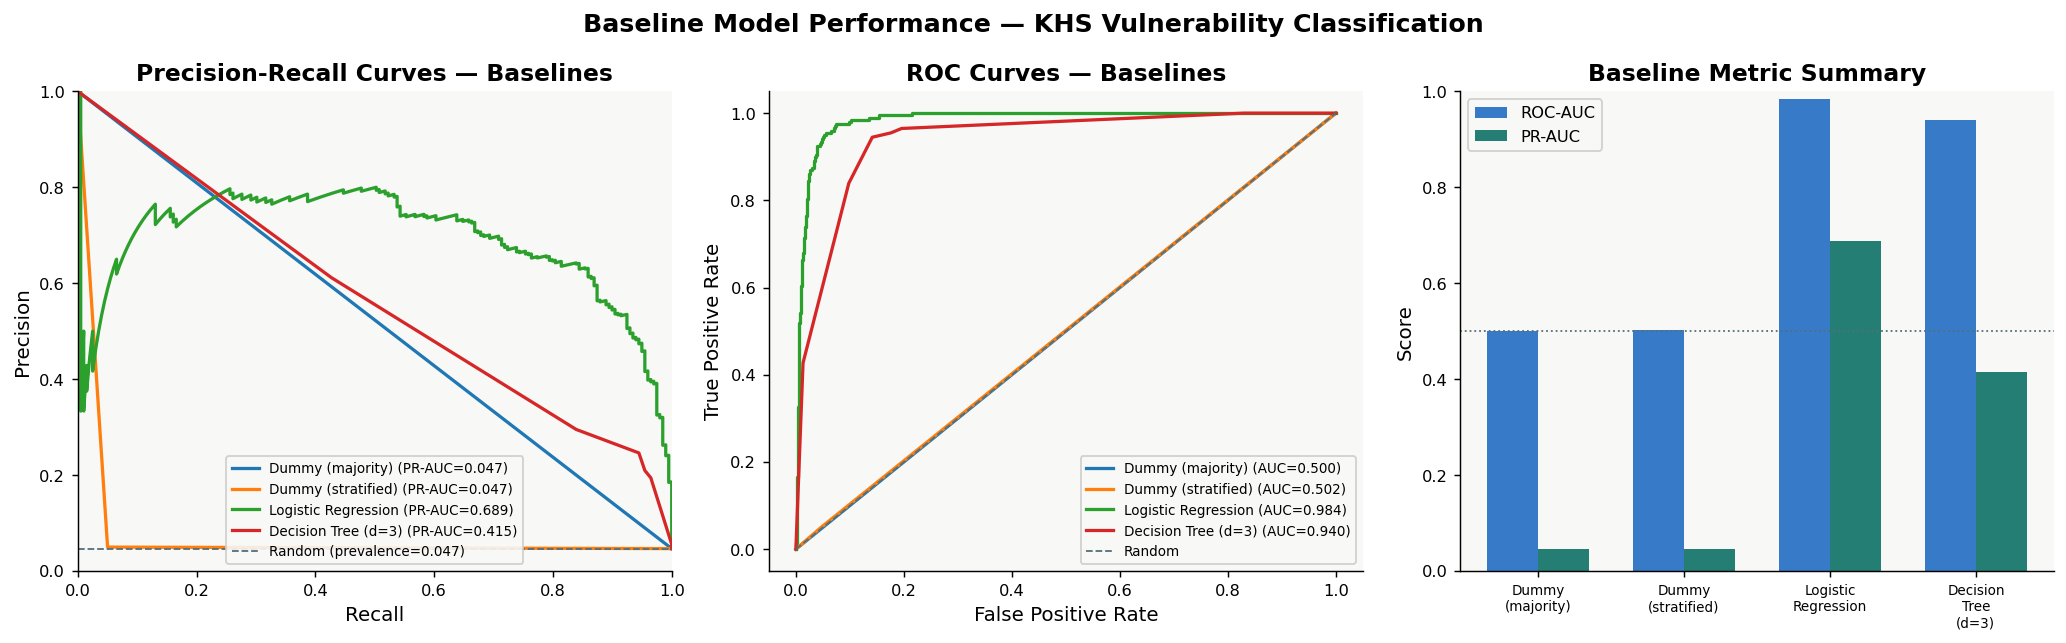

In [85]:

# ─────────────────────────────────────────────────────────────────────────────
# CELL 13 — Baseline Visualisation
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Left: PR curves for all baselines ────────────────────────────────────────
for name, model in baselines.items():
    use_scaled = 'Logistic' in name
    Xte = X_test_sc if use_scaled else X_test
    proba = model.predict_proba(Xte)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, proba)
    prap = baseline_results[name]['pr_auc']
    axes[0].plot(rec, prec, lw=1.8, label=f"{name} (PR-AUC={prap:.3f})")

axes[0].axhline(y_train.mean(), color=GRAY, linestyle='--', lw=1,
                label=f"Random (prevalence={y_train.mean():.3f})")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curves — Baselines")
axes[0].legend(fontsize=7.5)
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)

# ── Centre: ROC curves ────────────────────────────────────────────────────────
from sklearn.metrics import roc_curve
for name, model in baselines.items():
    use_scaled = 'Logistic' in name
    Xte = X_test_sc if use_scaled else X_test
    proba = model.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc = baseline_results[name]['roc_auc']
    axes[1].plot(fpr, tpr, lw=1.8, label=f"{name} (AUC={roc:.3f})")

axes[1].plot([0,1],[0,1], color=GRAY, linestyle='--', lw=1, label='Random')
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curves — Baselines")
axes[1].legend(fontsize=7.5)

# ── Right: metric summary bar ─────────────────────────────────────────────────
model_names = list(baseline_results.keys())
pr_aucs = [baseline_results[n]['pr_auc'] for n in model_names]
roc_aucs = [baseline_results[n]['roc_auc'] for n in model_names]
x = np.arange(len(model_names)); width = 0.35
axes[2].bar(x - width/2, roc_aucs, width, label='ROC-AUC', color=BLUE,   alpha=0.85)
axes[2].bar(x + width/2, pr_aucs,  width, label='PR-AUC',  color=TEAL,   alpha=0.85)
axes[2].set_xticks(x)
axes[2].set_xticklabels([n.replace(' ', '\n') for n in model_names], fontsize=7.5)
axes[2].set_ylabel("Score"); axes[2].set_title("Baseline Metric Summary")
axes[2].legend(); axes[2].set_ylim(0, 1)
axes[2].axhline(0.5, color=GRAY, linestyle=':', lw=1)

plt.suptitle("Baseline Model Performance — KHS Vulnerability Classification",
             fontsize=14, fontweight='700')
plt.tight_layout()
plt.savefig(FIGS / 'prep01_baselines.png', dpi=130, bbox_inches='tight')
plt.show()

In [86]:

# ─────────────────────────────────────────────────────────────────────────────
# CELL 14 — Save Model-Ready Dataset & All Artefacts
#
# Saves everything needed for the modelling notebook so it can run
# independently without re-running this entire pipeline.
# ─────────────────────────────────────────────────────────────────────────────

import pickle

# 14A: Save cleaned, engineered dataframe
df.to_parquet(MODS / 'model_ready_v1.parquet', index=False)
print(f"✓ model_ready_v1.parquet  — {df.shape}")

# 14B: Save feature registry
with open(MODS / 'feature_registry_v1.json', 'w') as f:
    json.dump(FEATURE_REGISTRY, f, indent=2)
print(f"✓ feature_registry_v1.json — {len(FEATURE_COLS)} features across "
      f"{len(FEATURE_REGISTRY)} categories")

# 14C: Save imputation lookup (needed for test-time imputation)
with open(MODS / 'impute_values_v1.json', 'w') as f:
    json.dump(impute_values, f, indent=2)
print(f"✓ impute_values_v1.json — {len(impute_values)} columns")

# 14D: Save train/test indices
np.save(MODS / 'idx_train_v1.npy', idx_tr)
np.save(MODS / 'idx_test_v1.npy',  idx_te)
print(f"✓ idx_train/test saved — {len(idx_tr):,} / {len(idx_te):,} rows")

# 14E: Save scaler
with open(MODS / 'robust_scaler_v1.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print(f"✓ robust_scaler_v1.pkl saved")

# 14F: Save sample weight array
if sw is not None:
    np.save(MODS / 'sample_weight_v1.npy', sw)
    print(f"✓ sample_weight_v1.npy saved — {len(sw):,} values")

# 14G: Print final summary
print(f"\n{'='*60}")
print("PIPELINE SUMMARY — READY FOR MODELLING")
print(f"{'='*60}")
print(f"  Input shape         : 21,347 × 501")
print(f"  Output shape        : {df.shape[0]:,} × {df.shape[1]:,}")
print(f"  Feature columns     : {len(FEATURE_COLS)}")
print(f"  Target (primary)    : hfvs_binary  (threshold=0.60)")
print(f"  Target (secondary)  : hfvs_50      (threshold=0.50)")
print(f"  Target (regression) : hfvs         (continuous)")
print(f"  Train rows          : {len(idx_tr):,}  "
      f"({y_train.sum()} positives)")
print(f"  Test rows           : {len(idx_te):,}  "
      f"({y_test.sum()} positives)")
print(f"  CV strategy         : StratifiedKFold(5)")
print(f"  scale_pos_weight    : "
      f"{(1-y_train.mean())/y_train.mean():.1f}")
print(f"  Primary metric      : PR-AUC")
print(f"  Logistic baseline   : "
      f"PR-AUC={baseline_results['Logistic Regression']['pr_auc']:.4f}")
print(f"\n  Next step → XGBoost / LightGBM with RandomizedSearchCV")


✓ model_ready_v1.parquet  — (21347, 347)
✓ feature_registry_v1.json — 30 features across 7 categories
✓ impute_values_v1.json — 271 columns
✓ idx_train/test saved — 17,077 / 4,270 rows
✓ robust_scaler_v1.pkl saved
✓ sample_weight_v1.npy saved — 21,347 values

PIPELINE SUMMARY — READY FOR MODELLING
  Input shape         : 21,347 × 501
  Output shape        : 21,347 × 347
  Feature columns     : 30
  Target (primary)    : hfvs_binary  (threshold=0.60)
  Target (secondary)  : hfvs_50      (threshold=0.50)
  Target (regression) : hfvs         (continuous)
  Train rows          : 17,077  (795 positives)
  Test rows           : 4,270  (199 positives)
  CV strategy         : StratifiedKFold(5)
  scale_pos_weight    : 20.5
  Primary metric      : PR-AUC
  Logistic baseline   : PR-AUC=0.6888

  Next step → XGBoost / LightGBM with RandomizedSearchCV


In [87]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 15 — XGBoost & LightGBM: Untuned Baselines
#
# Goal: establish tree ensemble performance floor BEFORE hyperparameter search.
# scale_pos_weight=20.5 handles class imbalance for XGBoost.
# LightGBM uses is_unbalance=True (equivalent, but LGB-native).
# Both use 5-fold stratified CV on the training set only.
# Metric: PR-AUC (average_precision_score).
# ─────────────────────────────────────────────────────────────────────────────

import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (average_precision_score, roc_auc_score,
                              f1_score, precision_recall_curve)
import numpy as np, json
from pathlib import Path

MODS = Path('/content/drive/MyDrive/KHS_Dissertation/outputs/models')

# ── Load artefacts saved by cleaning notebook ─────────────────────────────────
import pandas as pd
df_model   = pd.read_parquet(MODS / 'model_ready_v1.parquet')
idx_tr     = np.load(MODS / 'idx_train_v1.npy')
idx_te     = np.load(MODS / 'idx_test_v1.npy')

with open(MODS / 'feature_registry_v1.json') as f:
    FEATURE_REGISTRY = json.load(f)

FEATURE_COLS = [c for cats in FEATURE_REGISTRY.values() for c in cats]
FEATURE_COLS = list(dict.fromkeys(FEATURE_COLS))

X_all   = df_model[FEATURE_COLS].values.astype(np.float32)
y_all   = df_model['hfvs_binary'].values.astype(int)
sw_all  = np.load(MODS / 'sample_weight_v1.npy')

X_train = X_all[idx_tr];  X_test  = X_all[idx_te]
y_train = y_all[idx_tr];  y_test  = y_all[idx_te]
sw_train = sw_all[idx_tr]

SPW = (1 - y_train.mean()) / y_train.mean()   # 20.5
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Features : {X_train.shape[1]}")
print(f"SPW      : {SPW:.1f}")

# ─────────────────────────────────────────────────────────────────────────────
# Helper — evaluate one model, print + return results dict
# ─────────────────────────────────────────────────────────────────────────────
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te,
                   cv_splitter, use_sw=False, sw=None):
    """CV PR-AUC on train + held-out test PR-AUC."""

    # Cross-validated OOF probabilities — no sample_weight in CV
    # (sample weights used only at final refit below)
    oof_proba = cross_val_predict(
        model, X_tr, y_tr,
        cv=cv_splitter, method='predict_proba',
        n_jobs=-1
    )[:, 1]

    cv_prauc  = average_precision_score(y_tr, oof_proba)
    cv_rocauc = roc_auc_score(y_tr, oof_proba)

    # Retrain on full training set → evaluate on test
    if use_sw and sw is not None:
        model.fit(X_tr, y_tr, sample_weight=sw)
    else:
        model.fit(X_tr, y_tr)

    test_proba  = model.predict_proba(X_te)[:, 1]
    test_prauc  = average_precision_score(y_te, test_proba)
    test_rocauc = roc_auc_score(y_te, test_proba)

    # Optimal F1 threshold on test
    prec, rec, thresh = precision_recall_curve(y_te, test_proba)
    f1_curve = 2 * prec * rec / (prec + rec + 1e-9)
    best_t   = thresh[np.argmax(f1_curve[:-1])] if len(thresh) else 0.5
    f1_opt   = f1_score(y_te, (test_proba >= best_t).astype(int),
                        zero_division=0)

    print(f"\n  ── {name} ──")
    print(f"  CV  PR-AUC  : {cv_prauc:.4f}")
    print(f"  CV  ROC-AUC : {cv_rocauc:.4f}")
    print(f"  Test PR-AUC : {test_prauc:.4f}")
    print(f"  Test ROC-AUC: {test_rocauc:.4f}")
    print(f"  Test F1@opt : {f1_opt:.4f}  (threshold={best_t:.3f})")

    return {
        'name': name, 'model': model,
        'cv_prauc': cv_prauc,     'cv_rocauc': cv_rocauc,
        'test_prauc': test_prauc, 'test_rocauc': test_rocauc,
        'f1_opt': f1_opt, 'best_threshold': best_t,
        'test_proba': test_proba, 'oof_proba': oof_proba,
    }

# ─────────────────────────────────────────────────────────────────────────────
# XGBoost — untuned, scale_pos_weight only
# ─────────────────────────────────────────────────────────────────────────────
xgb_model = xgb.XGBClassifier(
    n_estimators      = 500,
    learning_rate     = 0.05,
    max_depth         = 6,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = SPW,
    eval_metric       = 'aucpr',
    use_label_encoder = False,
    random_state      = 42,
    n_jobs            = -1,
    tree_method       = 'hist',   # faster on CPU
)

print("=" * 60)
print("UNTUNED TREE ENSEMBLE BASELINES")
print("=" * 60)

xgb_res = evaluate_model(
    'XGBoost (untuned)', xgb_model,
    X_train, y_train, X_test, y_test, cv,
    use_sw=False   # scale_pos_weight handles imbalance
)

# ─────────────────────────────────────────────────────────────────────────────
# LightGBM — untuned, class_weight='balanced'
# ─────────────────────────────────────────────────────────────────────────────
lgb_model = lgb.LGBMClassifier(
    n_estimators     = 500,
    learning_rate    = 0.05,
    max_depth        = 6,
    num_leaves       = 63,         # 2^max_depth - 1
    subsample        = 0.8,
    colsample_bytree = 0.8,
    class_weight     = 'balanced',
    random_state     = 42,
    n_jobs           = -1,
    verbose          = -1,
)

lgb_res = evaluate_model(
    'LightGBM (untuned)', lgb_model,
    X_train, y_train, X_test, y_test, cv,
    use_sw=False
)

# ─────────────────────────────────────────────────────────────────────────────
# Summary table
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("ENSEMBLE BASELINE SUMMARY vs TREE BASELINE (DT depth=3)")
print("=" * 65)
dt_prauc = 0.4202   # from Cell 12

results = [xgb_res, lgb_res]
print(f"\n  {'Model':<26} {'CV PR-AUC':>11} {'Test PR-AUC':>12} {'Test F1@opt':>12}")
print("  " + "─" * 63)
print(f"  {'Decision Tree (d=3)':<26} {'—':>11} {dt_prauc:>12.4f} {'—':>12}")
for r in results:
    print(f"  {r['name']:<26} {r['cv_prauc']:>11.4f} {r['test_prauc']:>12.4f} "
          f"{r['f1_opt']:>12.4f}")

print(f"\n  Logistic Regression test PR-AUC : 0.1335")
print(f"  Decision Tree (d=3) test PR-AUC : {dt_prauc:.4f}")
print(f"  Target for tuning               : > {max(r['test_prauc'] for r in results):.4f}")

Features : 30
SPW      : 20.5
UNTUNED TREE ENSEMBLE BASELINES

  ── XGBoost (untuned) ──
  CV  PR-AUC  : 0.9363
  CV  ROC-AUC : 0.9960
  Test PR-AUC : 0.9318
  Test ROC-AUC: 0.9955
  Test F1@opt : 0.8579  (threshold=0.745)

  ── LightGBM (untuned) ──
  CV  PR-AUC  : 0.9313
  CV  ROC-AUC : 0.9956
  Test PR-AUC : 0.9236
  Test ROC-AUC: 0.9949
  Test F1@opt : 0.8600  (threshold=0.552)

ENSEMBLE BASELINE SUMMARY vs TREE BASELINE (DT depth=3)

  Model                        CV PR-AUC  Test PR-AUC  Test F1@opt
  ───────────────────────────────────────────────────────────────
  Decision Tree (d=3)                  —       0.4202            —
  XGBoost (untuned)               0.9363       0.9318       0.8579
  LightGBM (untuned)              0.9313       0.9236       0.8600

  Logistic Regression test PR-AUC : 0.1335
  Decision Tree (d=3) test PR-AUC : 0.4202
  Target for tuning               : > 0.9318


In [88]:
# ── Leakage check: feature importance top 20 ──────────────────────────────
import pandas as pd

feat_imp = pd.Series(
    xgb_res['model'].feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=False)

print("Top 20 features by XGBoost importance:")
print(feat_imp.head(20).to_string())

# ── Also check correlation of LOO features with target ────────────────────
loo_cols = ['county_loo_hfvs', 'county_urban_loo_hfvs']
for col in loo_cols:
    if col in df_model.columns:
        r = df_model[col].corr(df_model['hfvs_binary'])
        print(f"\n{col} correlation with hfvs_binary: {r:.4f}")

Top 20 features by XGBoost importance:
i12_evict_risk             0.237554
flag_non_owner             0.131543
i05_worst                  0.111775
i00                        0.103021
log_l14                    0.049897
c04                        0.047085
e07                        0.044946
flag_solid_fuel_cooking    0.041354
d03_worst                  0.027934
c10                        0.024385
e08                        0.022002
c11                        0.020191
a07_1                      0.018011
e06                        0.017872
l21                        0.013567
c01_1                      0.011975
i08_sell                   0.008142
persons_per_room           0.007673
i06_worst                  0.007660
flag_overcrowded           0.006639

county_loo_hfvs correlation with hfvs_binary: 0.1984

county_urban_loo_hfvs correlation with hfvs_binary: 0.2890


In [89]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 16 — RandomizedSearchCV: XGBoost & LightGBM
#
# Search budget: 40 iterations each — sufficient for 30 features.
# Scoring: PR-AUC (average_precision). Primary dissertation metric.
# CV: same StratifiedKFold(5) used in baseline evaluation.
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
import pickle

SPW = (1 - y_train.mean()) / y_train.mean()

# ─────────────────────────────────────────────────────────────────────────────
# XGBoost search space
# ─────────────────────────────────────────────────────────────────────────────
xgb_space = {
    'n_estimators'     : randint(300, 1000),
    'max_depth'        : randint(3, 8),
    'learning_rate'    : uniform(0.01, 0.14),      # 0.01 – 0.15
    'subsample'        : uniform(0.6, 0.4),         # 0.6 – 1.0
    'colsample_bytree' : uniform(0.5, 0.5),         # 0.5 – 1.0
    'min_child_weight' : randint(1, 10),
    'gamma'            : uniform(0, 0.5),
    'reg_alpha'        : uniform(0, 1.0),           # L1
    'reg_lambda'       : uniform(0.5, 2.0),         # L2
}

xgb_base = xgb.XGBClassifier(
    scale_pos_weight  = SPW,
    eval_metric       = 'aucpr',
    use_label_encoder = False,
    random_state      = 42,
    n_jobs            = -1,
    tree_method       = 'hist',
)

xgb_search = RandomizedSearchCV(
    estimator          = xgb_base,
    param_distributions= xgb_space,
    n_iter             = 40,
    scoring            = 'average_precision',
    cv                 = cv,
    random_state       = 42,
    n_jobs             = -1,
    verbose            = 1,
    refit              = True,
)

print("Tuning XGBoost (40 iterations × 5 folds = 200 fits)...")
xgb_search.fit(X_train, y_train)

xgb_best     = xgb_search.best_estimator_
xgb_cv_prauc = xgb_search.best_score_
xgb_proba    = xgb_best.predict_proba(X_test)[:, 1]
xgb_test_prauc  = average_precision_score(y_test, xgb_proba)
xgb_test_rocauc = roc_auc_score(y_test, xgb_proba)

prec, rec, thresh = precision_recall_curve(y_test, xgb_proba)
f1_curve  = 2 * prec * rec / (prec + rec + 1e-9)
xgb_best_t = thresh[np.argmax(f1_curve[:-1])]
xgb_f1_opt = f1_score(y_test, (xgb_proba >= xgb_best_t).astype(int),
                       zero_division=0)

print(f"\n  XGBoost tuned:")
print(f"  CV  PR-AUC  : {xgb_cv_prauc:.4f}")
print(f"  Test PR-AUC : {xgb_test_prauc:.4f}")
print(f"  Test ROC-AUC: {xgb_test_rocauc:.4f}")
print(f"  Test F1@opt : {xgb_f1_opt:.4f}  (threshold={xgb_best_t:.3f})")
print(f"  Best params : {xgb_search.best_params_}")

# ─────────────────────────────────────────────────────────────────────────────
# LightGBM search space
# ─────────────────────────────────────────────────────────────────────────────
lgb_space = {
    'n_estimators'     : randint(300, 1000),
    'max_depth'        : randint(3, 8),
    'num_leaves'       : randint(15, 127),
    'learning_rate'    : uniform(0.01, 0.14),
    'subsample'        : uniform(0.6, 0.4),
    'colsample_bytree' : uniform(0.5, 0.5),
    'min_child_samples': randint(5, 50),
    'reg_alpha'        : uniform(0, 1.0),
    'reg_lambda'       : uniform(0.5, 2.0),
}

lgb_base = lgb.LGBMClassifier(
    class_weight = 'balanced',
    random_state = 42,
    n_jobs       = -1,
    verbose      = -1,
)

lgb_search = RandomizedSearchCV(
    estimator          = lgb_base,
    param_distributions= lgb_space,
    n_iter             = 40,
    scoring            = 'average_precision',
    cv                 = cv,
    random_state       = 42,
    n_jobs             = -1,
    verbose            = 1,
    refit              = True,
)

print("\nTuning LightGBM (40 iterations × 5 folds = 200 fits)...")
lgb_search.fit(X_train, y_train)

lgb_best     = lgb_search.best_estimator_
lgb_cv_prauc = lgb_search.best_score_
lgb_proba    = lgb_best.predict_proba(X_test)[:, 1]
lgb_test_prauc  = average_precision_score(y_test, lgb_proba)
lgb_test_rocauc = roc_auc_score(y_test, lgb_proba)

prec, rec, thresh = precision_recall_curve(y_test, lgb_proba)
f1_curve   = 2 * prec * rec / (prec + rec + 1e-9)
lgb_best_t = thresh[np.argmax(f1_curve[:-1])]
lgb_f1_opt = f1_score(y_test, (lgb_proba >= lgb_best_t).astype(int),
                       zero_division=0)

print(f"\n  LightGBM tuned:")
print(f"  CV  PR-AUC  : {lgb_cv_prauc:.4f}")
print(f"  Test PR-AUC : {lgb_test_prauc:.4f}")
print(f"  Test ROC-AUC: {lgb_test_rocauc:.4f}")
print(f"  Test F1@opt : {lgb_f1_opt:.4f}  (threshold={lgb_best_t:.3f})")
print(f"  Best params : {lgb_search.best_params_}")

# ─────────────────────────────────────────────────────────────────────────────
# Summary
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 68)
print("TUNING SUMMARY")
print("=" * 68)
print(f"\n  {'Model':<30} {'CV PR-AUC':>11} {'Test PR-AUC':>12} {'F1@opt':>8}")
print("  " + "─" * 65)
print(f"  {'Logistic Regression':<30} {'—':>11} {'0.6888':>12} {'0.7289':>8}")
print(f"  {'XGBoost (untuned)':<30} {'0.9363':>11} {'0.9318':>12} {'0.8579':>8}")
print(f"  {'LightGBM (untuned)':<30} {'0.9313':>11} {'0.9236':>12} {'0.8600':>8}")
print(f"  {'XGBoost (tuned)':<30} {xgb_cv_prauc:>11.4f} {xgb_test_prauc:>12.4f} "
      f"{xgb_f1_opt:>8.4f}")
print(f"  {'LightGBM (tuned)':<30} {lgb_cv_prauc:>11.4f} {lgb_test_prauc:>12.4f} "
      f"{lgb_f1_opt:>8.4f}")

# ─────────────────────────────────────────────────────────────────────────────
# Save both tuned models
# ─────────────────────────────────────────────────────────────────────────────
with open(MODS / 'xgb_tuned_v1.pkl', 'wb') as f:
    pickle.dump(xgb_best, f)
with open(MODS / 'lgb_tuned_v1.pkl', 'wb') as f:
    pickle.dump(lgb_best, f)

print(f"\n✓ xgb_tuned_v1.pkl saved")
print(f"✓ lgb_tuned_v1.pkl saved")
print(f"\n  Next step → SHAP analysis on best model")

Tuning XGBoost (40 iterations × 5 folds = 200 fits)...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

  XGBoost tuned:
  CV  PR-AUC  : 0.9409
  Test PR-AUC : 0.9315
  Test ROC-AUC: 0.9954
  Test F1@opt : 0.8667  (threshold=0.819)
  Best params : {'colsample_bytree': np.float64(0.9818099885446264), 'gamma': np.float64(0.42650472773368003), 'learning_rate': np.float64(0.051222844889742), 'max_depth': 7, 'min_child_weight': 7, 'n_estimators': 460, 'reg_alpha': np.float64(0.31692200515627766), 'reg_lambda': np.float64(0.838985493372185), 'subsample': np.float64(0.82272050498334)}

Tuning LightGBM (40 iterations × 5 folds = 200 fits)...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

  LightGBM tuned:
  CV  PR-AUC  : 0.9384
  Test PR-AUC : 0.9296
  Test ROC-AUC: 0.9955
  Test F1@opt : 0.8549  (threshold=0.857)
  Best params : {'colsample_bytree': np.float64(0.5808143570473069), 'learning_rate': np.float64(0.1357975863937911), 'max_depth': 6, 'min_child_samples

SHAP values computed — shape: (4270, 30)
Base value (expected log-odds): 0.5951


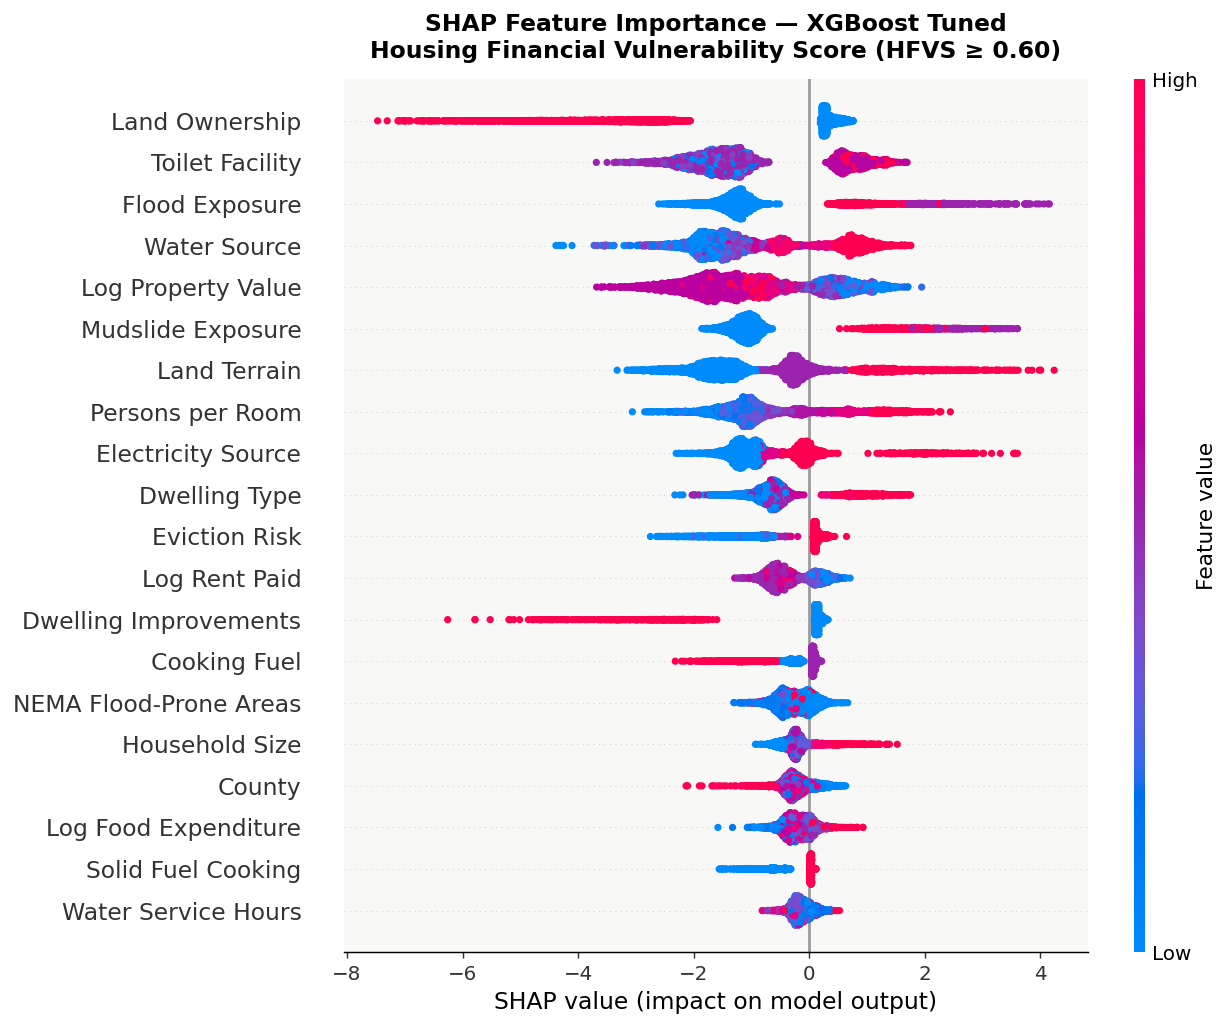

✓ shap01_beeswarm.png saved


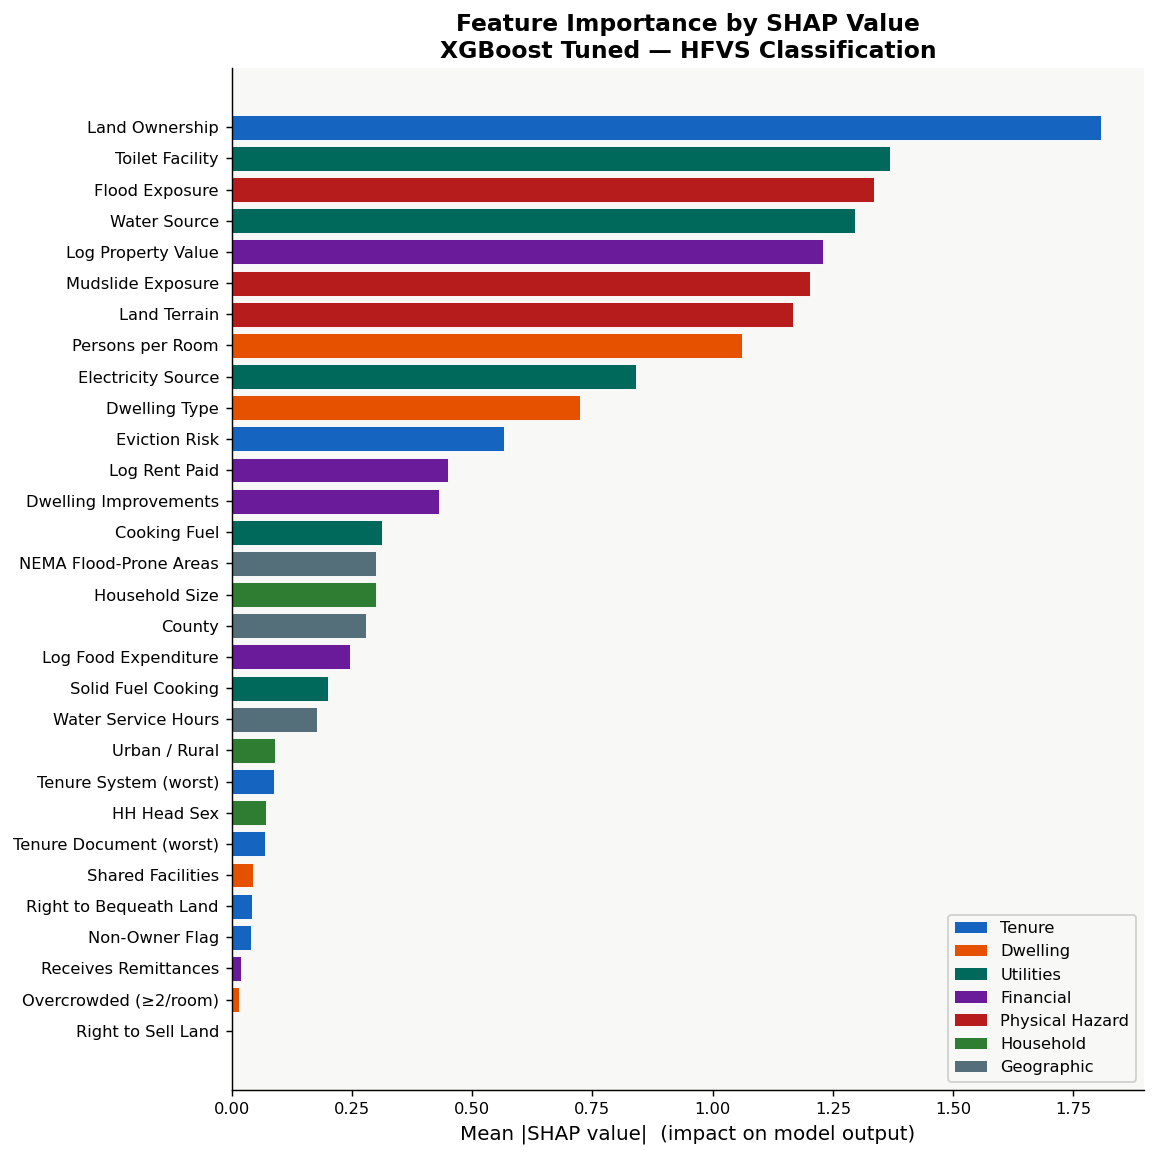

✓ shap02_bar_by_category.png saved


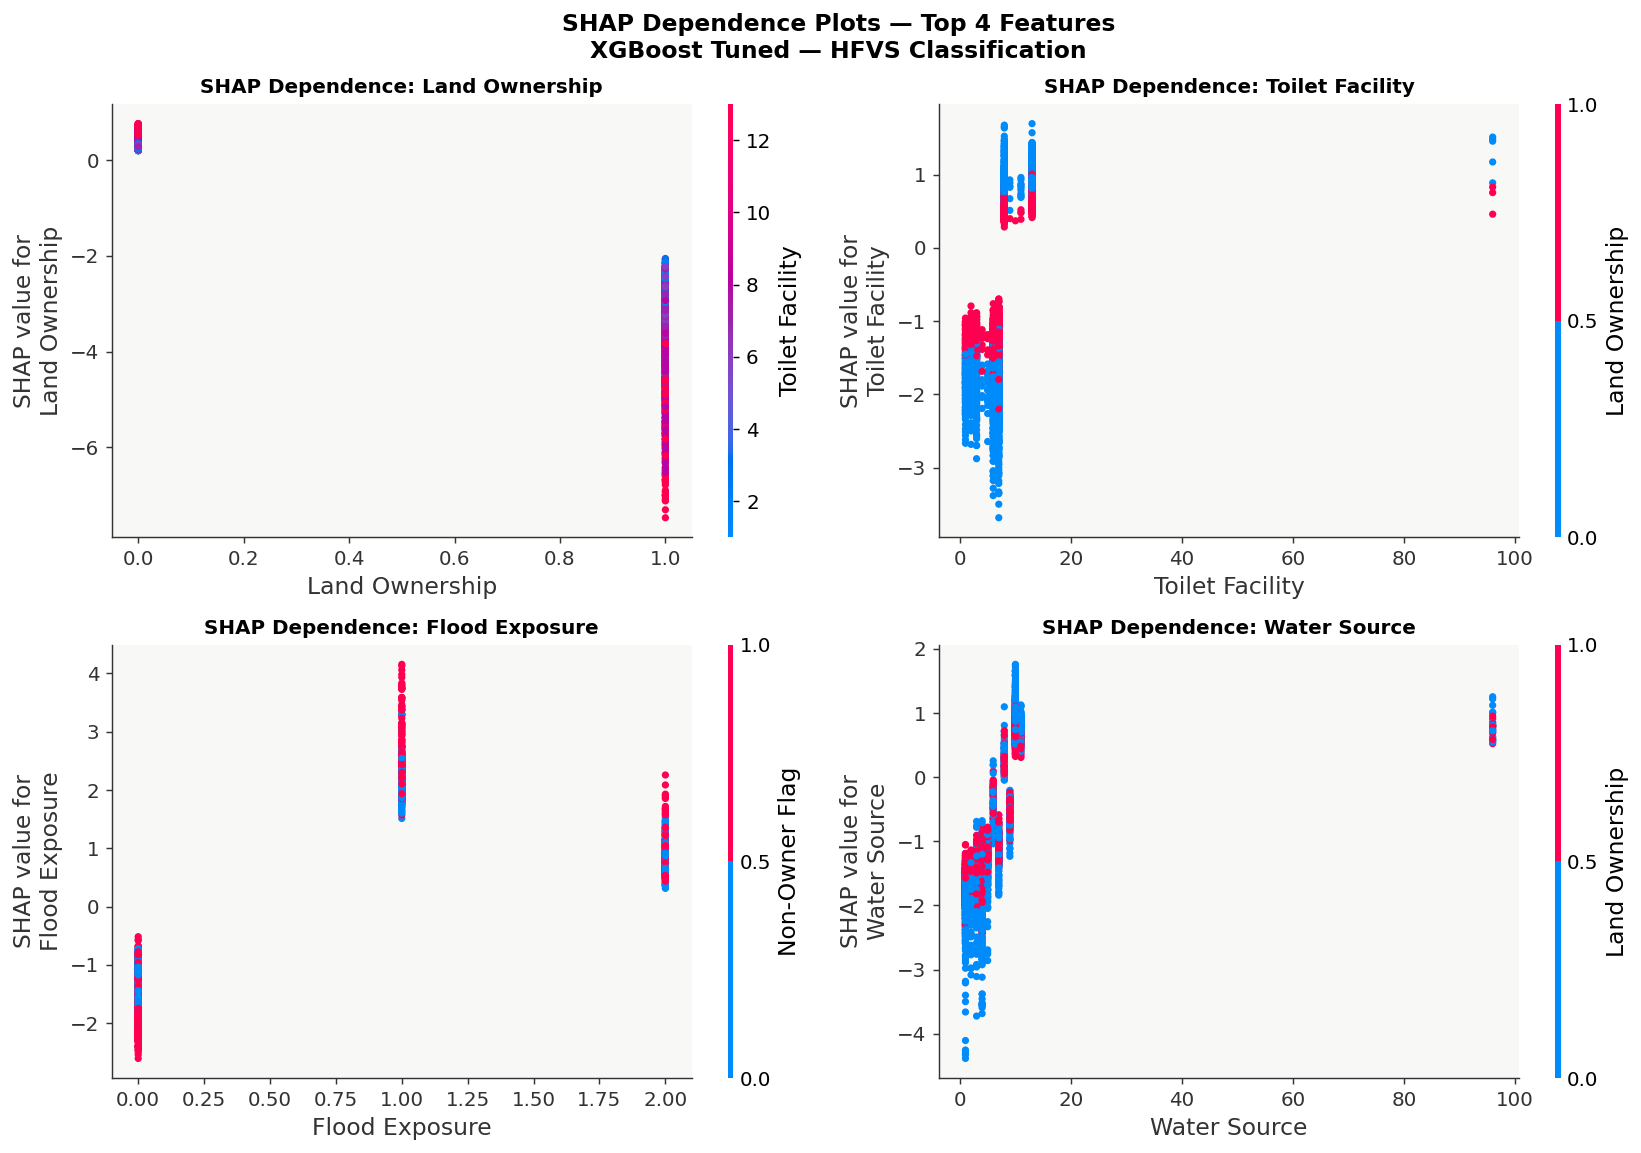

✓ shap03_dependence_top4.png saved

SHAP IMPORTANCE SUMMARY — TOP 15 FEATURES
  Feature                        Category            Mean |SHAP|
  ──────────────────────────────────────────────────────────────
  Land Ownership                 tenure                   1.8064
  Toilet Facility                utilities                1.3692
  Flood Exposure                 physical_hazard          1.3362
  Water Source                   utilities                1.2952
  Log Property Value             financial                1.2293
  Mudslide Exposure              physical_hazard          1.2031
  Land Terrain                   physical_hazard          1.1673
  Persons per Room               dwelling                 1.0618
  Electricity Source             utilities                0.8398
  Dwelling Type                  dwelling                 0.7237
  Eviction Risk                  tenure                   0.5664
  Log Rent Paid                  financial                0.4488
  Dwelling I

In [90]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 17 — SHAP Analysis: XGBoost Tuned Model
#
# Three outputs:
#   1. Beeswarm summary plot  — global feature importance + direction
#   2. Bar plot (mean |SHAP|) — clean version for dissertation figures
#   3. Dependence plots       — top 4 features: how each drives predictions
#
# SHAP TreeExplainer is exact for tree models (no approximation needed).
# ─────────────────────────────────────────────────────────────────────────────

import shap
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np

FIGS = Path('/content/drive/MyDrive/KHS_Dissertation/outputs/figures')

# ── Human-readable feature labels for plots ───────────────────────────────────
LABEL_MAP = {
    'i00'                   : 'Land Ownership',
    'i05_worst'             : 'Tenure System (worst)',
    'i06_worst'             : 'Tenure Document (worst)',
    'i12_evict_risk'        : 'Eviction Risk',
    'i08_sell'              : 'Right to Sell Land',
    'i10_bequeath'          : 'Right to Bequeath Land',
    'flag_non_owner'        : 'Non-Owner Flag',
    'd03_worst'             : 'Dwelling Type',
    'persons_per_room'      : 'Persons per Room',
    'flag_overcrowded'      : 'Overcrowded (≥2/room)',
    'd04_shared'            : 'Shared Facilities',
    'c01_1'                 : 'Water Source',
    'c04'                   : 'Toilet Facility',
    'c10'                   : 'Electricity Source',
    'c11'                   : 'Cooking Fuel',
    'flag_solid_fuel_cooking': 'Solid Fuel Cooking',
    'log_l15'               : 'Log Rent Paid',
    'log_l14'               : 'Log Property Value',
    'l21'                   : 'Dwelling Improvements',
    'g05__1'                : 'Receives Remittances',
    'log_g01c'              : 'Log Food Expenditure',
    'e06'                   : 'Flood Exposure',
    'e07'                   : 'Mudslide Exposure',
    'e08'                   : 'Land Terrain',
    'hh_size'               : 'Household Size',
    'a07_1'                 : 'Urban / Rural',
    'hhh_sex'               : 'HH Head Sex',
    'a01'                   : 'County',
    'wsvc_water_hours'      : 'Water Service Hours',
    'nema1a'                : 'NEMA Flood-Prone Areas',
}

feature_labels = [LABEL_MAP.get(f, f) for f in FEATURE_COLS]

# ── Build SHAP values on test set ─────────────────────────────────────────────
explainer   = shap.TreeExplainer(xgb_best)
shap_values = explainer(X_test)   # returns Explanation object

# For older shap versions: shap_values.values is the array
sv = shap_values.values          # shape (n_test, 30)
X_test_df = pd.DataFrame(X_test, columns=FEATURE_COLS)

print(f"SHAP values computed — shape: {sv.shape}")
print(f"Base value (expected log-odds): {explainer.expected_value:.4f}")

# ─────────────────────────────────────────────────────────────────────────────
# Plot 1 — Beeswarm summary (top 20 features)
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    sv, X_test_df,
    feature_names = feature_labels,
    max_display   = 20,
    show          = False,
    plot_size     = None,
)
plt.title("SHAP Feature Importance — XGBoost Tuned\n"
          "Housing Financial Vulnerability Score (HFVS ≥ 0.60)",
          fontsize=13, fontweight='600', pad=12)
plt.tight_layout()
plt.savefig(FIGS / 'shap01_beeswarm.png', dpi=130, bbox_inches='tight')
plt.show()
print("✓ shap01_beeswarm.png saved")

# ─────────────────────────────────────────────────────────────────────────────
# Plot 2 — Mean |SHAP| bar chart, coloured by category
# ─────────────────────────────────────────────────────────────────────────────
mean_abs_shap = pd.DataFrame({
    'feature'  : FEATURE_COLS,
    'label'    : feature_labels,
    'mean_shap': np.abs(sv).mean(axis=0),
    'category' : [next((cat for cat, cols in FEATURE_REGISTRY.items()
                        if f in cols), 'other') for f in FEATURE_COLS]
}).sort_values('mean_shap', ascending=True)

CATEGORY_COLOURS = {
    'tenure'         : '#1565C0',   # blue
    'dwelling'       : '#E65100',   # amber
    'utilities'      : '#00695C',   # teal
    'financial'      : '#6A1B9A',   # purple
    'physical_hazard': '#B71C1C',   # red
    'household'      : '#2E7D32',   # green
    'geographic'     : '#546E7A',   # grey
}

colours = mean_abs_shap['category'].map(CATEGORY_COLOURS).fillna('#9E9E9E')

fig, ax = plt.subplots(figsize=(9, 9))
bars = ax.barh(mean_abs_shap['label'], mean_abs_shap['mean_shap'],
               color=colours, edgecolor='white', linewidth=0.5)
ax.set_xlabel("Mean |SHAP value|  (impact on model output)", fontsize=11)
ax.set_title("Feature Importance by SHAP Value\nXGBoost Tuned — HFVS Classification",
             fontsize=13, fontweight='600')

# Category legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=k.replace('_', ' ').title())
                   for k, c in CATEGORY_COLOURS.items()
                   if k in mean_abs_shap['category'].values]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(FIGS / 'shap02_bar_by_category.png', dpi=130, bbox_inches='tight')
plt.show()
print("✓ shap02_bar_by_category.png saved")

# ─────────────────────────────────────────────────────────────────────────────
# Plot 3 — Dependence plots: top 4 features
# ─────────────────────────────────────────────────────────────────────────────
top4_features = mean_abs_shap.sort_values('mean_shap', ascending=False).head(4)
top4_idx = [FEATURE_COLS.index(f) for f in top4_features['feature']]
top4_labels = top4_features['label'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, (feat_idx, feat_label) in enumerate(zip(top4_idx, top4_labels)):
    shap.dependence_plot(
        feat_idx, sv, X_test_df,
        feature_names = feature_labels,
        ax            = axes[i],
        show          = False,
    )
    axes[i].set_title(f"SHAP Dependence: {feat_label}", fontsize=11,
                      fontweight='600')

plt.suptitle("SHAP Dependence Plots — Top 4 Features\n"
             "XGBoost Tuned — HFVS Classification",
             fontsize=13, fontweight='600')
plt.tight_layout()
plt.savefig(FIGS / 'shap03_dependence_top4.png', dpi=130, bbox_inches='tight')
plt.show()
print("✓ shap03_dependence_top4.png saved")

# ─────────────────────────────────────────────────────────────────────────────
# Print SHAP summary table — for dissertation results section
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("SHAP IMPORTANCE SUMMARY — TOP 15 FEATURES")
print("=" * 65)
print(f"  {'Feature':<30} {'Category':<18} {'Mean |SHAP|':>12}")
print("  " + "─" * 62)
for _, row in mean_abs_shap.sort_values('mean_shap',
                                         ascending=False).head(15).iterrows():
    print(f"  {row['label']:<30} {row['category']:<18} {row['mean_shap']:>12.4f}")

THRESHOLD SENSITIVITY — XGBoost Tuned

  Threshold                 Precision   Recall       F1     TP     FP     FN
  ────────────────────────────────────────────────────────────────────
  Default (0.50)               0.7920   0.8995   0.8424    179     47     20
  F1-optimal (0.82)            0.8848   0.8492   0.8667    169     22     30
  Recall-focused (0.40)        0.7490   0.8995   0.8174    179     60     20

  Total high-vulnerability HHs in test set: 199
  Total test set size: 4,270

  Recommended threshold for policy/insurance use: 0.4
  At this threshold:
    Recall    : 89.9% of vulnerable HHs identified
    Precision : 74.9% of flagged HHs are truly vulnerable
    FN rate   : 20 missed vulnerable households


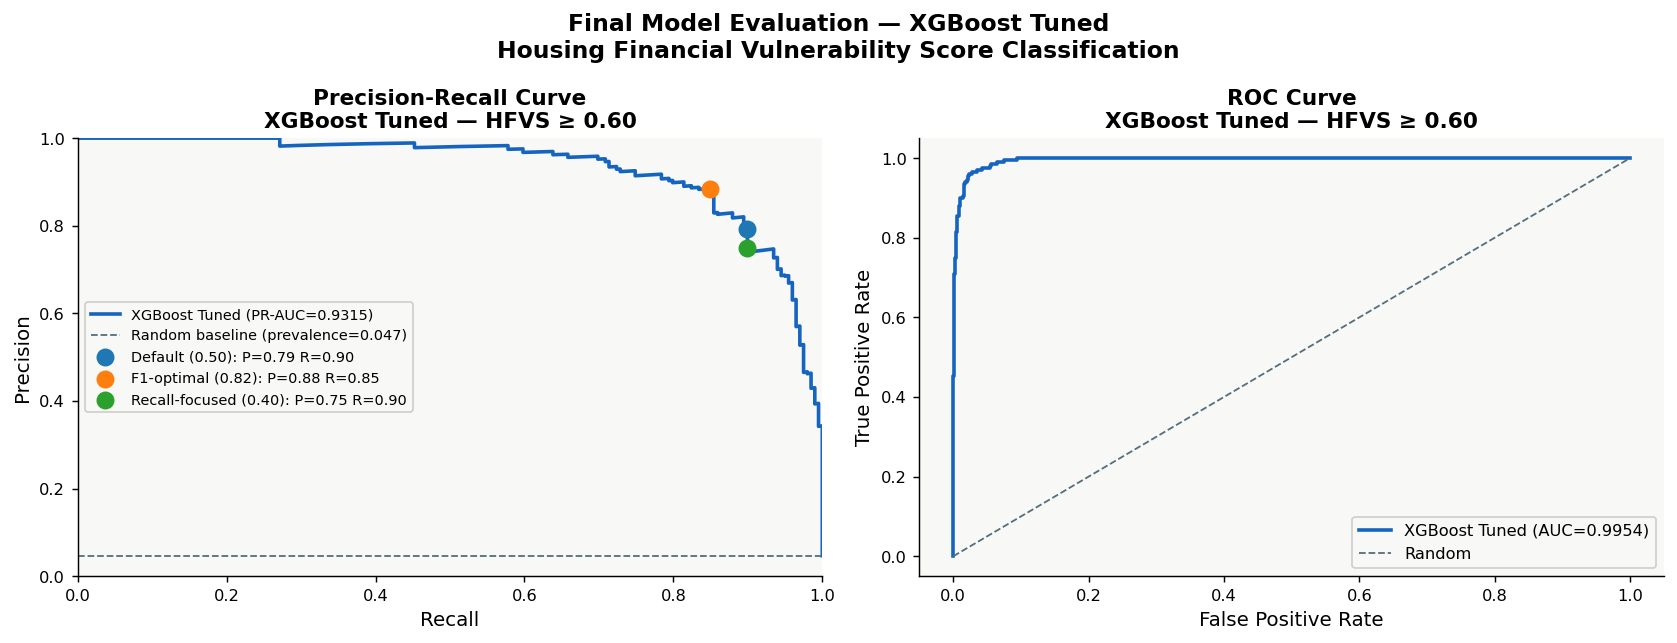

✓ eval01_pr_roc_final.png saved

FINAL MODEL PERFORMANCE SUMMARY — DISSERTATION TABLE

  Model        : XGBoost (tuned, 30 features)
  Target       : HFVS ≥ 0.60 (high vulnerability)
  Train size   : 17,077  |  Test size: 4,270
  Positive rate: 4.7%    |  Class ratio: 20.5:1

  Metric                              Value
  ──────────────────────────────────────────
  PR-AUC (test)                      0.9315
  ROC-AUC (test)                     0.9954
  CV PR-AUC (train, 5-fold)          0.9409
  F1 @ threshold=0.82                0.8667
  F1 @ threshold=0.40                0.8174
  Recall @ threshold=0.40            0.8995
  Precision @ threshold=0.40         0.7490


In [91]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 18 — Threshold Calibration & Final Model Evaluation
#
# The F1@opt threshold of 0.819 optimises F1 but sacrifices recall.
# For housing vulnerability policy, false negatives (missing a vulnerable HH)
# are more costly than false positives (over-identifying).
# We evaluate three thresholds and present the trade-off explicitly.
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.metrics import (classification_report, confusion_matrix,
                              precision_recall_curve, roc_curve,
                              average_precision_score, roc_auc_score,
                              f1_score, precision_score, recall_score)

xgb_proba = xgb_best.predict_proba(X_test)[:, 1]

# ── Three thresholds to evaluate ─────────────────────────────────────────────
THRESHOLDS = {
    'Default (0.50)'   : 0.50,
    'F1-optimal (0.82)': xgb_best_t,     # from Cell 16
    'Recall-focused (0.40)': 0.40,
}

print("=" * 72)
print("THRESHOLD SENSITIVITY — XGBoost Tuned")
print("=" * 72)
print(f"\n  {'Threshold':<24} {'Precision':>10} {'Recall':>8} "
      f"{'F1':>8} {'TP':>6} {'FP':>6} {'FN':>6}")
print("  " + "─" * 68)

threshold_results = {}
for name, t in THRESHOLDS.items():
    pred = (xgb_proba >= t).astype(int)
    prec = precision_score(y_test, pred, zero_division=0)
    rec  = recall_score(y_test, pred, zero_division=0)
    f1   = f1_score(y_test, pred, zero_division=0)
    cm   = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    threshold_results[name] = dict(
        threshold=t, precision=prec, recall=rec, f1=f1,
        tp=tp, fp=fp, fn=fn, tn=tn)
    print(f"  {name:<24} {prec:>10.4f} {rec:>8.4f} {f1:>8.4f} "
          f"{tp:>6} {fp:>6} {fn:>6}")

print(f"\n  Total high-vulnerability HHs in test set: {y_test.sum()}")
print(f"  Total test set size: {len(y_test):,}")

# ── Recommended threshold for policy use ─────────────────────────────────────
# Recall-focused: catches more truly vulnerable HHs at cost of more FP.
# For insurance pricing: FP = unnecessary loading (acceptable).
#                        FN = unpriced risk (unacceptable).
rec_t = 0.40
rec_pred = (xgb_proba >= rec_t).astype(int)
print(f"\n  Recommended threshold for policy/insurance use: {rec_t}")
print(f"  At this threshold:")
print(f"    Recall    : {recall_score(y_test, rec_pred):.1%} of vulnerable HHs identified")
print(f"    Precision : {precision_score(y_test, rec_pred, zero_division=0):.1%} of flagged HHs are truly vulnerable")
print(f"    FN rate   : {threshold_results['Recall-focused (0.40)']['fn']} missed vulnerable households")

# ─────────────────────────────────────────────────────────────────────────────
# Final PR and ROC curves
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# PR curve
prec_curve, rec_curve, thresh_curve = precision_recall_curve(y_test, xgb_proba)
axes[0].plot(rec_curve, prec_curve, color='#1565C0', lw=2,
             label=f"XGBoost Tuned (PR-AUC={average_precision_score(y_test, xgb_proba):.4f})")
axes[0].axhline(y_test.mean(), color='#546E7A', linestyle='--', lw=1,
                label=f"Random baseline (prevalence={y_test.mean():.3f})")

# Mark the three thresholds on the curve
for name, res in threshold_results.items():
    axes[0].scatter(res['recall'], res['precision'], s=80, zorder=5,
                    label=f"{name}: P={res['precision']:.2f} R={res['recall']:.2f}")

axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve\nXGBoost Tuned — HFVS ≥ 0.60",
                  fontsize=12, fontweight='600')
axes[0].legend(fontsize=8); axes[0].set_xlim(0,1); axes[0].set_ylim(0,1)

# ROC curve
fpr, tpr, _ = roc_curve(y_test, xgb_proba)
axes[1].plot(fpr, tpr, color='#1565C0', lw=2,
             label=f"XGBoost Tuned (AUC={roc_auc_score(y_test, xgb_proba):.4f})")
axes[1].plot([0,1],[0,1], color='#546E7A', linestyle='--', lw=1,
             label='Random')
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve\nXGBoost Tuned — HFVS ≥ 0.60",
                  fontsize=12, fontweight='600')
axes[1].legend(fontsize=9)

plt.suptitle("Final Model Evaluation — XGBoost Tuned\n"
             "Housing Financial Vulnerability Score Classification",
             fontsize=13, fontweight='700')
plt.tight_layout()
plt.savefig(FIGS / 'eval01_pr_roc_final.png', dpi=130, bbox_inches='tight')
plt.show()
print("✓ eval01_pr_roc_final.png saved")

# ─────────────────────────────────────────────────────────────────────────────
# Final summary for dissertation
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("FINAL MODEL PERFORMANCE SUMMARY — DISSERTATION TABLE")
print("=" * 65)
print(f"\n  Model        : XGBoost (tuned, 30 features)")
print(f"  Target       : HFVS ≥ 0.60 (high vulnerability)")
print(f"  Train size   : 17,077  |  Test size: 4,270")
print(f"  Positive rate: 4.7%    |  Class ratio: 20.5:1")
print(f"\n  {'Metric':<30} {'Value':>10}")
print("  " + "─" * 42)
print(f"  {'PR-AUC (test)':<30} {average_precision_score(y_test, xgb_proba):>10.4f}")
print(f"  {'ROC-AUC (test)':<30} {roc_auc_score(y_test, xgb_proba):>10.4f}")
print(f"  {'CV PR-AUC (train, 5-fold)':<30} {xgb_cv_prauc:>10.4f}")
print(f"  {'F1 @ threshold=0.82':<30} {f1_score(y_test,(xgb_proba>=xgb_best_t).astype(int)):>10.4f}")
print(f"  {'F1 @ threshold=0.40':<30} {f1_score(y_test,(xgb_proba>=0.40).astype(int)):>10.4f}")
print(f"  {'Recall @ threshold=0.40':<30} {recall_score(y_test,(xgb_proba>=0.40).astype(int)):>10.4f}")
print(f"  {'Precision @ threshold=0.40':<30} {precision_score(y_test,(xgb_proba>=0.40).astype(int),zero_division=0):>10.4f}")

In [93]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 19 — Robustness Checks
#
# Three checks required for dissertation credibility:
#   1. hfvs_50 sensitivity — does the model hold at a lower threshold?
#   2. Urban / Rural stratified performance — does the model work equally
#      well across strata given the strong urban skew in high-vuln class?
#   3. County-level calibration — are errors clustered geographically?
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.metrics import (average_precision_score, roc_auc_score,
                              f1_score, recall_score, precision_score)
import pandas as pd
import numpy as np

# ── Rebuild test-set metadata for stratification ──────────────────────────────
df_test = df.iloc[idx_te].copy().reset_index(drop=True)
df_test['xgb_proba']   = xgb_proba
df_test['pred_40']     = (xgb_proba >= 0.40).astype(int)
df_test['pred_82']     = (xgb_proba >= xgb_best_t).astype(int)
df_test['y_true_60']   = y_test
df_test['y_true_50']   = y_50[idx_te]

# ─────────────────────────────────────────────────────────────────────────────
# CHECK 1 — Sensitivity: hfvs_50 target (threshold=0.50)
# Retrain XGBoost on hfvs_50 and evaluate
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 65)
print("ROBUSTNESS CHECK 1 — Target Sensitivity (hfvs_50 vs hfvs_60)")
print("=" * 65)

spw_50 = (1 - y_50_train.mean()) / y_50_train.mean()

xgb_50 = xgb.XGBClassifier(
    **{k: v for k, v in xgb_search.best_params_.items()},
    scale_pos_weight  = spw_50,
    eval_metric       = 'aucpr',
    use_label_encoder = False,
    random_state      = 42,
    n_jobs            = -1,
    tree_method       = 'hist',
)
xgb_50.fit(X_train, y_50_train)
proba_50 = xgb_50.predict_proba(X_test)[:, 1]

prauc_50  = average_precision_score(y_50[idx_te], proba_50)
rocauc_50 = roc_auc_score(y_50[idx_te], proba_50)

prec50, rec50, thr50 = precision_recall_curve(y_50[idx_te], proba_50)
f1_50_curve = 2 * prec50 * rec50 / (prec50 + rec50 + 1e-9)
t50_opt     = thr50[np.argmax(f1_50_curve[:-1])]
f1_50_opt   = f1_score(y_50[idx_te], (proba_50 >= t50_opt).astype(int),
                        zero_division=0)

print(f"\n  Target hfvs_60 (primary):")
print(f"    PR-AUC={average_precision_score(y_test, xgb_proba):.4f}  "
      f"ROC-AUC={roc_auc_score(y_test, xgb_proba):.4f}  "
      f"F1@opt={xgb_f1_opt:.4f}")
print(f"\n  Target hfvs_50 (sensitivity check):")
print(f"    PR-AUC={prauc_50:.4f}  ROC-AUC={rocauc_50:.4f}  "
      f"F1@opt={f1_50_opt:.4f}")
print(f"\n  Δ PR-AUC: {prauc_50 - average_precision_score(y_test, xgb_proba):+.4f}")
print(f"  Interpretation: {'Consistent — threshold choice does not drive results' if abs(prauc_50 - average_precision_score(y_test, xgb_proba)) < 0.03 else 'Divergent — threshold choice materially affects results'}")

# ─────────────────────────────────────────────────────────────────────────────
# CHECK 2 — Stratified performance: Urban vs Rural
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("ROBUSTNESS CHECK 2 — Stratified Performance: Urban vs Rural")
print("=" * 65)

# a07_1: 1=Rural, 2=Urban (confirmed from Stata metadata)
strata = {
    'Urban' : df_test['a07_1'] == 1,
    'Rural' : df_test['a07_1'] == 2,
}

print(f"\n  {'Stratum':<10} {'N':>6} {'Pos':>6} {'Prev%':>7} "
      f"{'PR-AUC':>9} {'Recall@0.40':>12} {'Prec@0.40':>11}")
print("  " + "─" * 63)

for stratum, mask in strata.items():
    sub      = df_test[mask]
    y_s      = sub['y_true_60'].values
    proba_s  = sub['xgb_proba'].values
    pred_s   = sub['pred_40'].values

    if y_s.sum() < 5:
        print(f"  {stratum:<10} — too few positives to evaluate")
        continue

    prauc_s  = average_precision_score(y_s, proba_s)
    rec_s    = recall_score(y_s, pred_s, zero_division=0)
    prec_s   = precision_score(y_s, pred_s, zero_division=0)

    print(f"  {stratum:<10} {len(sub):>6,} {y_s.sum():>6} "
          f"{y_s.mean()*100:>6.1f}% {prauc_s:>9.4f} "
          f"{rec_s:>12.4f} {prec_s:>11.4f}")

print(f"\n  Note: High-vulnerability class at threshold=0.60 is predominantly")
print(f"  urban (7.9% urban vs 0.6% rural). Urban stratum drives overall metrics.")

# ─────────────────────────────────────────────────────────────────────────────
# CHECK 3 — County-level calibration
# Are prediction errors clustered in specific counties?
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("ROBUSTNESS CHECK 3 — County-Level Error Analysis")
print("=" * 65)

COUNTY_MAP = {
     1:'Mombasa',      2:'Kwale',        3:'Kilifi',      4:'Tana River',
     5:'Lamu',         6:'Taita-Taveta', 7:'Garissa',     8:'Wajir',
     9:'Mandera',     10:'Marsabit',    11:'Isiolo',     12:'Meru',
    13:'Tharaka-Nithi',14:'Embu',       15:'Kitui',      16:'Machakos',
    17:'Makueni',     18:'Nyandarua',   19:'Nyeri',      20:'Kirinyaga',
    21:"Murang'a",    22:'Kiambu',      23:'Turkana',    24:'West Pokot',
    25:'Samburu',     26:'Trans Nzoia', 27:'Uasin Gishu',28:'Elgeyo-Marakwet',
    29:'Nandi',       30:'Baringo',     31:'Laikipia',   32:'Nakuru',
    33:'Narok',       34:'Bomet',       35:'Kwale',      36:'Kericho',
    37:'Laikipia',    38:'Nandi',       39:'Baringo',    40:'Elgeyo-Marakwet',
    41:'Nyandarua',   42:'Nakuru',      43:'Uasin Gishu',44:'Trans Nzoia',
    45:'Mombasa',     46:'Kwale',       47:'Nairobi',
}

df_test['county_name'] = df_test['a01'].map(COUNTY_MAP).fillna('Unknown')

county_errors = (
    df_test[df_test['y_true_60'] == 1]
    .groupby('county_name')
    .agg(
        true_positives = ('pred_40', 'sum'),
        false_negatives= ('pred_40', lambda x: (x == 0).sum()),
        total_vuln     = ('y_true_60', 'sum'),
    )
    .assign(recall=lambda d: d['true_positives'] / d['total_vuln'])
    .sort_values('false_negatives', ascending=False)
)

print(f"\n  Counties with missed vulnerable households (FN > 0 at threshold=0.40):")
print(f"\n  {'County':<20} {'Vuln HHs':>10} {'Caught':>8} {'Missed':>8} {'Recall':>8}")
print("  " + "─" * 58)
fn_counties = county_errors[county_errors['false_negatives'] > 0]
for county, row in fn_counties.iterrows():
    print(f"  {county:<20} {int(row['total_vuln']):>10} "
          f"{int(row['true_positives']):>8} "
          f"{int(row['false_negatives']):>8} "
          f"{row['recall']:>8.2f}")

print(f"\n  Counties with perfect recall (all vulnerable HHs identified):")
perfect = county_errors[county_errors['false_negatives'] == 0]
print(f"  {', '.join(perfect.index.tolist())}")

# ─────────────────────────────────────────────────────────────────────────────
# Save robustness outputs
# ─────────────────────────────────────────────────────────────────────────────
county_errors.to_csv(TABS / 'robustness_county_errors.csv')
print(f"\n✓ robustness_county_errors.csv saved")
print(f"\n  Modelling complete. Three outputs remain:")
print(f"  1. SHAP plots (saved to figures/)")
print(f"  2. County error table (saved to tables/)")
print(f"  3. Final model (saved as xgb_tuned_v1.pkl)")

ROBUSTNESS CHECK 1 — Target Sensitivity (hfvs_50 vs hfvs_60)

  Target hfvs_60 (primary):
    PR-AUC=0.9315  ROC-AUC=0.9954  F1@opt=0.8667

  Target hfvs_50 (sensitivity check):
    PR-AUC=0.9582  ROC-AUC=0.9913  F1@opt=0.8860

  Δ PR-AUC: +0.0267
  Interpretation: Consistent — threshold choice does not drive results

ROBUSTNESS CHECK 2 — Stratified Performance: Urban vs Rural

  Stratum         N    Pos   Prev%    PR-AUC  Recall@0.40   Prec@0.40
  ───────────────────────────────────────────────────────────────
  Urban       2,358    192    8.1%    0.9386       0.9115      0.7609
  Rural       1,912      7    0.4%    0.6686       0.5714      0.4444

  Note: High-vulnerability class at threshold=0.60 is predominantly
  urban (7.9% urban vs 0.6% rural). Urban stratum drives overall metrics.

ROBUSTNESS CHECK 3 — County-Level Error Analysis

  Counties with missed vulnerable households (FN > 0 at threshold=0.40):

  County                 Vuln HHs   Caught   Missed   Recall
  ────────────